# Welcome to point source imaging with COSIpy-classic
In this notebook, we'll use a Richardson-Lucy deconvolution algorithm to image four point sources: the Crab, Cyg X-1, Cen A, and Vela. This analysis requires significant computer memory (>50 GB), so you may want to use a more resource-intensive computer for this work. Please refer to the README for additional information on each step of the analysis.

## Import packages
We will need to import the cosipy-classic functions from COSIpy_dc1.py, response_dc1, and COSIpy_tools_dc1, as well as some other standard Python packages

In [1]:
from pathlib import Path
import sys

repo_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'src' / 'cosipy_classic').is_dir())
sys.path.insert(0, str(repo_root / 'src'))

from cosipy_classic.COSIpy_dc1 import *
from cosipy_classic import response_dc1
from cosipy_classic.COSIpy_tools_dc1 import *

import pickle

# If pystan exists, import it. If not, proceed anyway.
# See data challenge README for more information.
pystan_exists = True
try:
    import pystan
except ImportError as error:
    pystan_exists = False
    print('Cannot import module.', error)

Display not found: DISPLAY environment variable is unset or empty
Switching to batch mode

Display not found: DISPLAY environment variable is unset or empty
Switching to batch mode

Cannot import module. No module named 'pystan'


## Define file names
The 'Point_sources_10x_BG.tra.gz' file contains simulations of all four point sources, each at 10X their true flux, and Ling background. This is our data file.

You can optionally image only the point sources (without background) by changing this file to point source-only simulation. You will have to adjust the RL algorithm parameters later in the notebook.

In [2]:
data_dir = str(repo_root / 'data' / 'simulated' / 'events') # directory containing simulated event files
filename = 'Point_sources_10x_BG.tra.gz' # combined simulation
response_filename = str(repo_root / 'data' / 'responses' / 'Continuum_imaging_response.npz') # detector response
background_filename = str(repo_root / 'data' / 'backgrounds' / 'Scaled_Ling_BG_1x.npz') # background response
background_mode = 'from file'

## Read simulation and define analysis object
Read in the data set and create the main cosipy-classic “analysis1" object, which provides various functionalities to study the specified file. This cell usually takes a few minutes to run.

In [3]:
analysis1 = COSIpy(data_dir, filename)
analysis1.read_COSI_DataSet()

In [ ]:
dir(analysis1.dataset)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'available_attributes',
 'available_methods',
 'b_pointing',
 'bin_for_angles',
 'binned_data',
 'data',
 'data_info',
 'data_time_tagged',
 'energies',
 'fisbels',
 'get_binned_data',
 'init_binning',
 'init_spi',
 'init_time_bin_size',
 'l_pointing',
 'last_bin_size',
 'lc_all',
 'light_curve',
 'n_fisbel_bins',
 'n_phi_bins',
 'n_time_bins',
 'name',
 'phis',
 'pixel_area',
 'pixel_size',
 'plot_',
 'plot_elevation',
 'plot_lightcurve',
 'plot_raw_spectrum',
 'read_COSI_DataSet',
 't_pointing',
 'time_binning_tags',
 'time_binning_tags_2',
 'times']

# Bin the data
Calling "get_binned_data()" may take several minutes, depending on the size of the dataset and the number of bins. Keep an eye on memory here: if your time bins are very small, for example, this could be an expensive operation.

As currently written, "get_binned_data()" uses about **16 GB memory.**

In [ ]:
#Define the bin sizes
Delta_T = 1800 # time bin size in seconds
energy_bin_edges = np.array([150, 220, 325, 480, 520, 765, 1120, 1650, 2350, 3450, 5000]) # as defined in the response
pixel_size = 6. # as defined in the respoonse

analysis1.dataset.time_binning_tags(time_bin_size=Delta_T) # time binning
analysis1.dataset.init_binning(energy_bin_edges=energy_bin_edges, pixel_size=pixel_size) # energy and pixel binning
analysis1.dataset.get_binned_data() # bin data

## Examine the shape of the binned data.
The binned data are contained in "analysis1.dataset.binned_data." This is a 4-dimensional object representing the 5 dimensions of the Compton data space: (time, energy, $\phi$, FISBEL).

The number of bins in each dimension are shown by calling "shape."

In [ ]:
print("time, energy, phi, fisbel")
print(analysis1.dataset.binned_data.shape)

time, energy, phi, fisbel
(2240, 10, 30, 1145)


time, energy, phi, fisbel
(2240, 10, 30, 1145)


In [9]:
# Can print the width of each time bin and the total time
print(analysis1.dataset.times.times_wid)
print(analysis1.dataset.times.total_time)

[900.         900.         900.         ... 900.         900.
 898.20636392]
4031996.412727833


## Plot raw spectrum & light curve

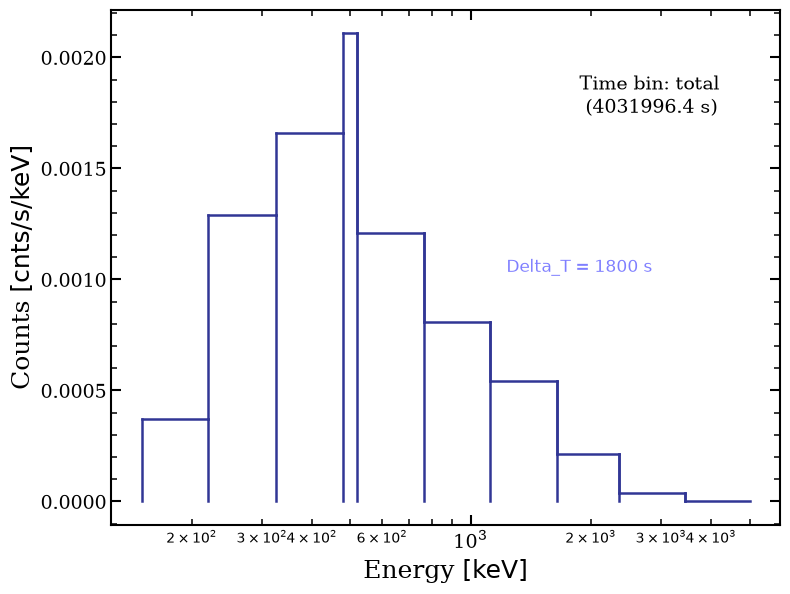

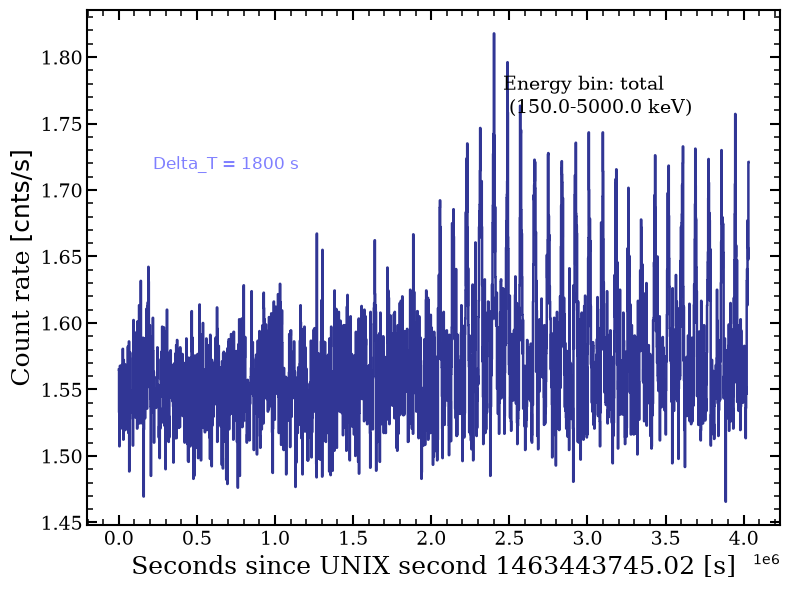

In [25]:
analysis1.dataset.plot_raw_spectrum()
plt.xscale('log')
#Include text in the plot
plt.text(0.7, 0.5, 'Delta_T = 1800 s', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12, color='blue', alpha=0.5)
plt.savefig('/Users/maura/Documents/COSI/data-challenge-1/docs/raw_spectrum.png', dpi=300, bbox_inches='tight')

analysis1.dataset.plot_lightcurve()
plt.text(0.2, 0.7, 'Delta_T = 1800 s', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12, color='blue', alpha=0.5)
plt.savefig('/Users/maura/Documents/COSI/data-challenge-1/docs/lightcurve.png', dpi=300, bbox_inches='tight')


# Define the pointing object with the cosipy pointing class.
This may also take several minutes to run.

In [17]:
# definition of poitings (balloon stability + Earth rotation)
pointing1 = Pointing(dataset=analysis1.dataset,)

## Visualize the path of the Crab through the field-of-view.
This isn't necessary for the imaging algorithm, but is illustrative in the case of a point source. Take the Crab as an example.

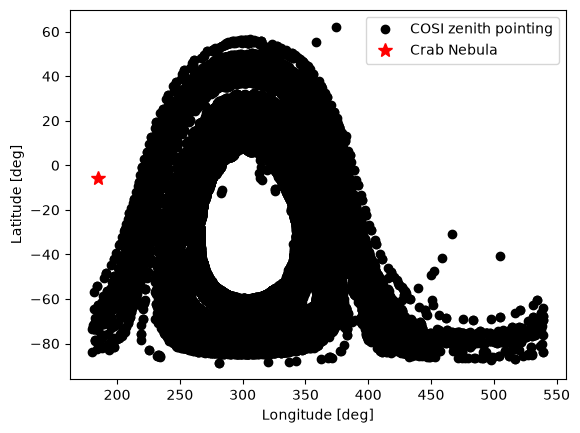

In [18]:
l_crab, b_crab = 184.55746, -5.78436 # Location of the Crab in Galactic coordinates [deg]

source = 'Crab Nebula'

plt.plot(pointing1.zpoins[:,0]+360, pointing1.zpoins[:,1], 'ko', label='COSI zenith pointing')
plt.plot(l_crab, b_crab, '*r', markersize=10 , label=f'{source}')
plt.xlabel('Longitude [deg]')
plt.ylabel('Latitude [deg]')
plt.legend();

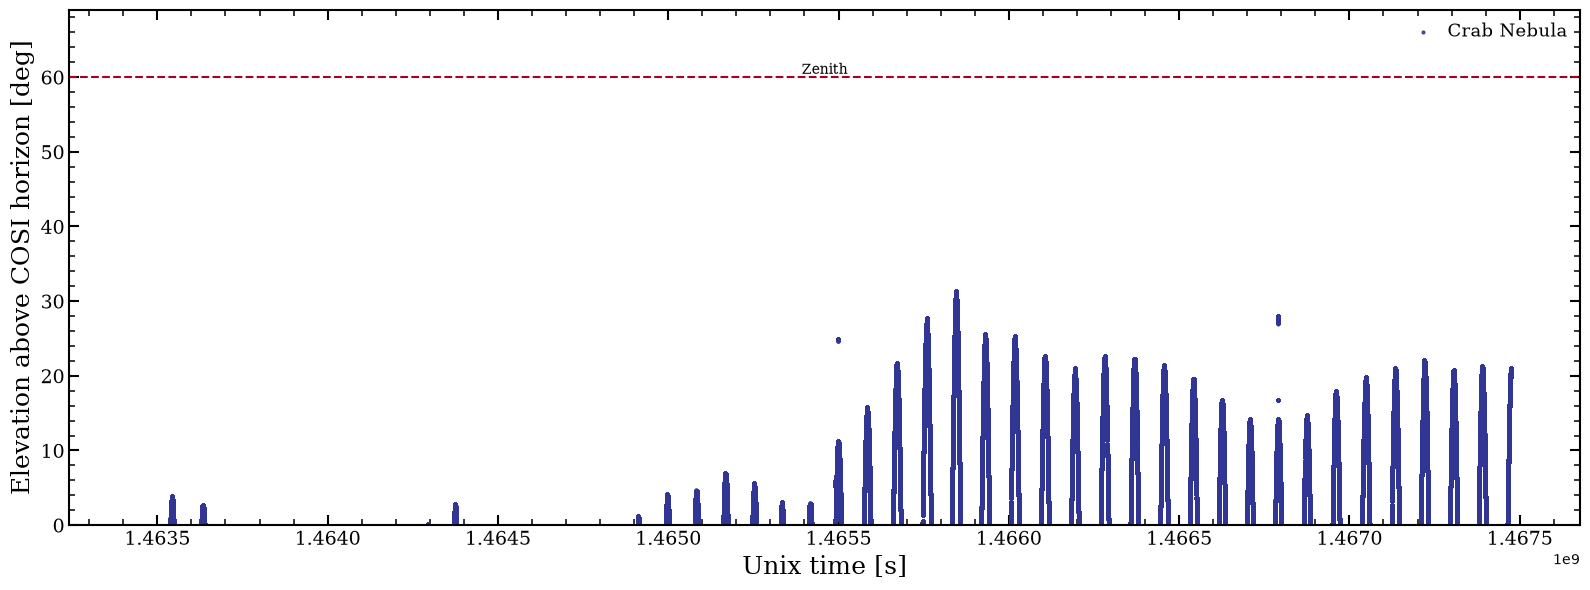

In [19]:
# COSI's field of view extends ~60 deg from zenith, hence why the Zenith is labeled as +60 deg above the horizon
analysis1.plot_elevation([l_crab], [b_crab], [f'{source}'])

# Define the BG model

In [89]:
# Ling BG simulation to model atmospheric background
background1 = BG(dataset=analysis1.dataset,mode=background_mode,filename=background_filename)

Using background mode: from file


# Read in the Response Matrix

In [27]:
# continuum response
rsp = response_dc1.SkyResponse(filename=response_filename,pixel_size=pixel_size) # read in detector response

Reading response.
Done.

Creating general RMF matrices.


Loop over phi bins::   0%|          | 0/30 [00:00<?, ?it/s]

Done.

Creating general IRF.
Done.

Deleting full matrix.
Done.


## Exploring the shape of the data space
The shape of the response spans (Galactic latitude $b$, Galactic longitude $\ell$, Compton scattering angle $\phi$,  FISBEL, energy).The shape of the data and background objects span (time, energy, Compton scattering angle, FISBEL).

In [28]:
rsp.rsp.response_grid_normed_efinal.shape

(30, 60, 30, 1145, 10)

In [29]:
np.shape(analysis1.dataset.binned_data)

(2240, 10, 30, 1145)

In [30]:
np.shape(background1.bg_model)

(2240, 10, 30, 1145)

****************

# Imaging Setup

## Define a grid on the sky to make images

In [90]:
# Convenient variable for deg --> radian conversion
deg2rad = np.pi/180.

# We define our sky-grid on a regular (pixel_size x pixel_size) grid for testing (later finer grid)
binsize = pixel_size

# Galactic coordiantes: l and b pixel edges
l_arrg = np.linspace(-180, 180, int(360/binsize)+1)
b_arrg = np.linspace(-90, 90, int(180/binsize)+1)

# Number of pixels in l and b
n_l = int(360/binsize)
n_b = int(180/binsize)

# Making a grid
L_ARRg, B_ARRg = np.meshgrid(l_arrg, b_arrg)

# Choosing the centre points as representative
l_arr = l_arrg[0:-1] + binsize/2
b_arr = b_arrg[0:-1] + binsize/2
L_ARR, B_ARR = np.meshgrid(l_arr, b_arr)

# Define solid angle for each pixel for normalisations later
domega = (binsize*deg2rad)*(np.sin(np.deg2rad(B_ARR + binsize/2)) - np.sin(np.deg2rad(B_ARR - binsize/2)))

## Convert sky grid to zenith/azimuth pairs for all pointings

In [91]:
# calculate the zeniths and azimuths on that grid for all times
zensgrid,azisgrid = zenaziGrid(pointing1.ypoins[:,0], pointing1.ypoins[:,1],
                               pointing1.xpoins[:,0], pointing1.xpoins[:,1],
                               pointing1.zpoins[:,0], pointing1.zpoins[:,1],
                               L_ARR.ravel(), B_ARR.ravel())

In [92]:
# Reshape for next routines ... 
zensgrid = zensgrid.reshape(n_b, n_l, len(pointing1.xpoins))
azisgrid = azisgrid.reshape(n_b, n_l, len(pointing1.xpoins))

## Get observation indices for non-zero bins
Here we also chose an energy bin to image. Energy bin "2" in the continuum response (and, necessarily, "energy_bin_edges" at the beginning of the notebook) is $320-480$ keV. We choose this energy bin because it has the highest count rate. Refer to the energy spectrum generated earlier.

In [93]:
ebin = 2 # Analyzing 320-480 keV 
nonzero_idx = background1.calc_this[ebin]

## Reduce the response dimensions

In [35]:
sky_response_CDS = rsp.rsp.response_grid_normed_efinal.reshape(
    n_b,
    n_l,
    analysis1.dataset.phis.n_phi_bins*\
    analysis1.dataset.fisbels.n_fisbel_bins, analysis1.dataset.energies.n_energy_bins)[:, :, nonzero_idx, ebin]

In [36]:
# reduced response dimensions:
# lat x lon x CDS
sky_response_CDS.shape

(30, 60, 2295)

## Function to get the response of an image for arbitrary time binning

In [ ]:
def get_image_response_from_pixelhit_general(Response,zenith,azimuth,dt,n_hours,binsize=6,cut=90,altitude_correction=False,al=None):
    """
    Get Compton response from hit pixel for each zenith/azimuth vector(!) input.
    Binsize determines regular(!!!) sky coordinate grid in degrees.

    :param: zenith        Zenith positions of all points of predefined sky grid with
                          respect to the instrument (in deg)
    :param: azimuth       Azimuth positions of all points of predefined sky grid with
                          respect to the instrument (in deg)
    :option: binsize      Default 5 deg (matching the sky dimension of the response). If set
                          differently, make sure it matches the sky dimension as otherwise,
                          false results may be returned
    :option: cut          Threshold to cut the response calculation after a certain zenith angle.
                          Default 90
    :param: n_hours       Number of hours in cdxervation
    :option: altitude_correction Default False: use interpolated transmission probability, normalised to 33 km and 500 keV,
                          to modify number of expected photons as a function of altitude and zenith angle of cdxervation
    :option: al           Altitude values according to dt from construct_pointings(); used of altitude_correction is set to True
    """

    # assuming useful input:
    # azimuthal angle is periodic in the range [0,360]
    # zenith ranges from [0,180]

    # check which pixel (index) was hit on regular grid
    hit_pixel_zi = np.floor(zenith/binsize)
    hit_pixel_ai = np.floor(azimuth/binsize)

    # and which pixel centre
    hit_pixel_z = (hit_pixel_zi+0.5)*binsize
    hit_pixel_a = (hit_pixel_ai+0.5)*binsize

    # check which zeniths are beyond threshold
    bad_idx = np.where(hit_pixel_z > cut)

    # set hit pixels to output array
    za_idx = np.array([hit_pixel_zi,hit_pixel_ai]).astype(int)

    nz = zenith.shape[2]

    n_lon = int(360/binsize)
    n_lat = int(180/binsize)
    
    l_arrg = np.linspace(-180,180,int(360/binsize)+1)
    b_arrg = np.linspace(-90,90,int(180/binsize)+1)
    L_ARRg, B_ARRg = np.meshgrid(l_arrg,b_arrg)
    l_arr = l_arrg[0:-1]+binsize/2
    b_arr = b_arrg[0:-1]+binsize/2
    L_ARR, B_ARR = np.meshgrid(l_arr,b_arr)

    # take care of regular grid by applying weighting with latitude
    weights = ((binsize*np.pi/180)*(np.sin(np.deg2rad(B_ARR+binsize/2)) - np.sin(np.deg2rad(B_ARR-binsize/2)))).repeat(nz).reshape(n_lat,n_lon,nz)
    weights[bad_idx] = 0

    
    # check for negative weights and indices and remove
    weights[za_idx[0,:] < 0] = 0.
    weights[za_idx[1,:] < 0] = 0.
    za_idx[0,za_idx[0,:] < 0] = 0.
    za_idx[1,za_idx[1,:] < 0] = 0.
        
    
    if altitude_correction == True:
        altitude_response = return_altitude_response()
    else:
        altitude_response = one_func

    # get responses at pixels    
    image_response = np.zeros((n_hours,n_lat,n_lon,Response.shape[2]))

    for c in tqdm(range(n_hours)):
        cdx = np.where((pointing1.cdtpoins > analysis1.dataset.times.times_min[analysis1.dataset.times.n_ph_dx[c]]) &
                       (pointing1.cdtpoins <= analysis1.dataset.times.times_max[analysis1.dataset.times.n_ph_dx[c]]))[0]
    
        # this calculation is basically a look-up of the response entries. In general, weighting (integration) with the true shape can be introduced, however with a lot more computation time (Simpson's rule in 2D ...)
        image_response[c,:,:,:] += np.sum(Response[za_idx[0,:,:,cdx],za_idx[1,:,:,cdx],:]*np.einsum('klij->iklj', weights[:,:,cdx,None])*dt[cdx,None,None,None],axis=0)#*altitude_weights[:,:,None]
        
    return image_response


## Calculate the general response for the current data set
This has to be done only once (for the data set).

Takes ~20 minutes to run and ~94 GB memory!

In [38]:
cut = 90 # This mirrors the earth horizon cut in the response
sky_response_scaled = get_image_response_from_pixelhit_general(
    Response=sky_response_CDS,
    zenith=zensgrid,
    azimuth=azisgrid,
    dt=pointing1.dtpoins,
    n_hours=analysis1.dataset.times.n_ph,
    binsize=pixel_size,
    cut=cut,
    altitude_correction=False,
    al=np.ones(len(pointing1.dtpoins)))

  0%|          | 0/2240 [00:00<?, ?it/s]

In [39]:
# data-set-specific response dimensions
# times x lat x lon x CDS
sky_response_scaled.shape

(2240, 30, 60, 2295)

## Exposure map
i.e. the response weighted by time

In [40]:
expo_map = np.zeros((n_b, n_l))

for i in tqdm(range(sky_response_scaled.shape[0])):
    expo_map += np.sum(sky_response_scaled[i,:,:,:], axis=2)
    
print(f'expo_map shape: {expo_map.shape}')

  0%|          | 0/2240 [00:00<?, ?it/s]

expo_map shape: (30, 60)


## Plotting the exposure map weighted with the pixel size

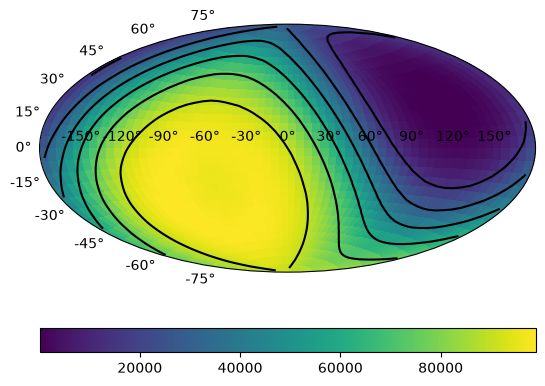

In [94]:
plt.subplot(projection='aitoff')
p = plt.pcolormesh(L_ARRg*deg2rad,B_ARRg*deg2rad,np.roll(expo_map/domega,axis=1,shift=0))
plt.contour(L_ARR*deg2rad,B_ARR*deg2rad,np.roll(expo_map/domega,axis=1,shift=0),colors='black')
plt.colorbar(p, orientation='horizontal')

# Set up the RL algorithm

### Define regions of the sky that we actually cannot see

In [42]:
# here we select everything, i.e. we have no bad exposure

bad_expo = np.where(expo_map/domega <= 0)

### Define function for a starting map for the RL deconvolution. We choose an isotropic map, i.e. all pixels on the sky are initialized with the same value

In [43]:
def IsoMap(ll,bb,A0,binsize=pixel_size):
    shape = np.ones(ll.shape)
    norm = np.sum(shape*(binsize*np.pi/180)*(np.sin(np.deg2rad(bb+binsize/2)) - np.sin(np.deg2rad(bb-binsize/2))))
    val = A0*shape/norm
    return val

### Number of time bins 

In [44]:
d2h = analysis1.dataset.binned_data.shape[0]
d2h

2240

### Select only one energy bin (as above) for data set

In [45]:
print('ebin: ',ebin)
dataset = analysis1.dataset.binned_data[:,ebin,:,:].reshape(d2h,
                                                            analysis1.dataset.phis.n_phi_bins*analysis1.dataset.fisbels.n_fisbel_bins)[:,nonzero_idx]


ebin:  2


### Same for background

In [46]:
background_model = background1.bg_model_reduced[ebin]

### Check for consistency of data and background
They must have the same dimensions. If not, the algorithm won't work.

In [47]:
dataset.shape,background_model.shape

((2240, 2295), (2240, 2295))

### Define background model cuts, indices, and resulting number of cuts

In [48]:
bg_cuts, idx_arr, Ncuts = background1.bg_cuts, background1.idx_arr, background1.Ncuts

### For the modified RL algorithm implemented here, we need to load a stan model that fits background plus two images (the current image plus a delta image given by the RL formalism)


In [49]:
if pystan_exists:
    try:
        #read stanmodel.pkl (if already compiled)
        model_multimap = pickle.load(open('stanmodel.pkl', 'rb'))

    except:
        print('Model not yet compiled, doing that now (might take a while).')

        # compile model (if not yet compiled):
        model_multimap = pystan.StanModel(str(repo_root / 'notebooks' / 'simulated' / 'imaging' / 'resources' / 'stanmodel.stan'))

        with open('stanmodel.pkl', 'wb') as f:
            pickle.dump(model_multimap, f)
else:
    print('pystan is not loaded. Skipping this cell.')

pystan is not loaded. Skipping this cell.


## Set an initial guess for the background amplitude
Feel free to play with this value, but here are suggestions informed by testing thus far:

### If source+BG:
We suggest setting "fitted_bg" to 0.9 or 0.99 when the loaded data/simulation (analysis1 object) contains both source and background. This is a rough estimate of the background contribution (90, 99%) to the entire data set.

### If analyzing source only:
When the analysis1 object does not contain background, we suggest setting this parameter to 1E-6, i.e. very close to zero background contribution.

In [50]:
fitted_bg = np.array([0.9])


# Richardson-Lucy algorithm

## Individual steps are explained in the code.
The steps follow the algorithm as outlined in [Knodlseder et al. 1999](https://ui.adsabs.harvard.edu/abs/1999A%26A...345..813K/abstract). Refer to that paper for a mathematical description of the algorithm.

The total memory used during these iterations is about 94 GB!! You might not be able to do much else with your machine while this is running.

Note: If pystan is not loaded, the algorithm will print "Fit failed! proceeding without acceleration". Proceed with the iterations anyway.

In [51]:
# Might not use this depending on if you choose to smooth the delta map
from scipy.ndimage import gaussian_filter

Convolving with response (init expectation), iteration 0


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/149 [00:00<?, ?it/s]

Calculating Delta image, iteration 1, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

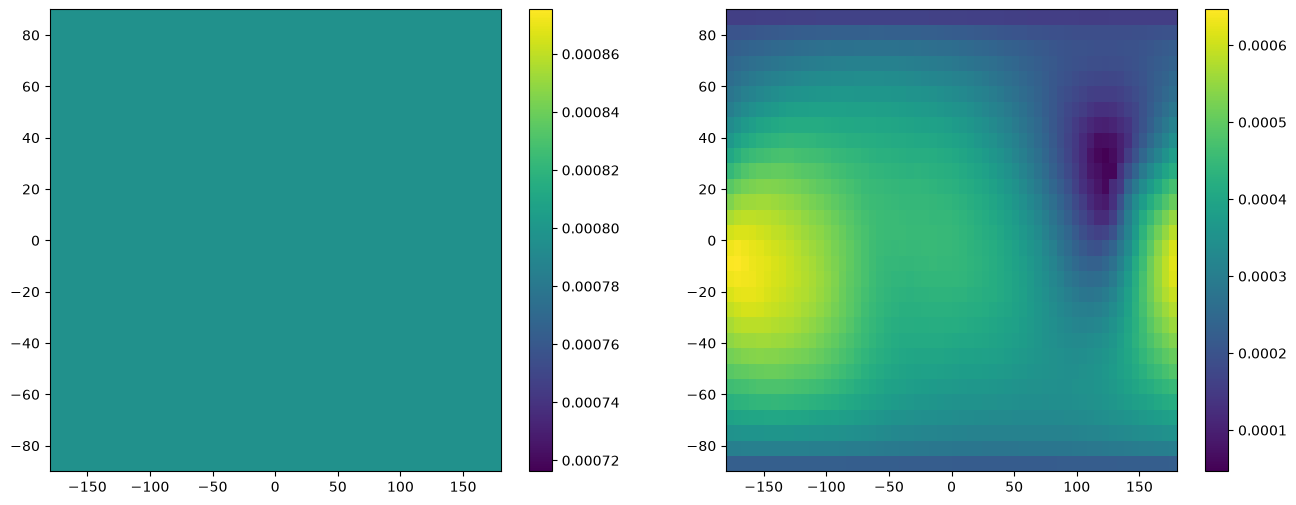

Convolving Delta image, iteration 1


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 1
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 1
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 2, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

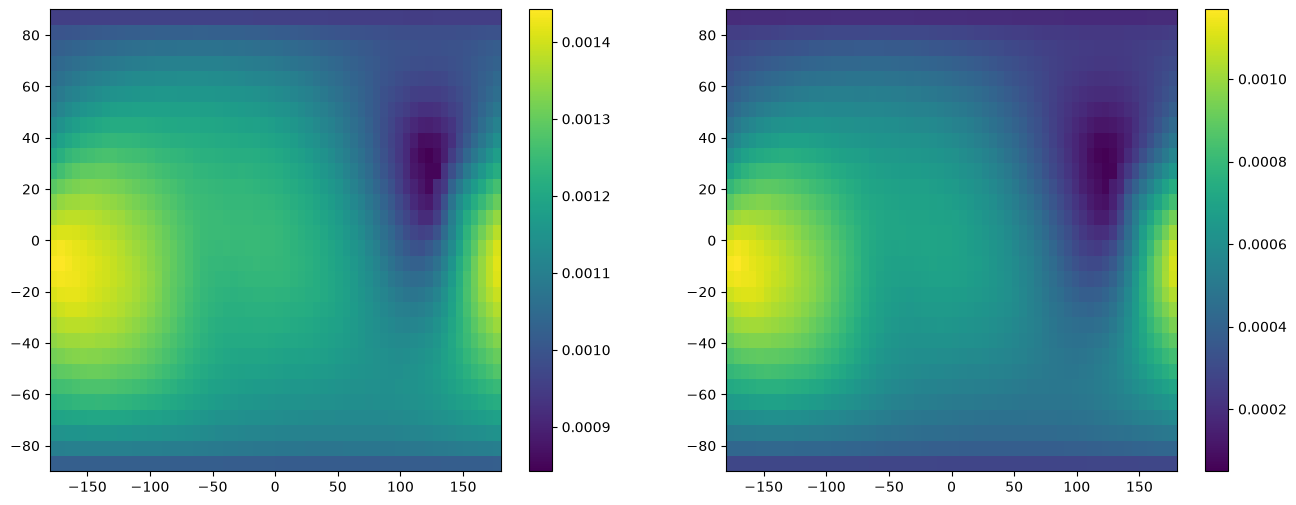

Convolving Delta image, iteration 2


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 2
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 2
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 3, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

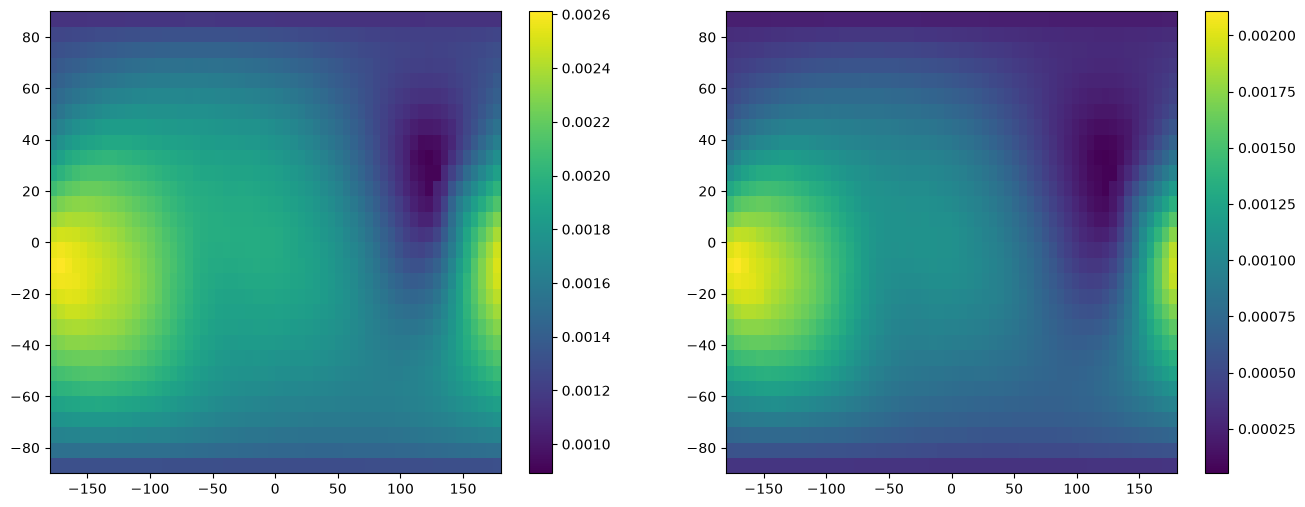

Convolving Delta image, iteration 3


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 3
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 3
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 4, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

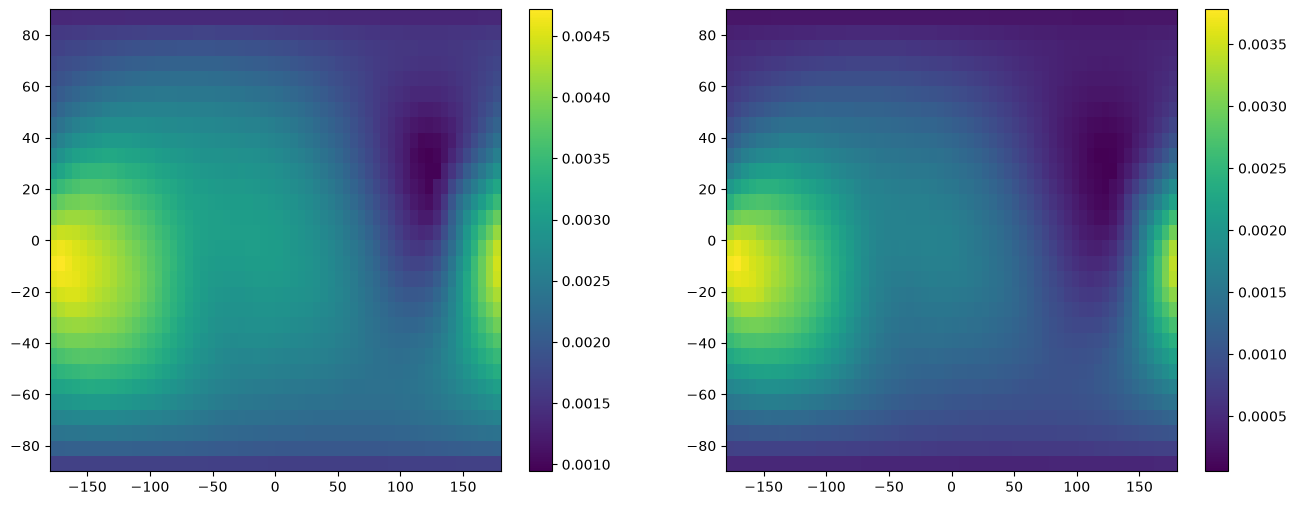

Convolving Delta image, iteration 4


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 4
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 4
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 5, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

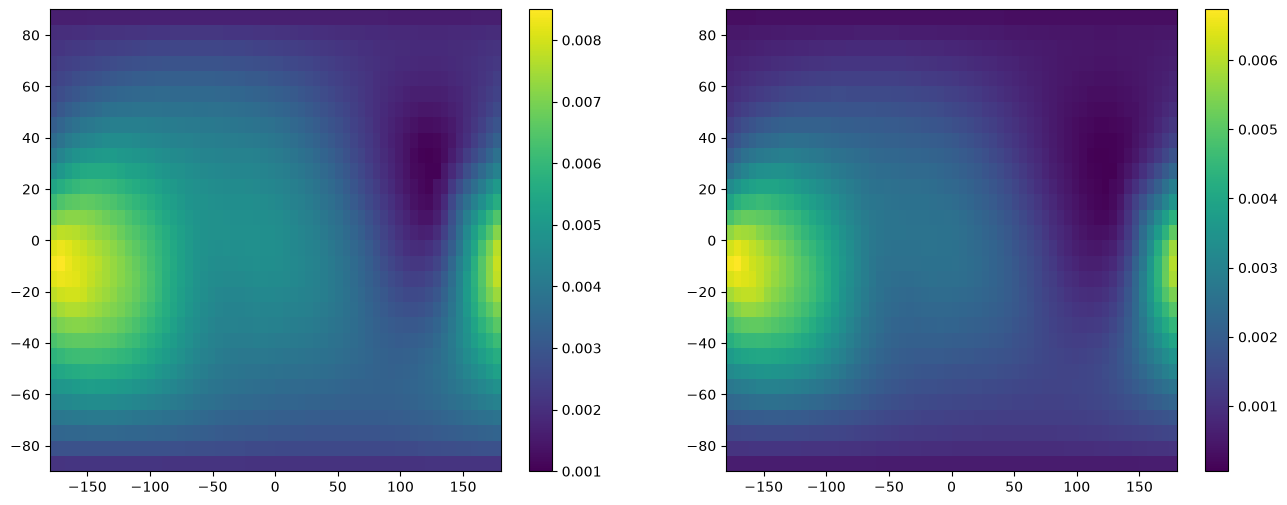

Convolving Delta image, iteration 5


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 5
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 5
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 6, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

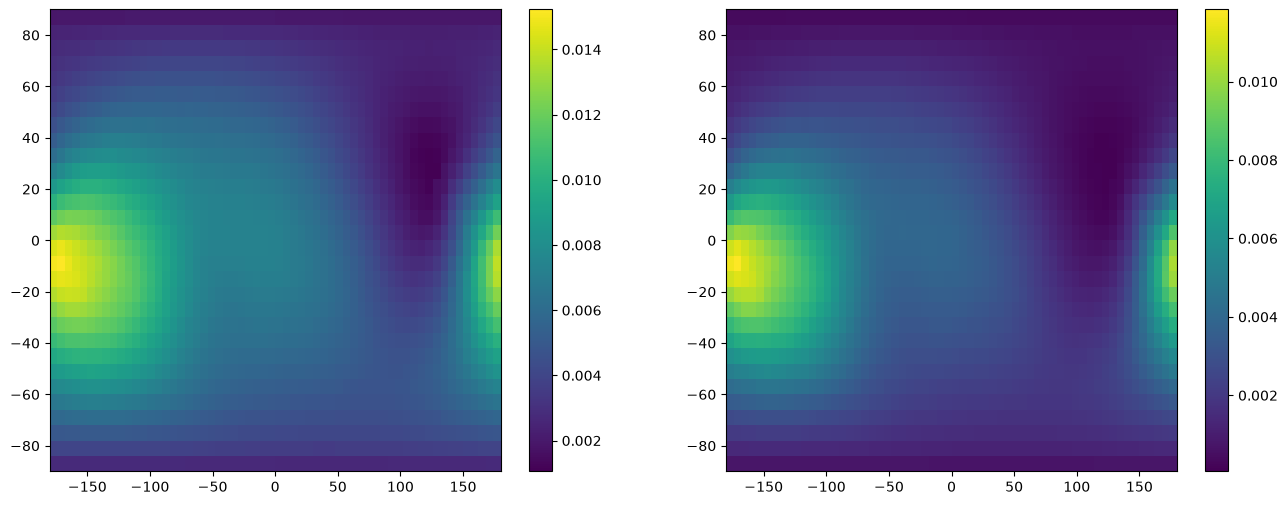

Convolving Delta image, iteration 6


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 6
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 6
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 7, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

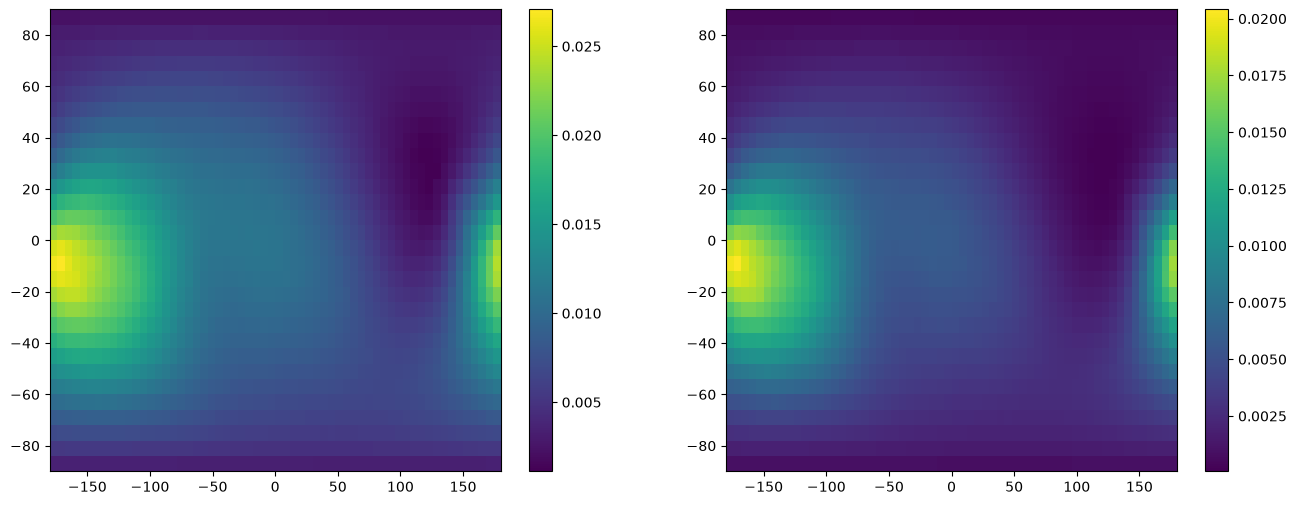

Convolving Delta image, iteration 7


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 7
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 7
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 8, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

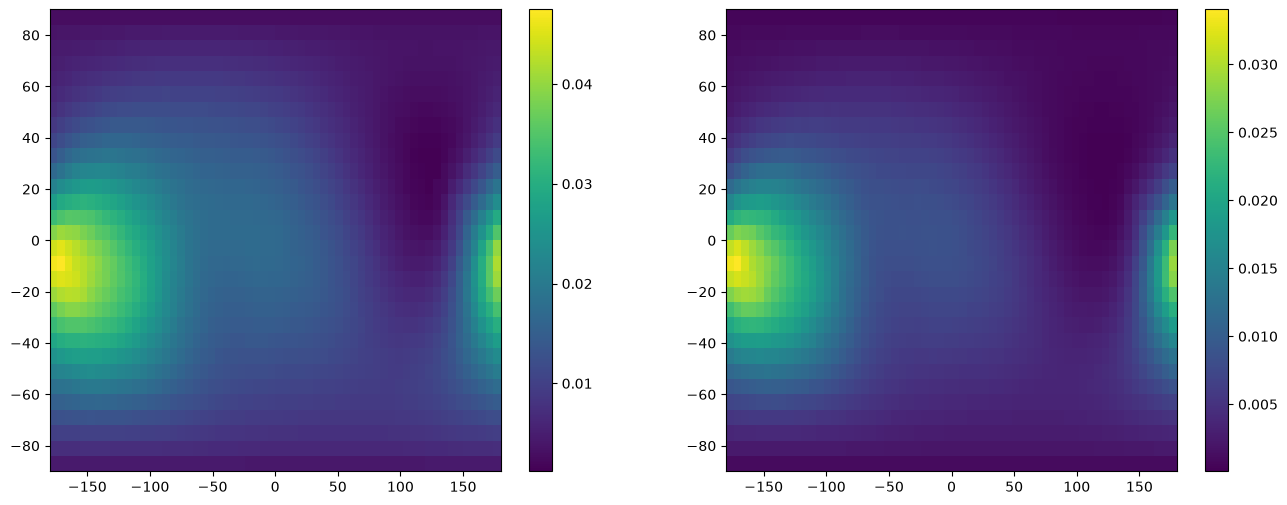

Convolving Delta image, iteration 8


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 8
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 8
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 9, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

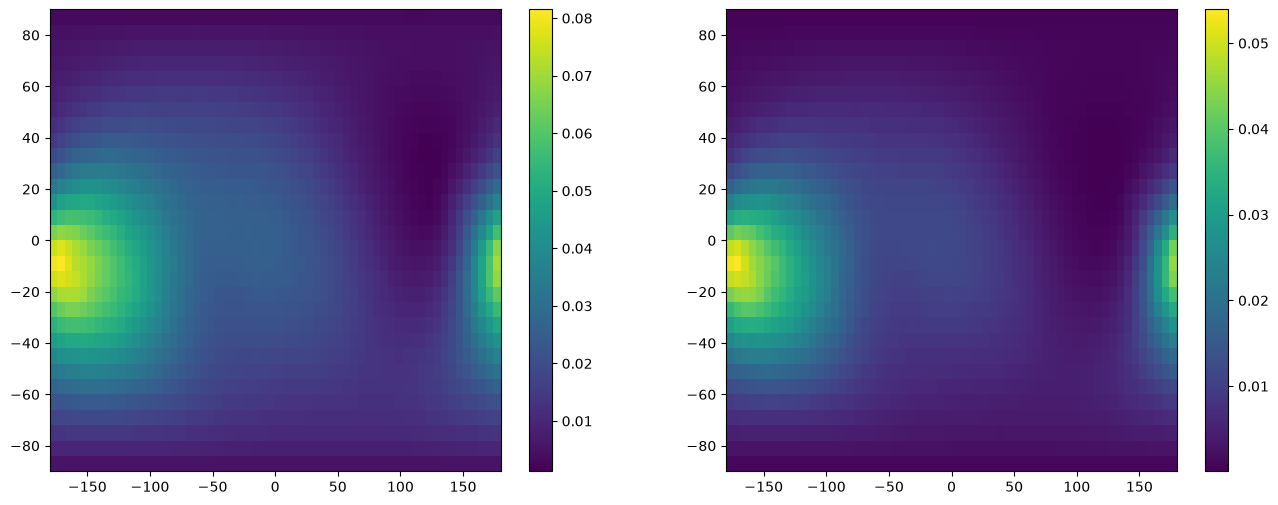

Convolving Delta image, iteration 9


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 9
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 9
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 10, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

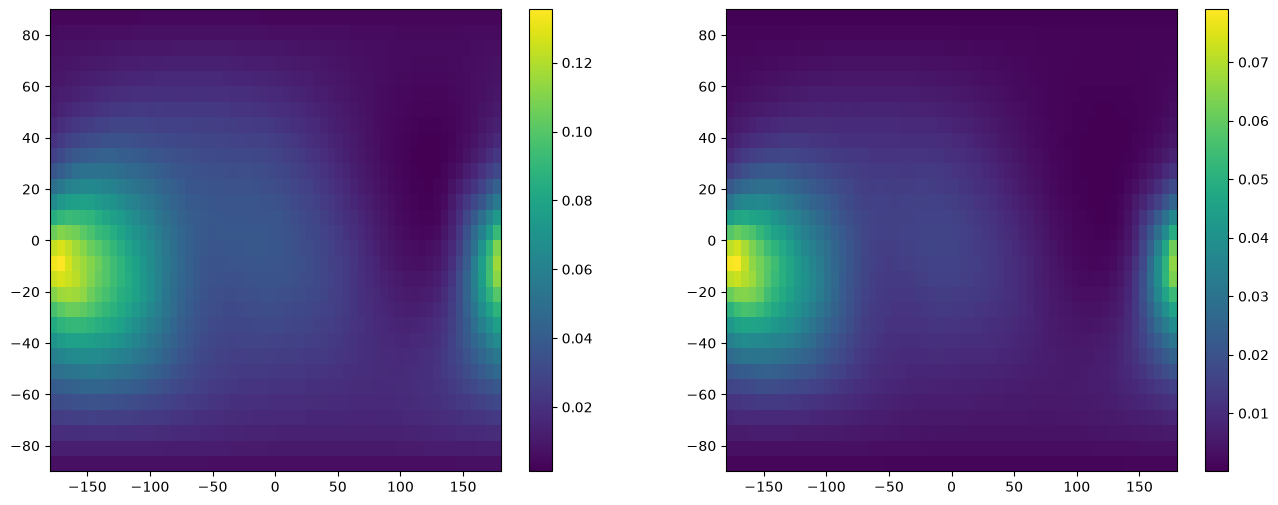

Convolving Delta image, iteration 10


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 10
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 10
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 11, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

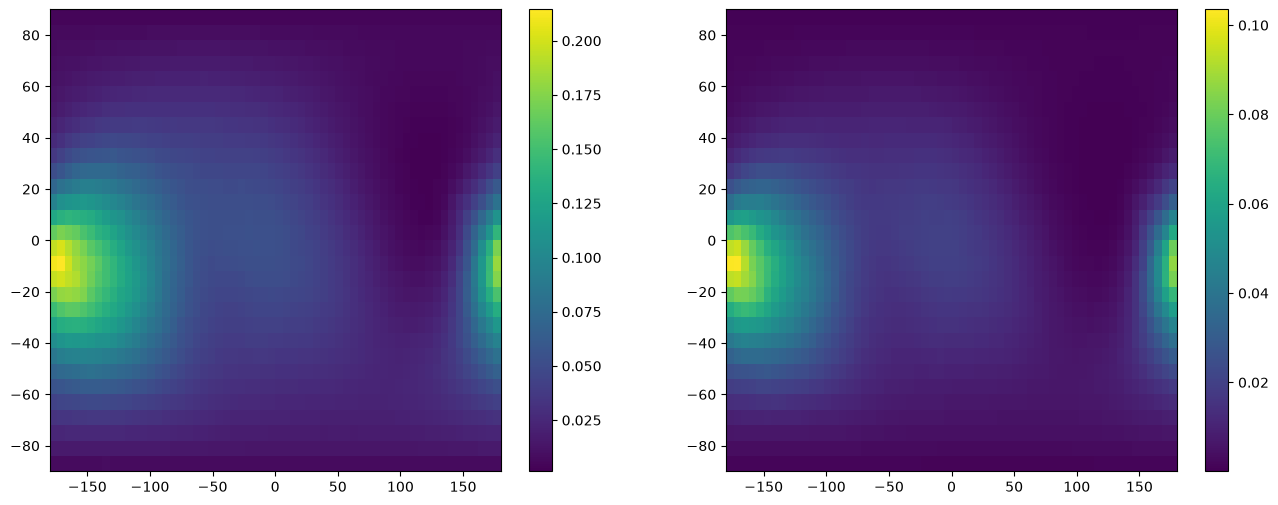

Convolving Delta image, iteration 11


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 11
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 11
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 12, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

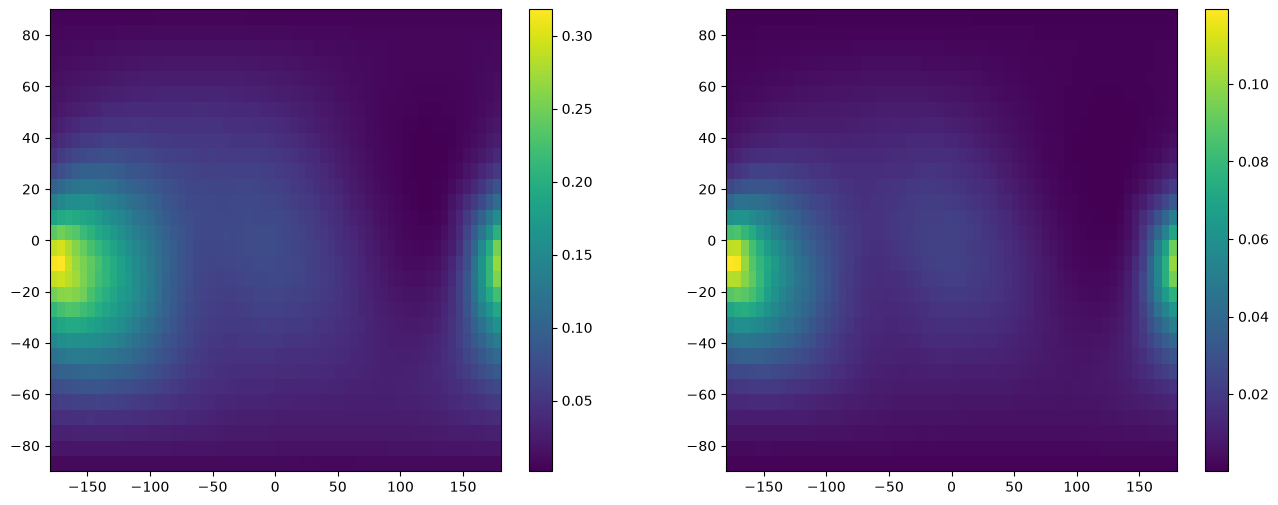

Convolving Delta image, iteration 12


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 12
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 12
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 13, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

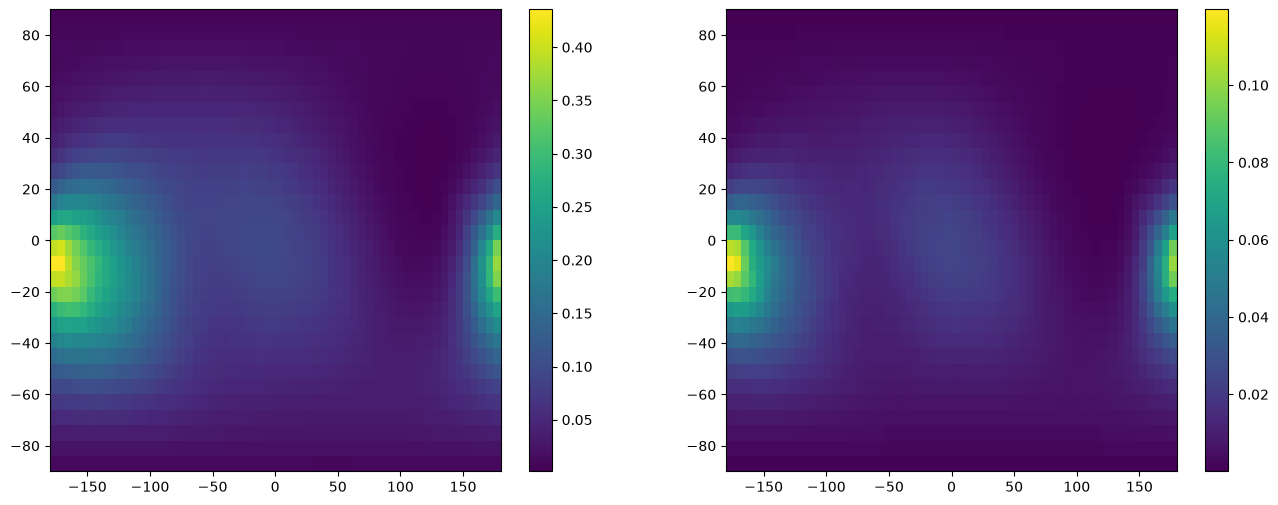

Convolving Delta image, iteration 13


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 13
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 13
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 14, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

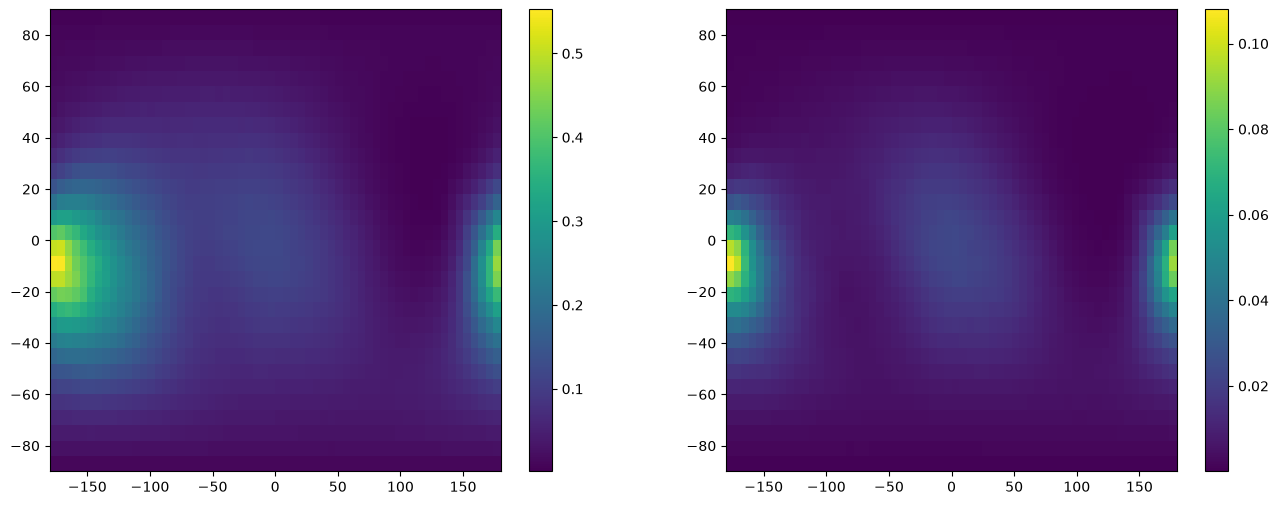

Convolving Delta image, iteration 14


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 14
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 14
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 15, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

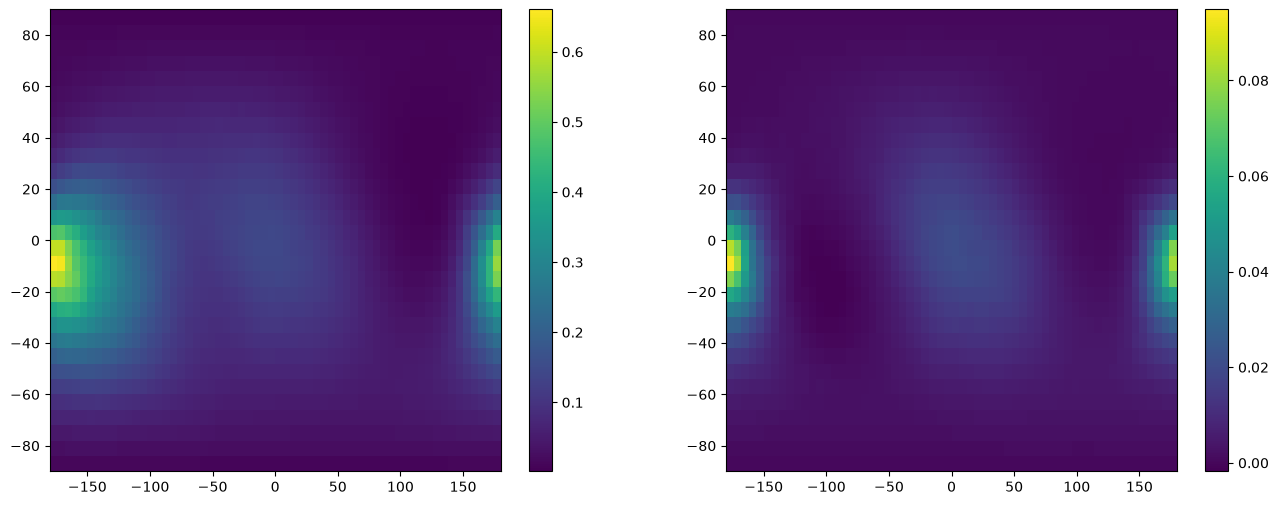

Convolving Delta image, iteration 15


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 15
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 15
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 16, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

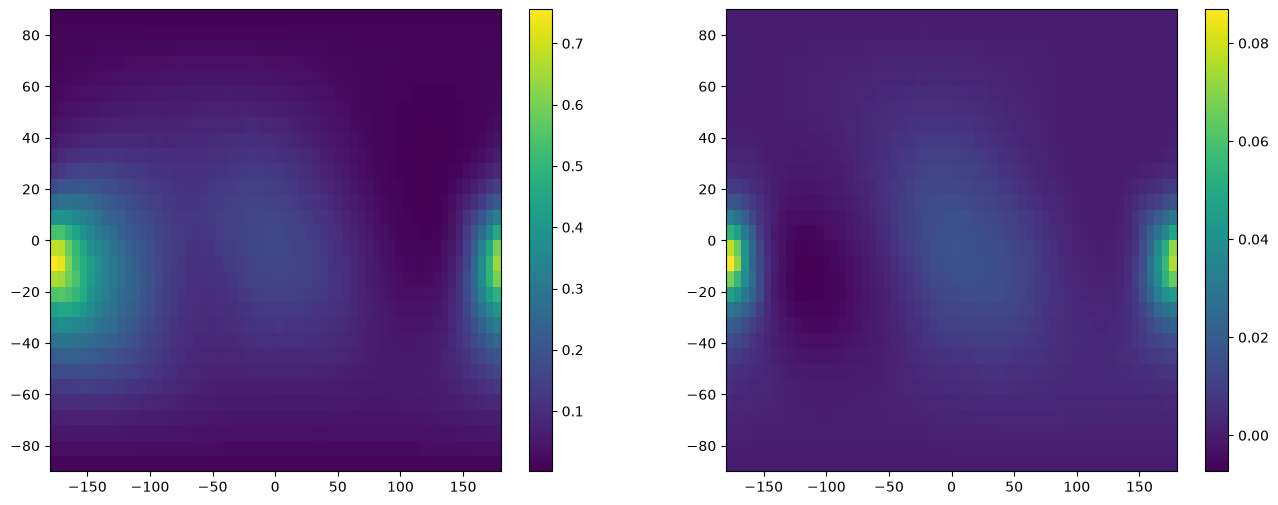

Convolving Delta image, iteration 16


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 16
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 16
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 17, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

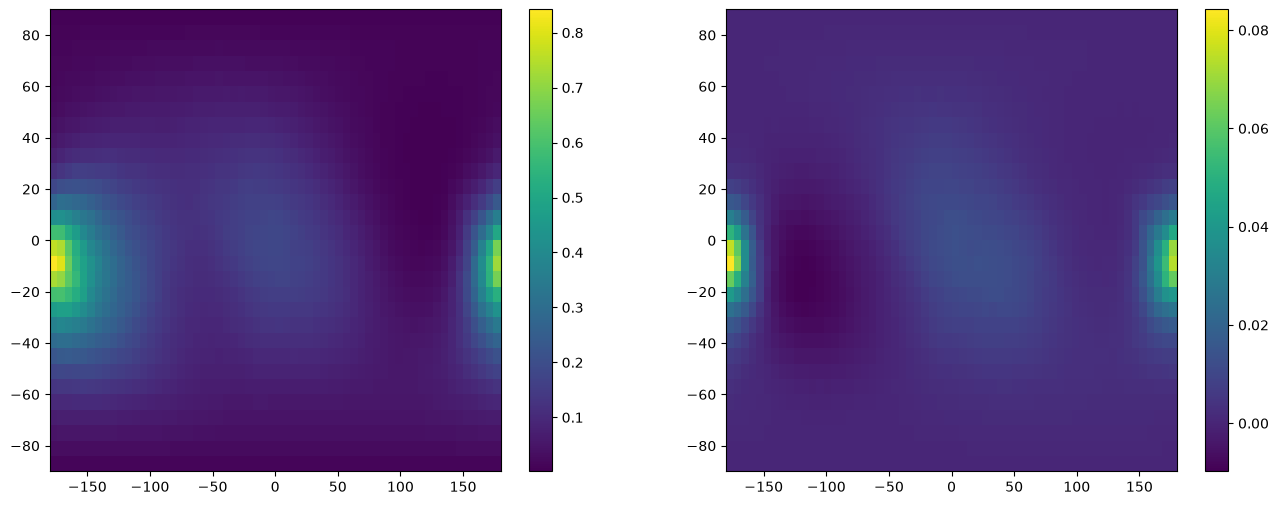

Convolving Delta image, iteration 17


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 17
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 17
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 18, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

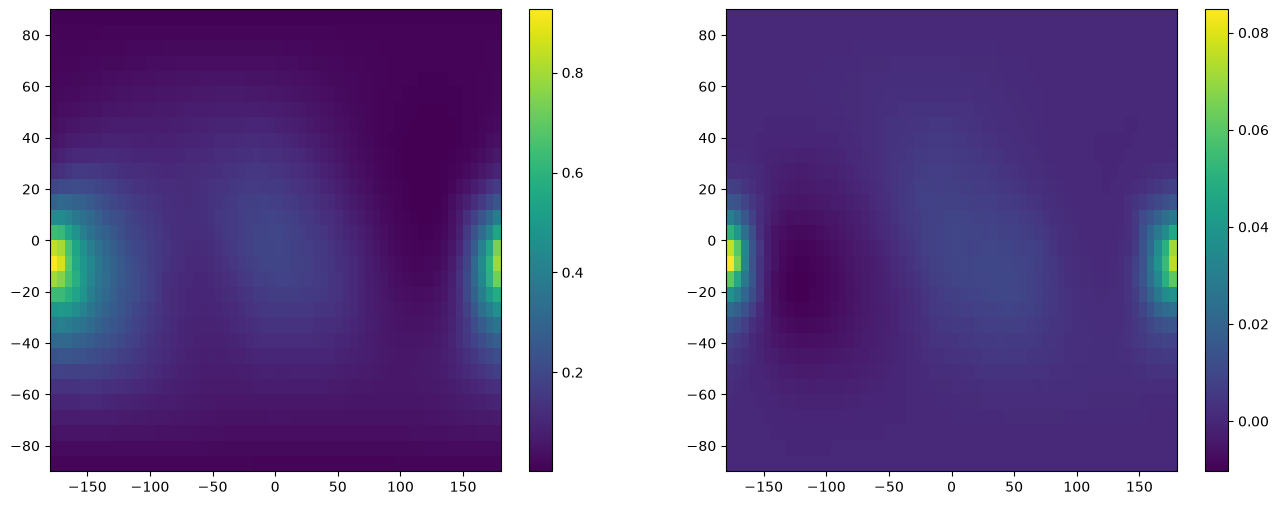

Convolving Delta image, iteration 18


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 18
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 18
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 19, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

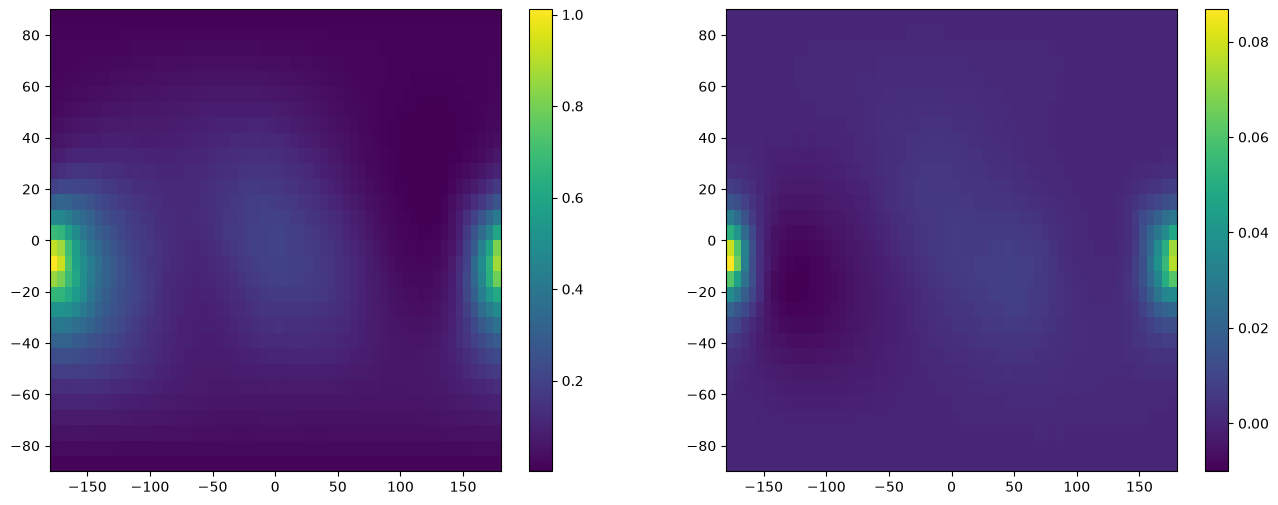

Convolving Delta image, iteration 19


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 19
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 19
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 20, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

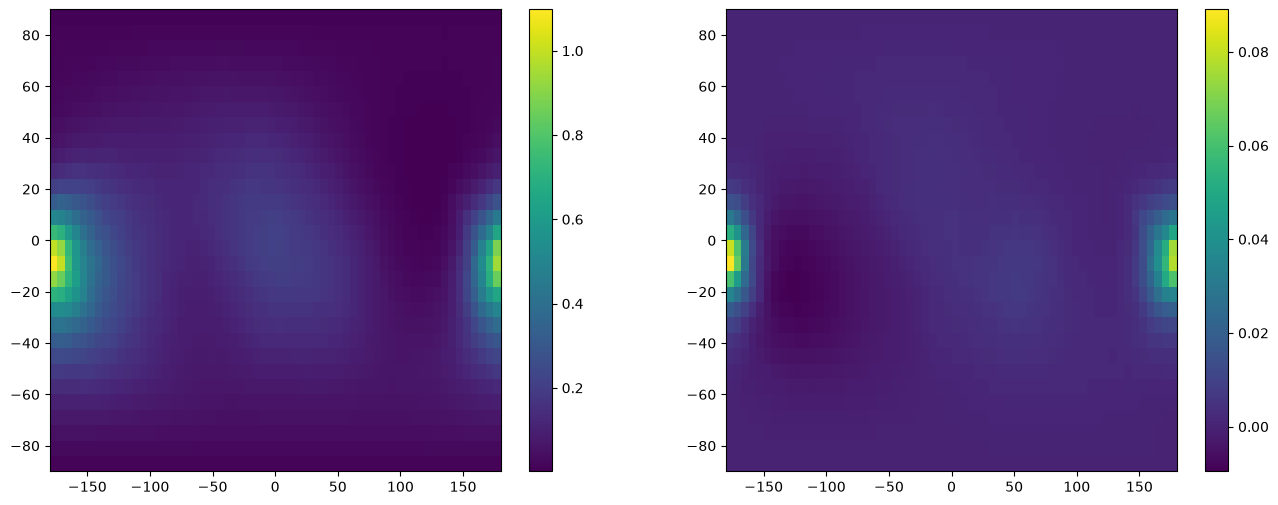

Convolving Delta image, iteration 20


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 20
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 20
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 21, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

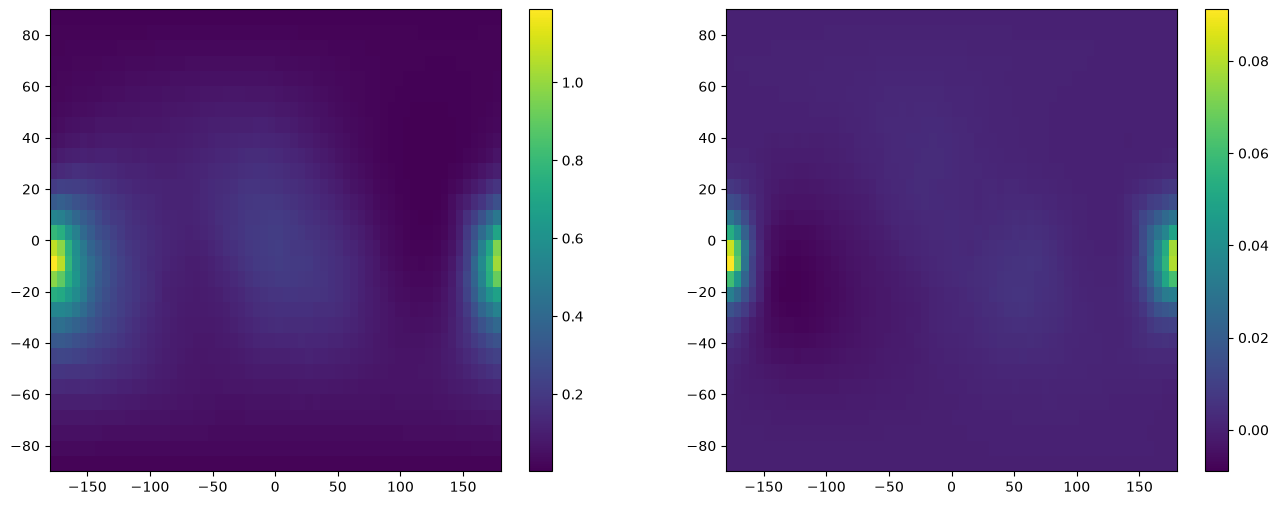

Convolving Delta image, iteration 21


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 21
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 21
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 22, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

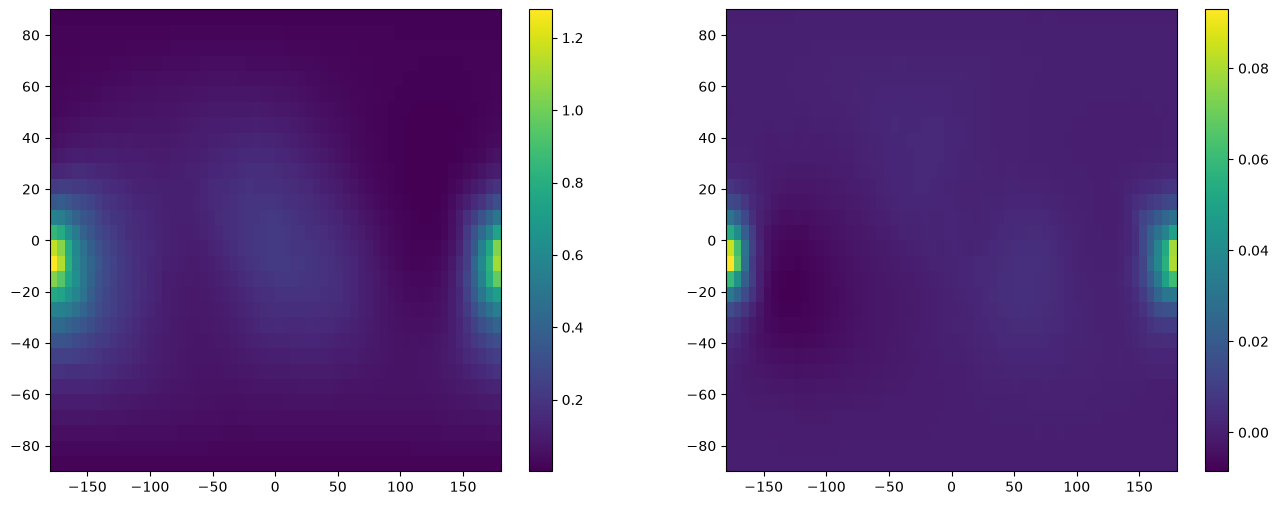

Convolving Delta image, iteration 22


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 22
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 22
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 23, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

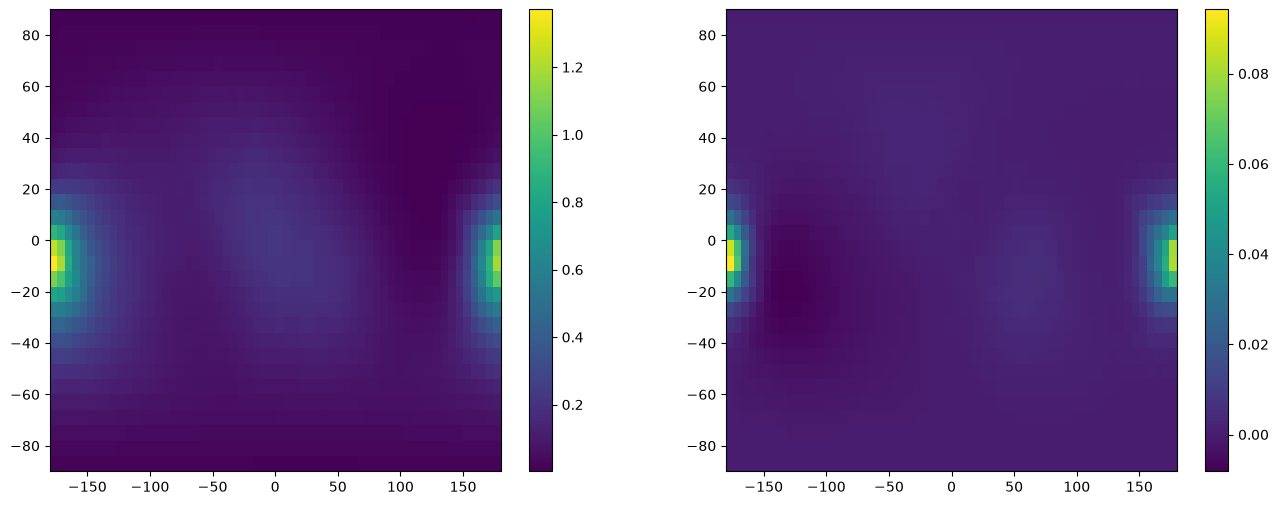

Convolving Delta image, iteration 23


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 23
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 23
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 24, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

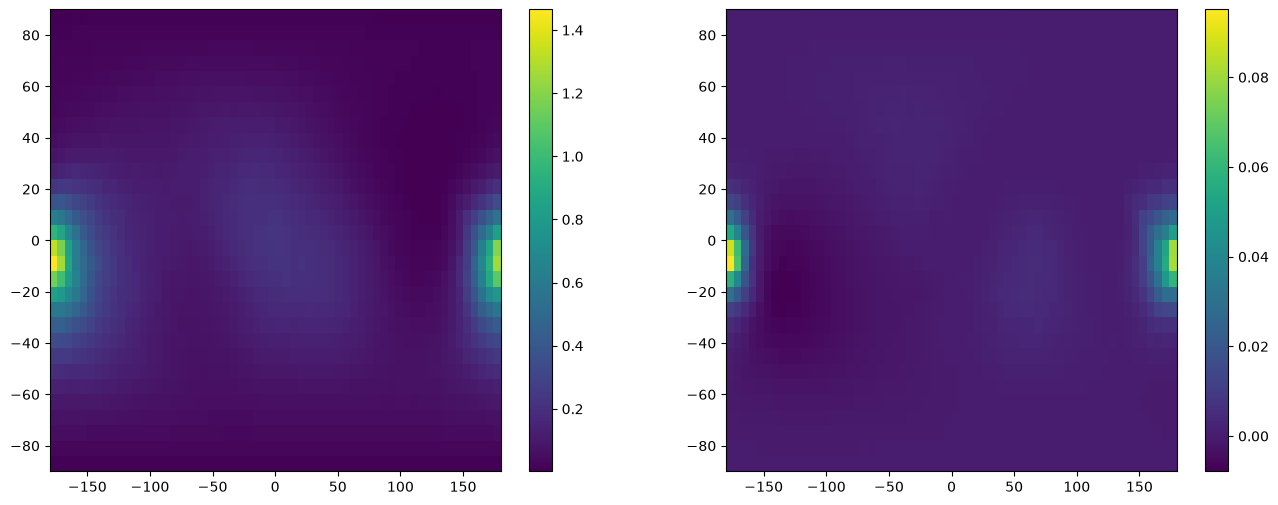

Convolving Delta image, iteration 24


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 24
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 24
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 25, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

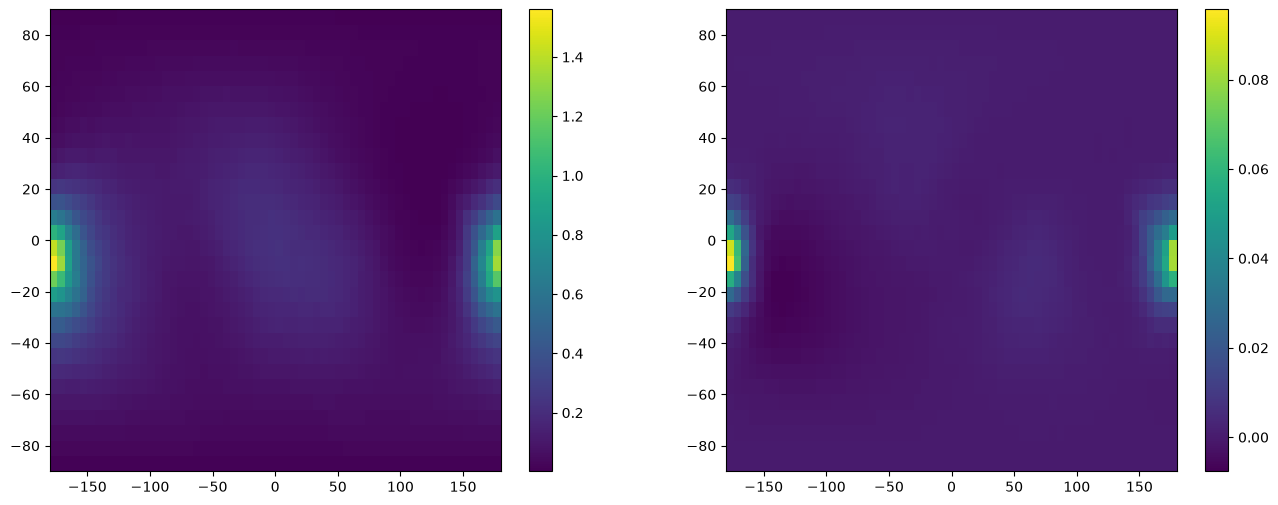

Convolving Delta image, iteration 25


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 25
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 25
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 26, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

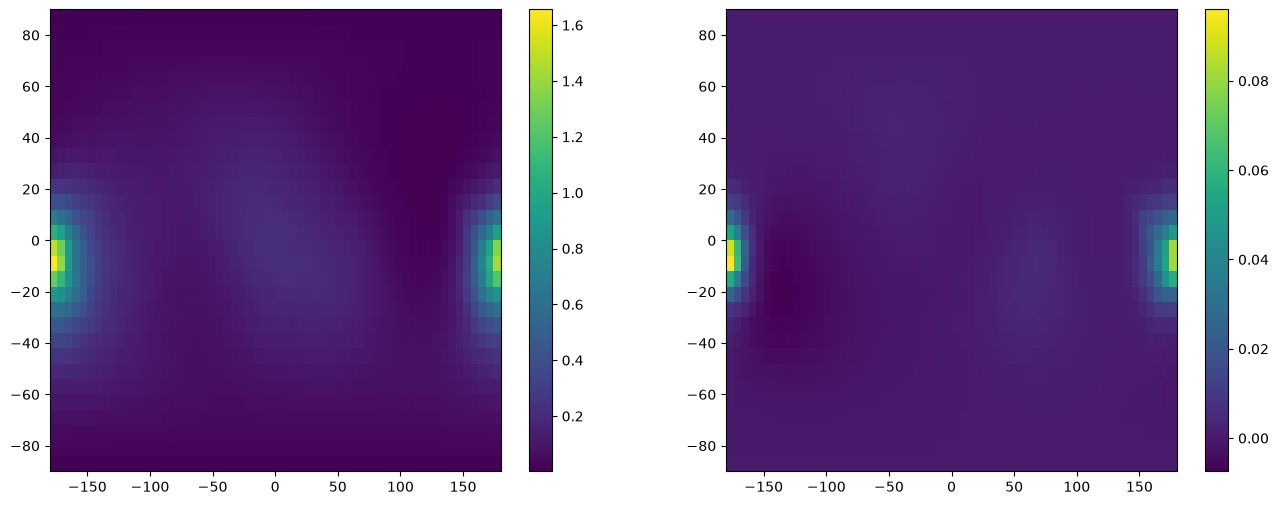

Convolving Delta image, iteration 26


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 26
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 26
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 27, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

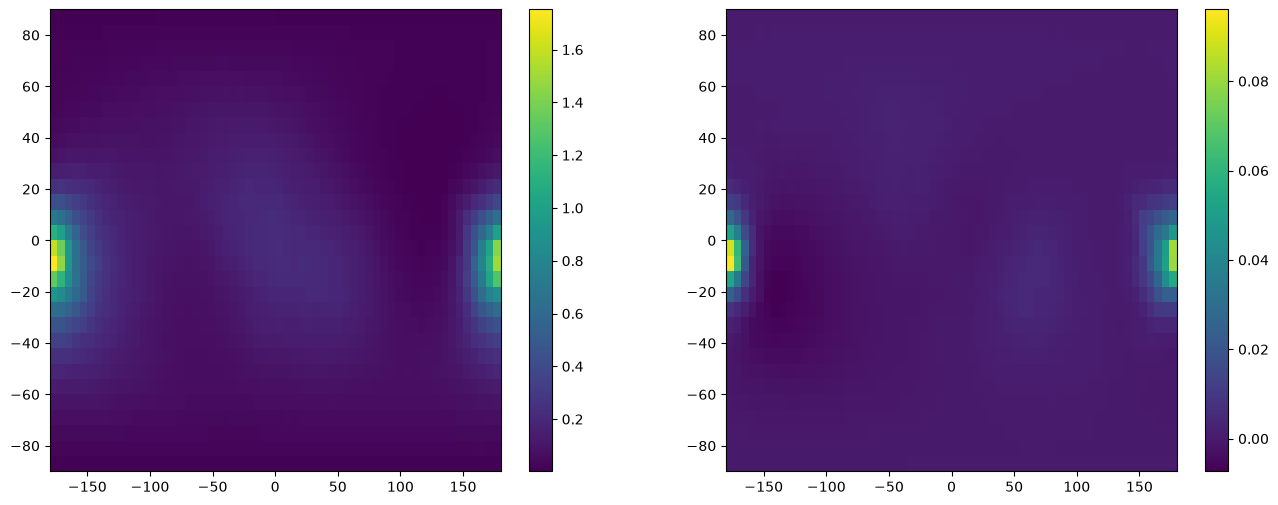

Convolving Delta image, iteration 27


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 27
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 27
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 28, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

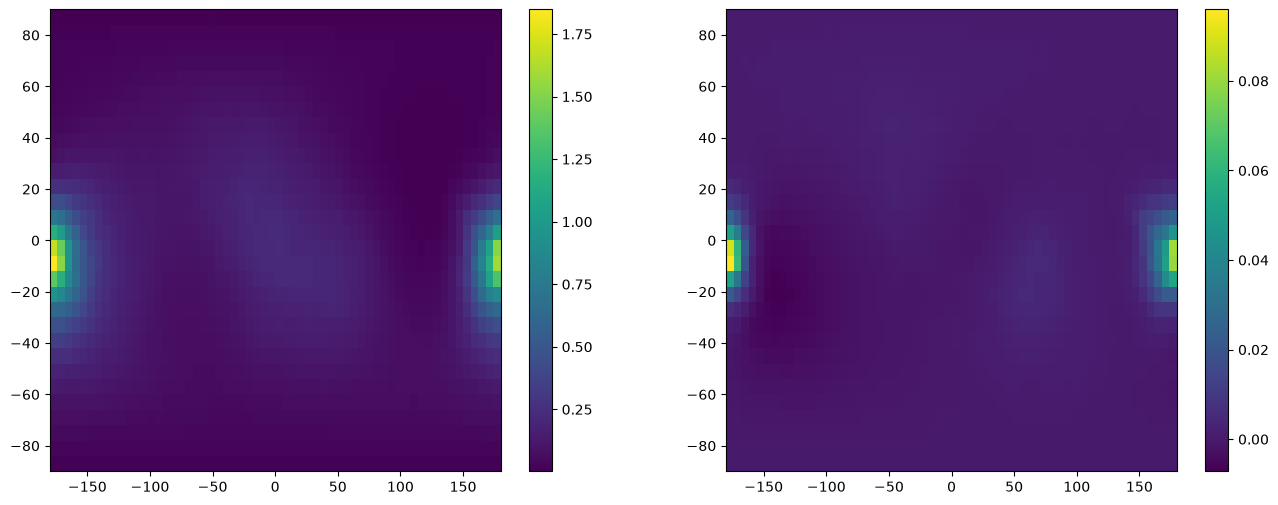

Convolving Delta image, iteration 28


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 28
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 28
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 29, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

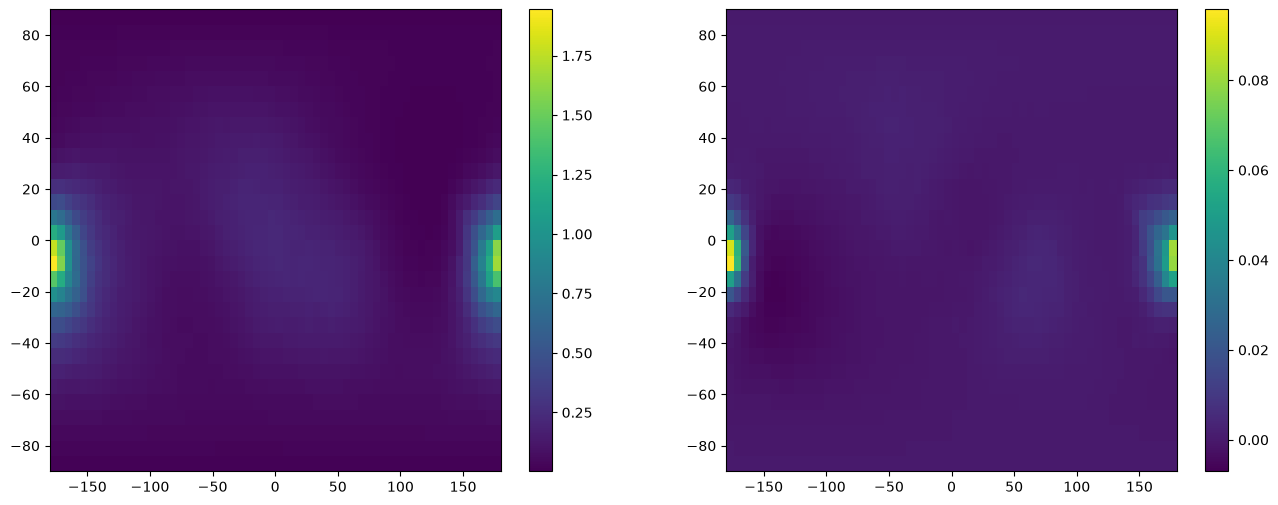

Convolving Delta image, iteration 29


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 29
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 29
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 30, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

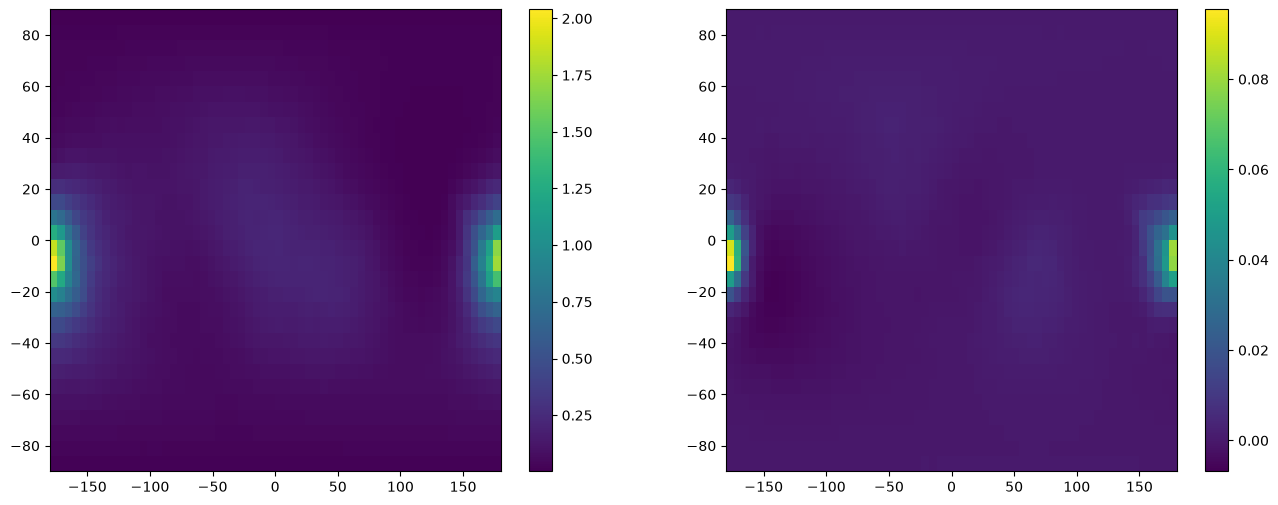

Convolving Delta image, iteration 30


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 30
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 30
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 31, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

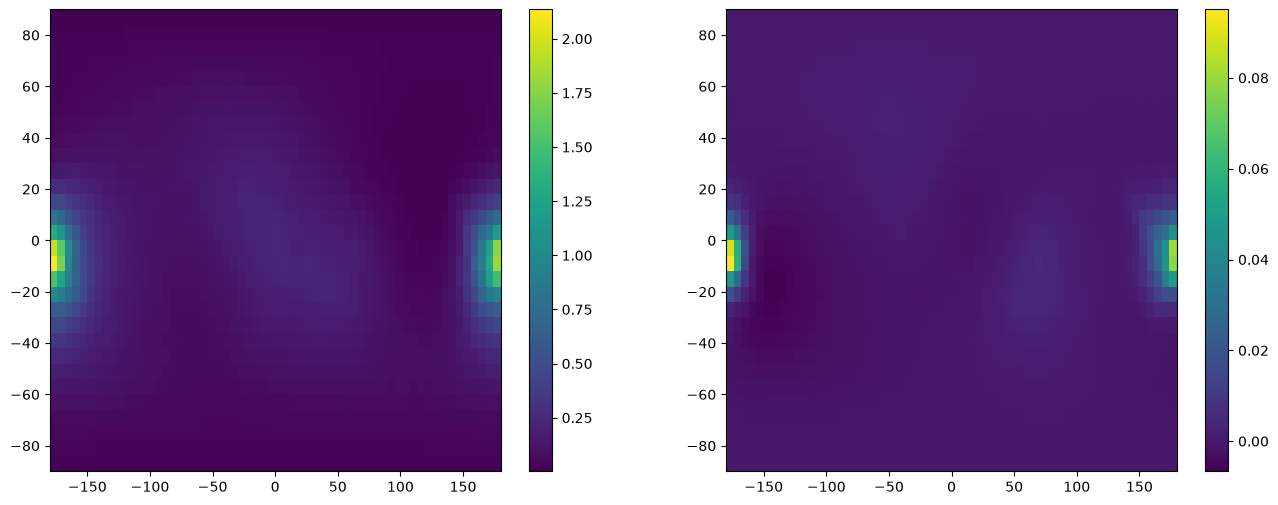

Convolving Delta image, iteration 31


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 31
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 31
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 32, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

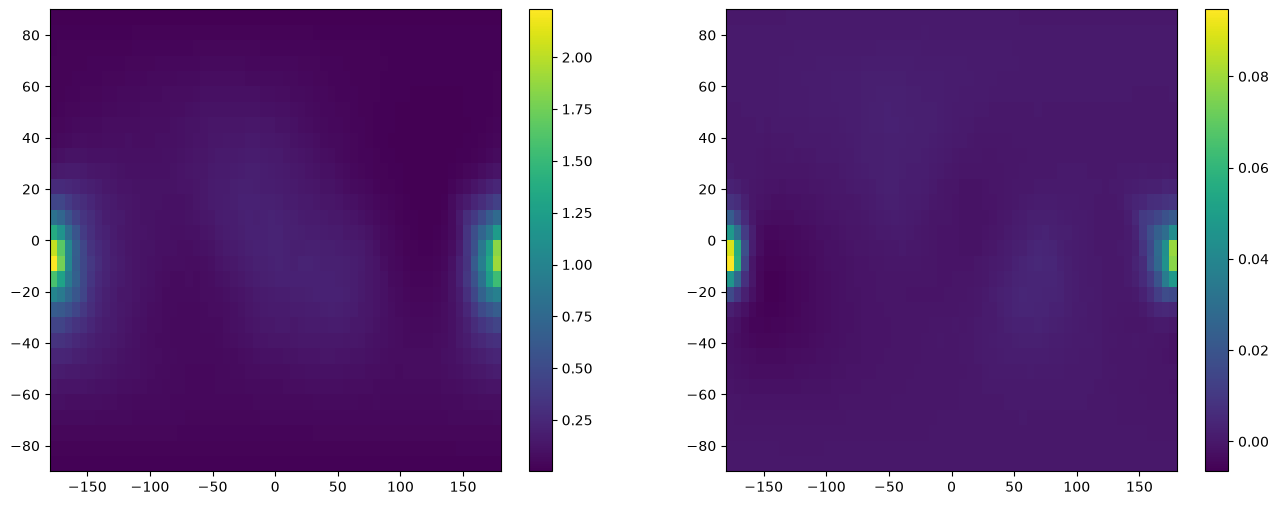

Convolving Delta image, iteration 32


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 32
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 32
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 33, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

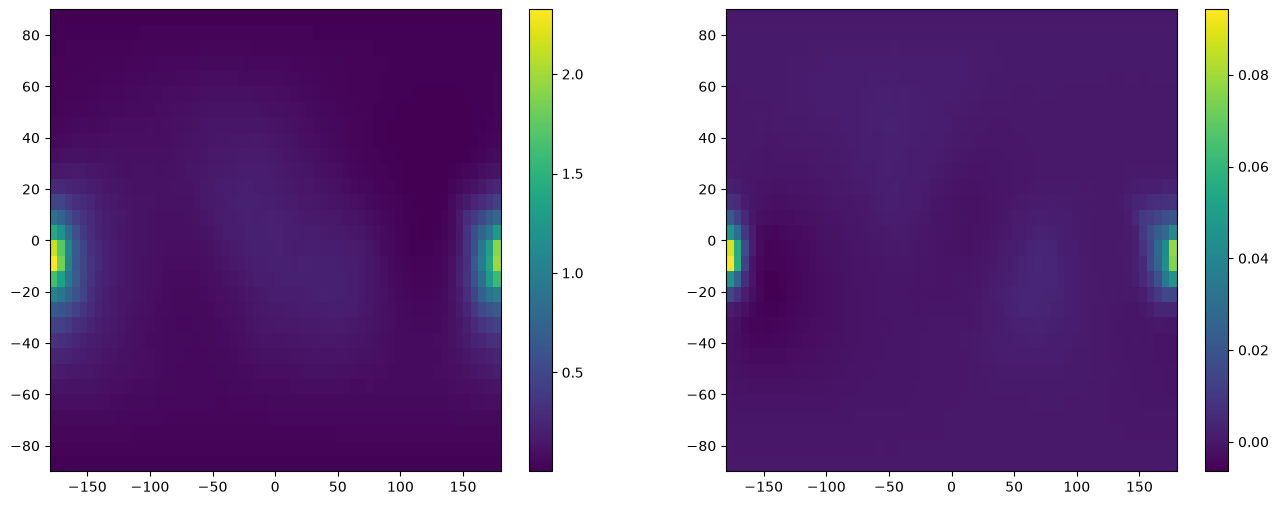

Convolving Delta image, iteration 33


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 33
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 33
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 34, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

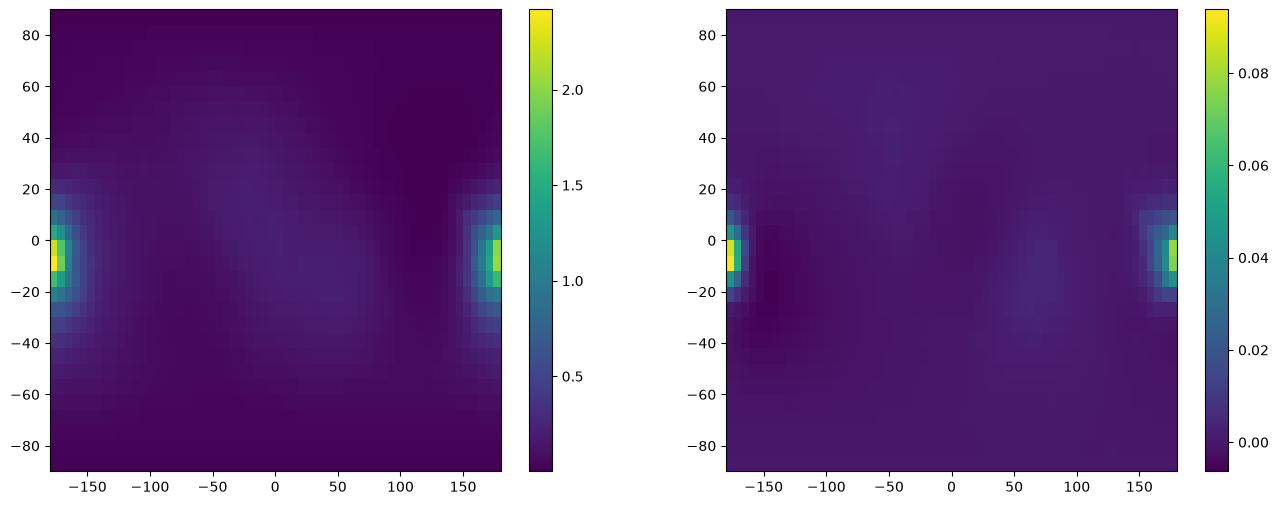

Convolving Delta image, iteration 34


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 34
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 34
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 35, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

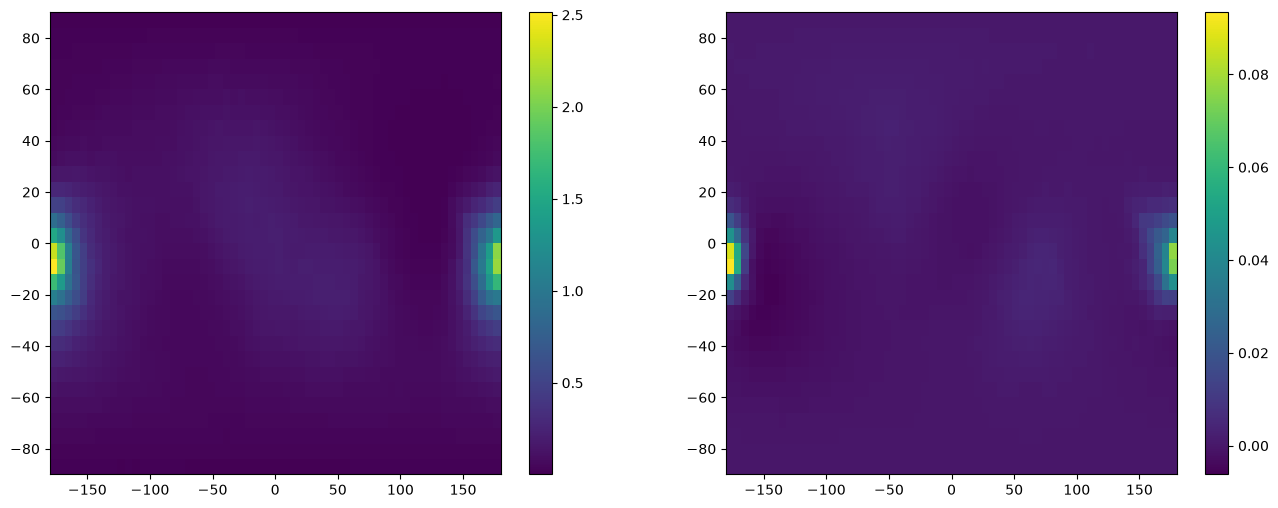

Convolving Delta image, iteration 35


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 35
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 35
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 36, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

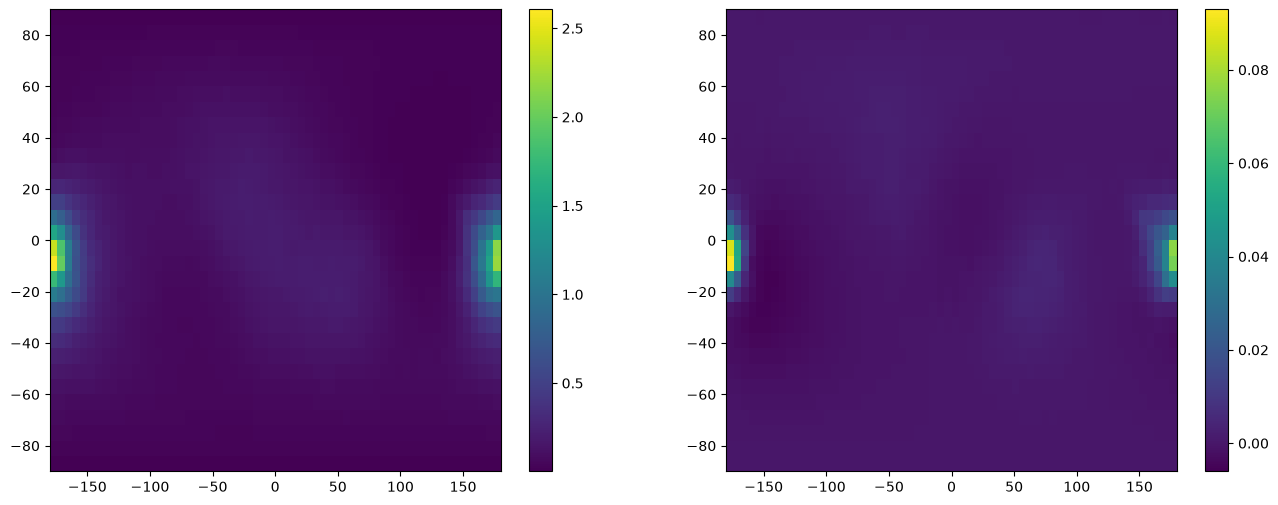

Convolving Delta image, iteration 36


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 36
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 36
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 37, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

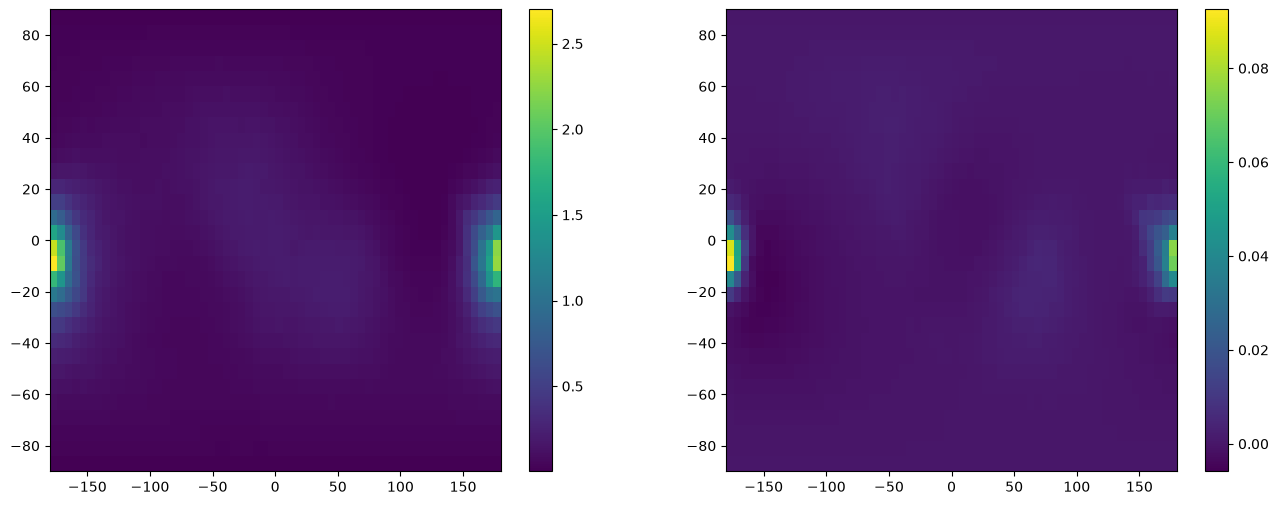

Convolving Delta image, iteration 37


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 37
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 37
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 38, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

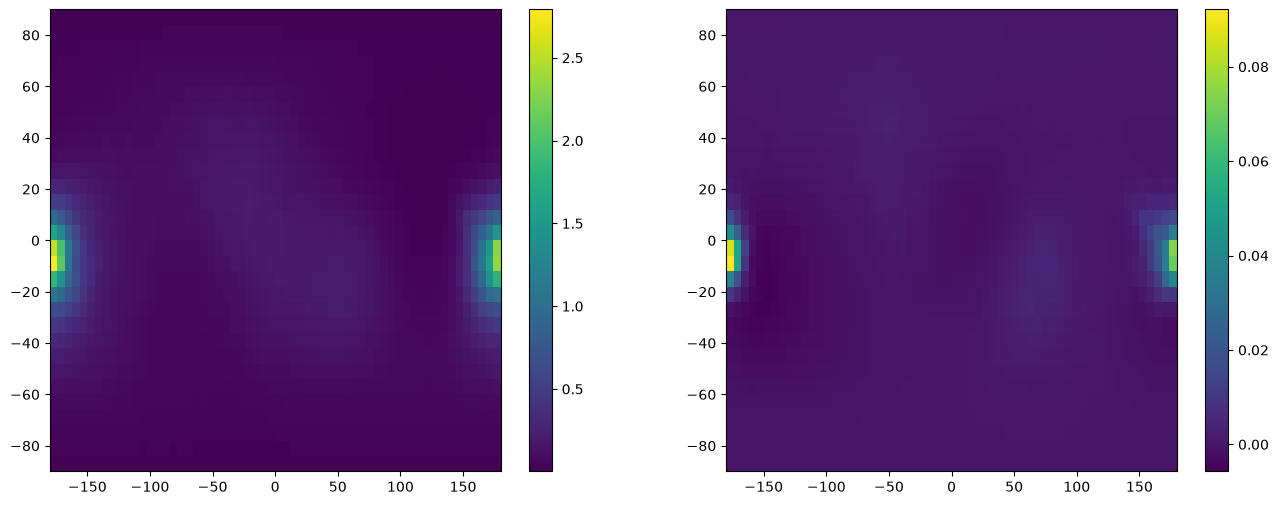

Convolving Delta image, iteration 38


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 38
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 38
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 39, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

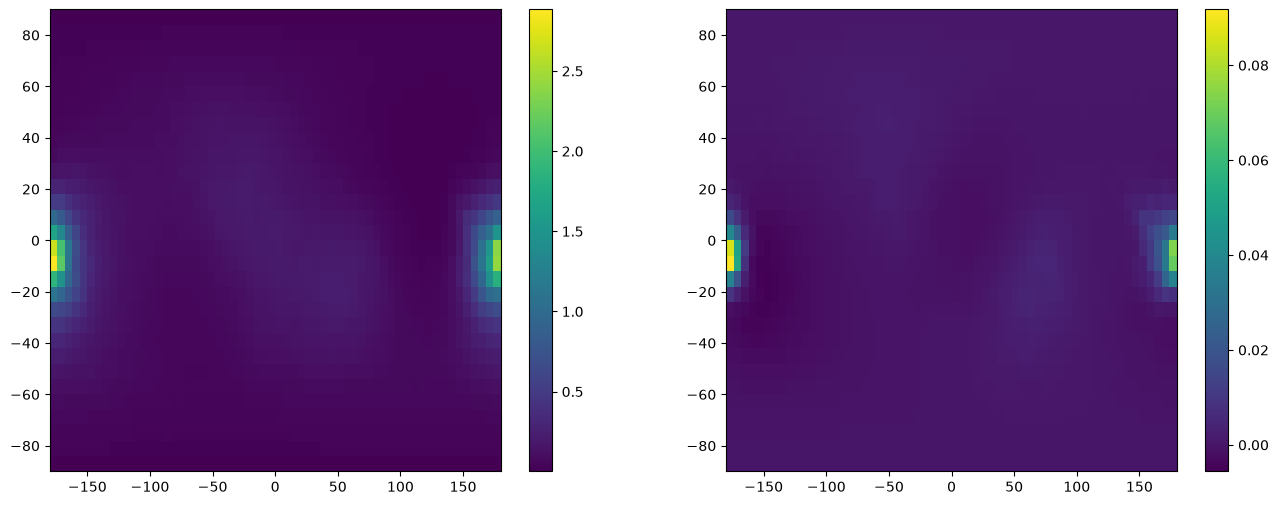

Convolving Delta image, iteration 39


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 39
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 39
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 40, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

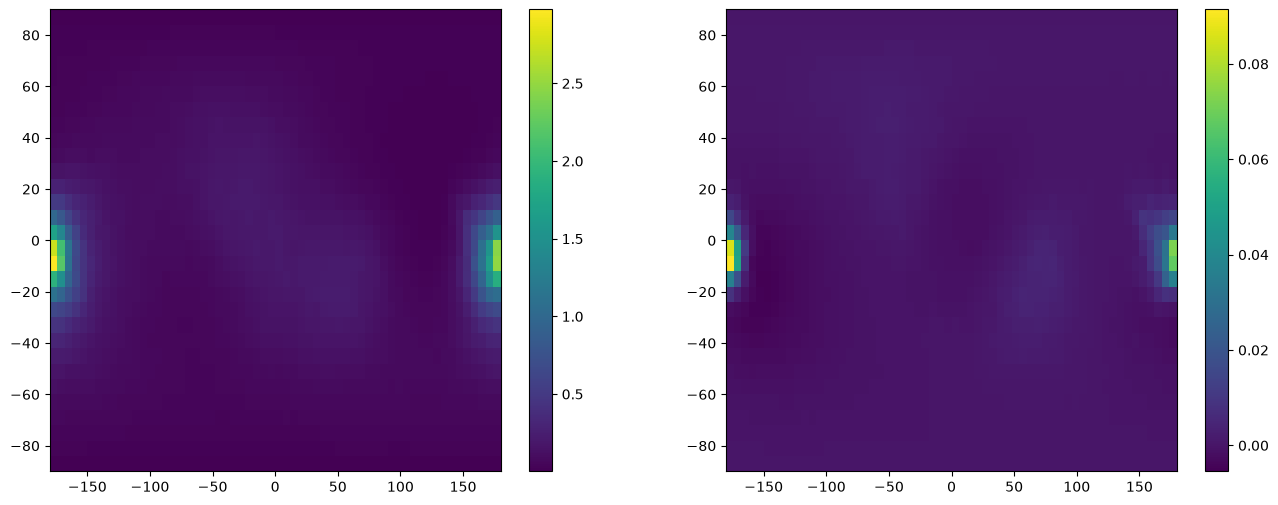

Convolving Delta image, iteration 40


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 40
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 40
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 41, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

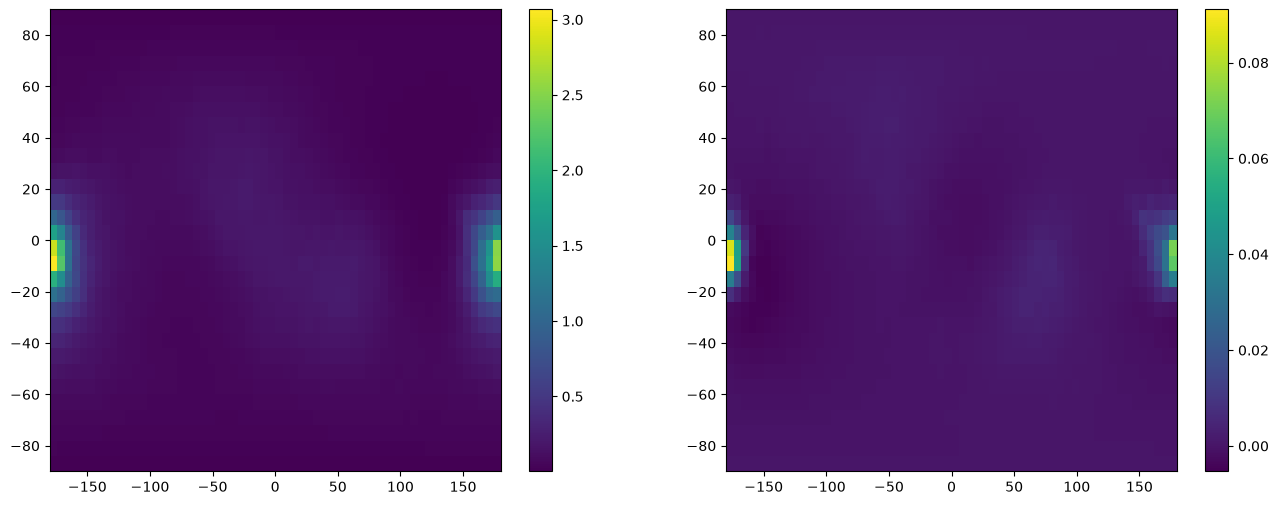

Convolving Delta image, iteration 41


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 41
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 41
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 42, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

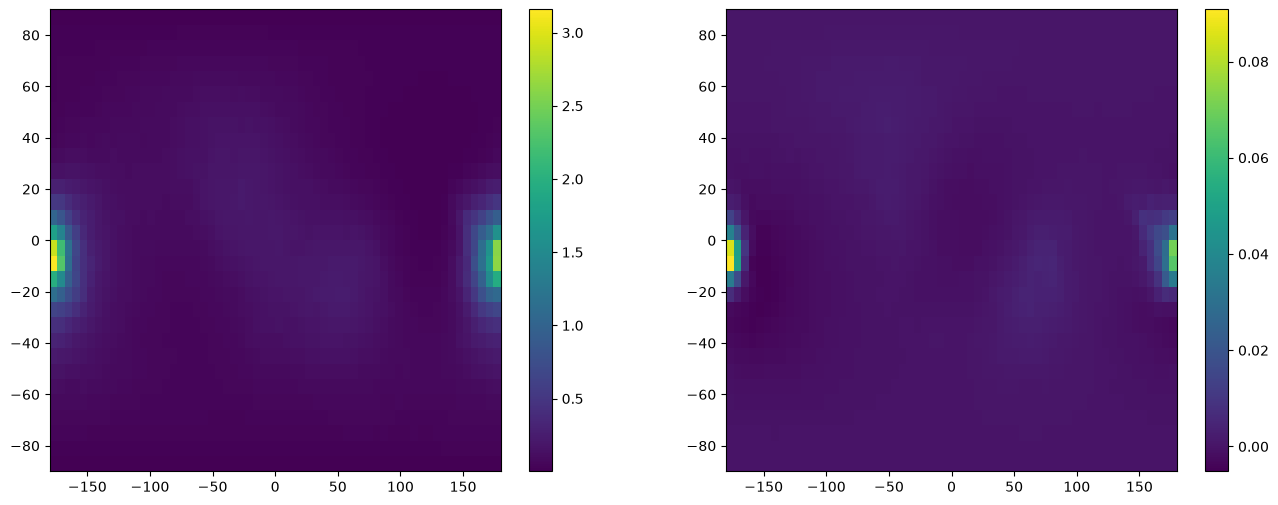

Convolving Delta image, iteration 42


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 42
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 42
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 43, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

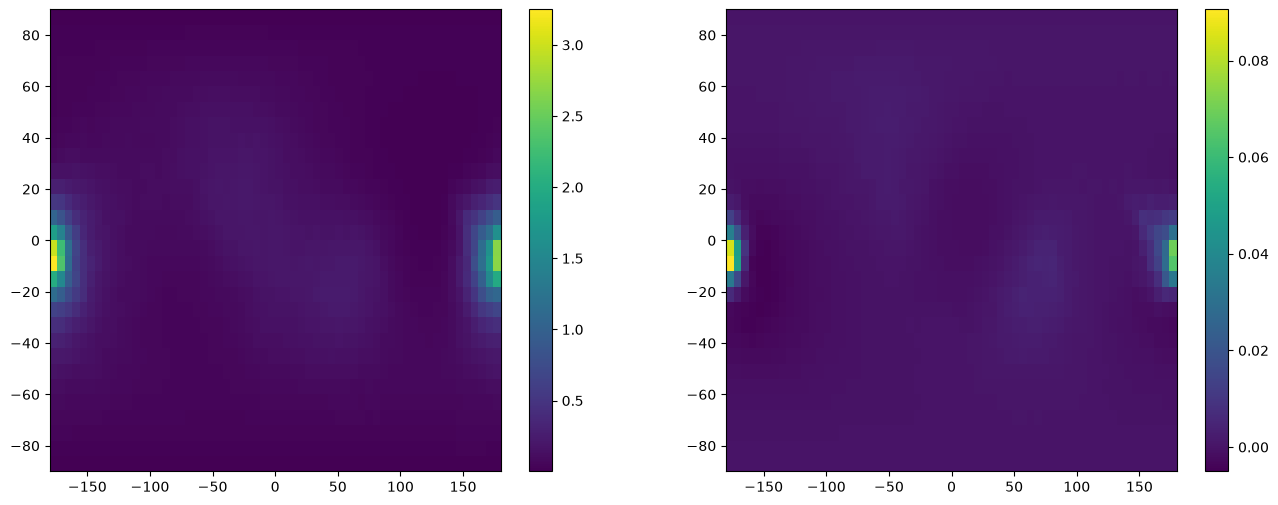

Convolving Delta image, iteration 43


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 43
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 43
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 44, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

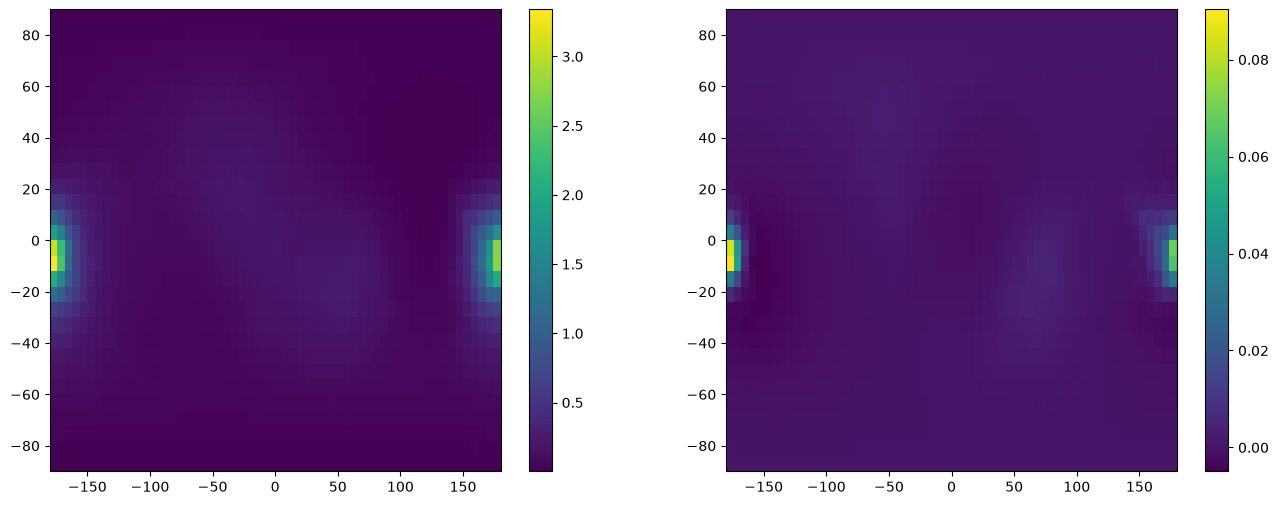

Convolving Delta image, iteration 44


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 44
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 44
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 45, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

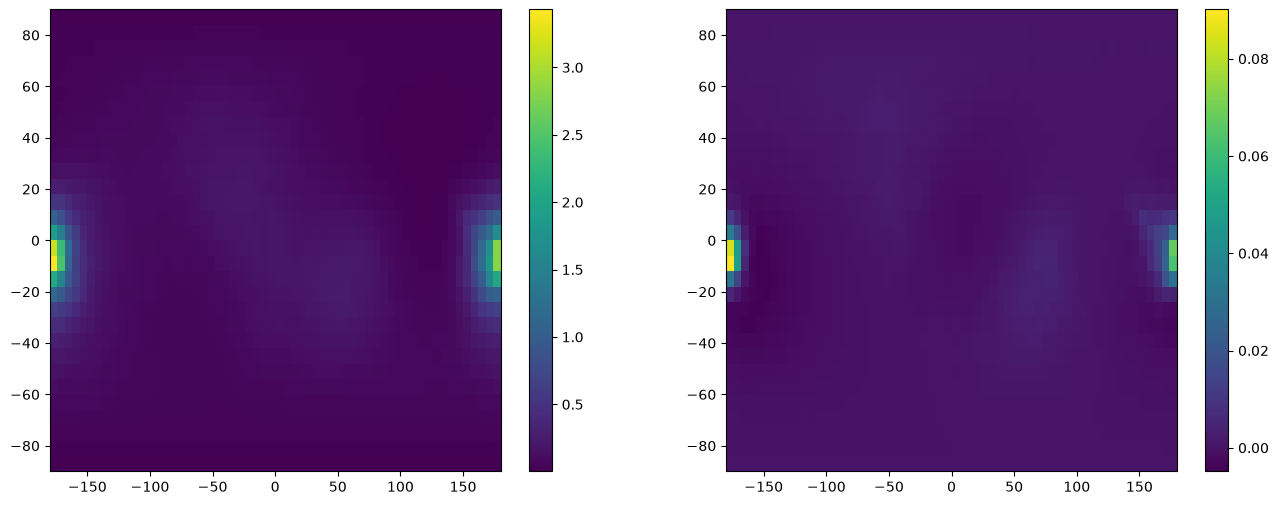

Convolving Delta image, iteration 45


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 45
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 45
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 46, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

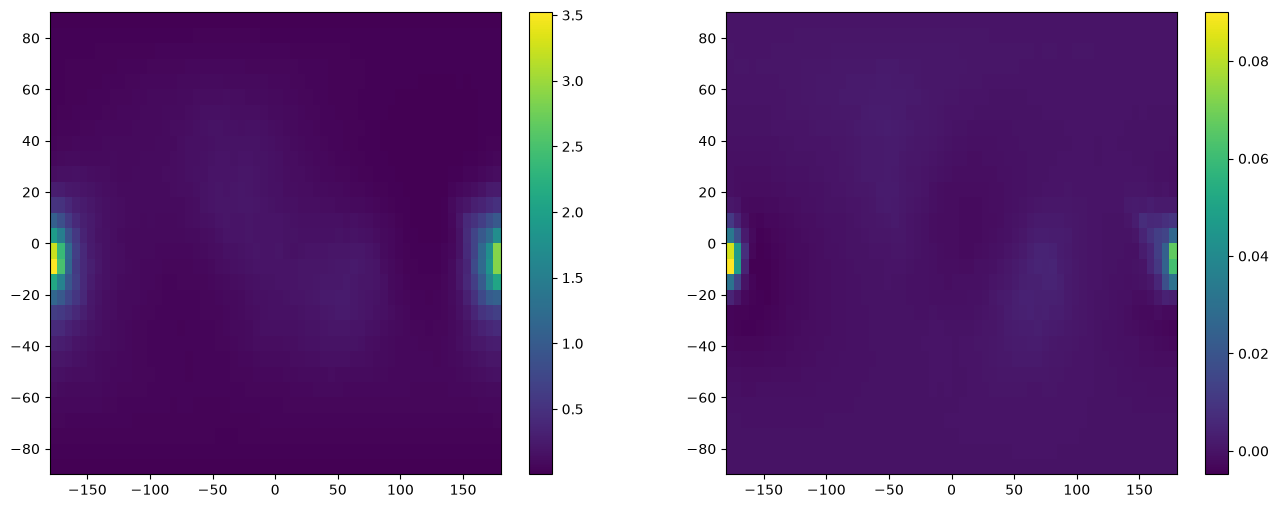

Convolving Delta image, iteration 46


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 46
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 46
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 47, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

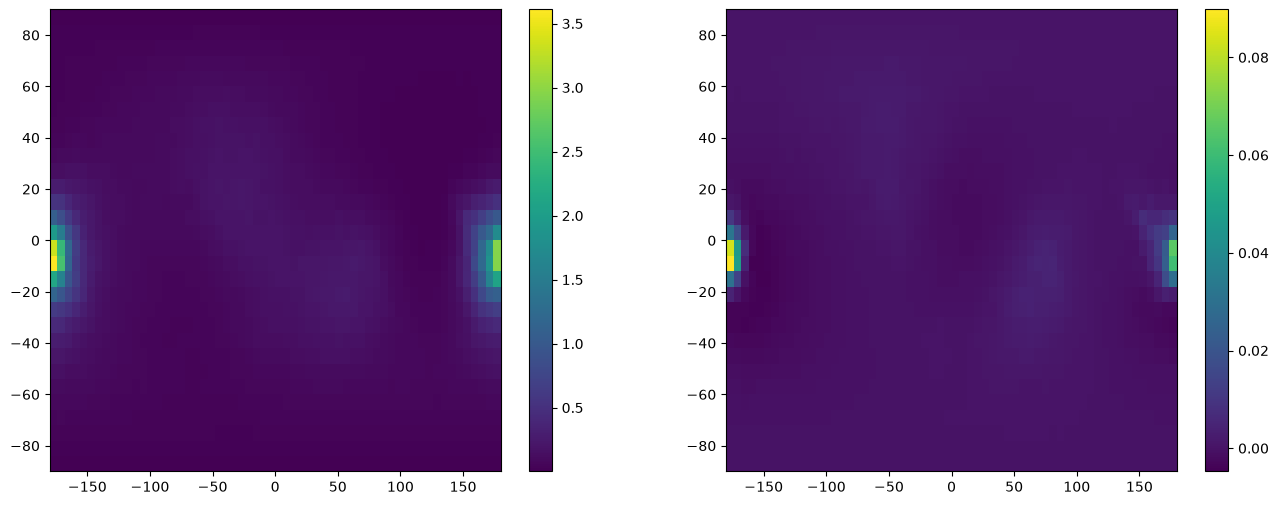

Convolving Delta image, iteration 47


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 47
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 47
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 48, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

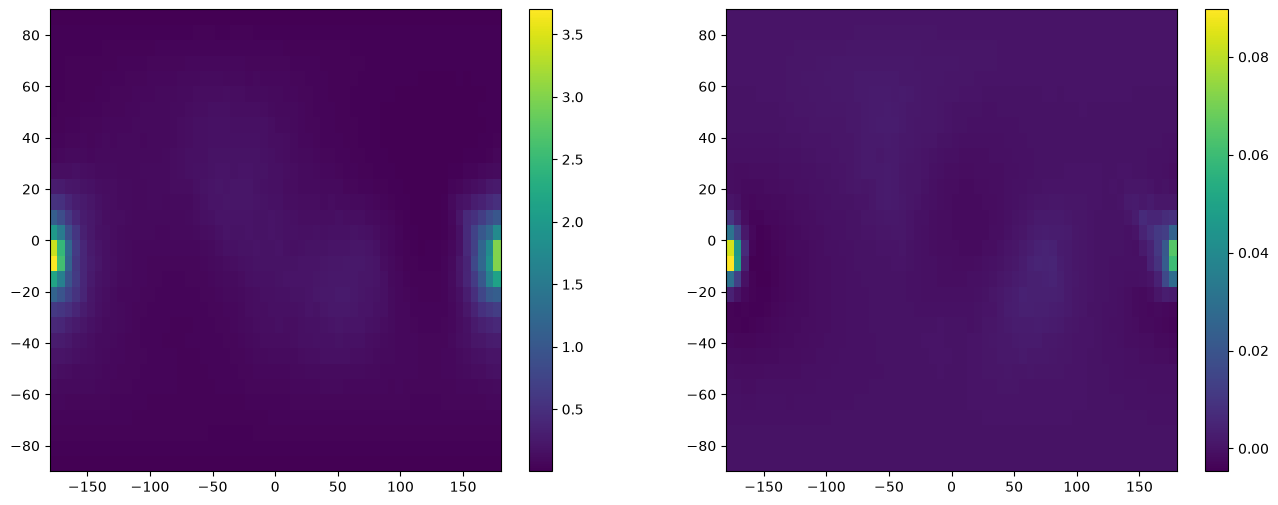

Convolving Delta image, iteration 48


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 48
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 48
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 49, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

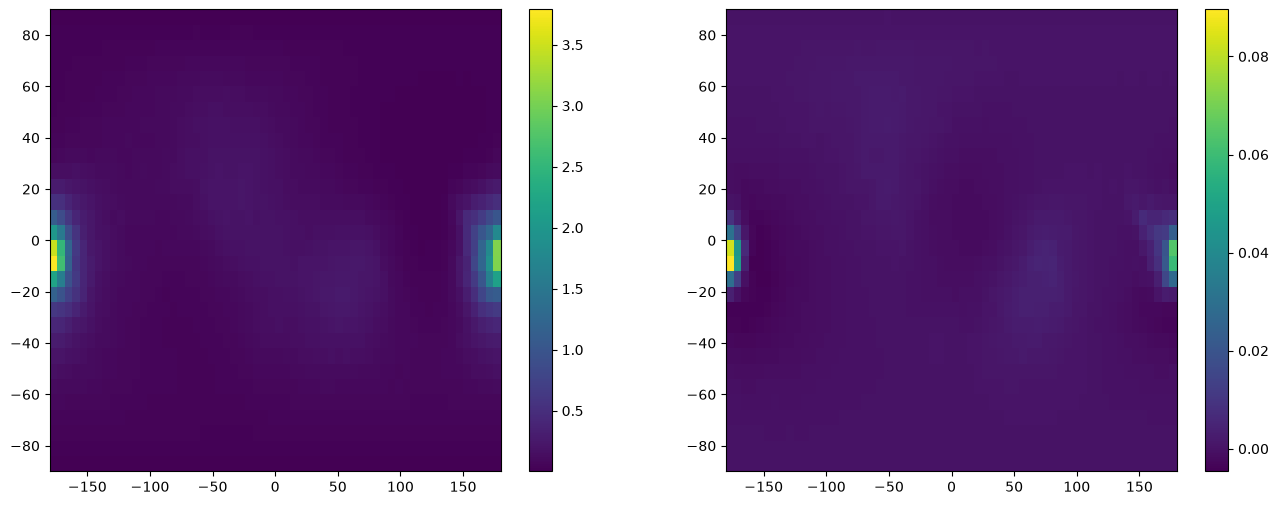

Convolving Delta image, iteration 49


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 49
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 49
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 50, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

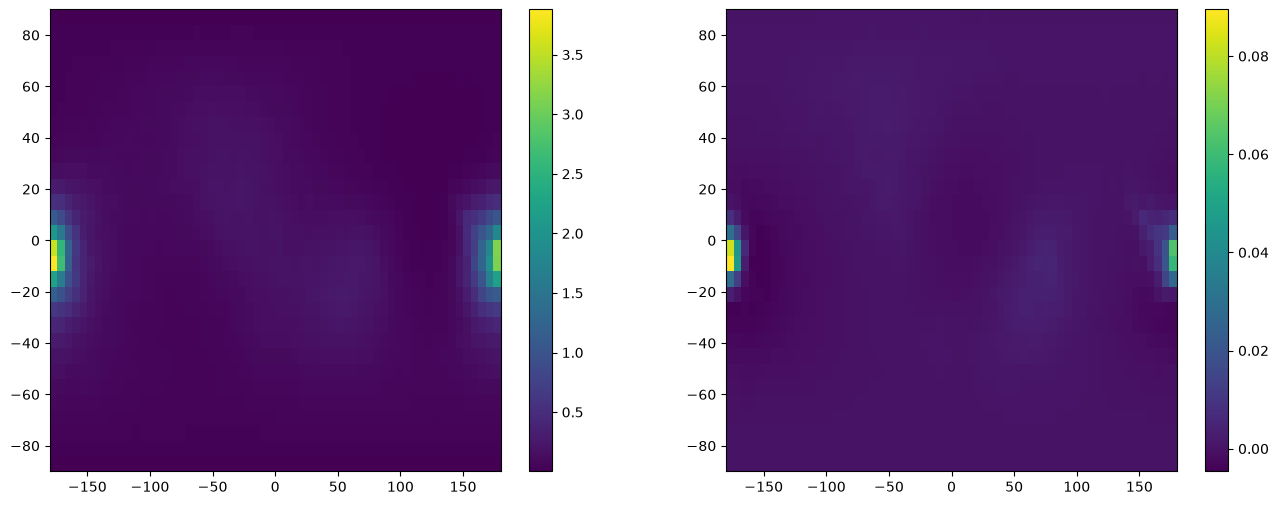

Convolving Delta image, iteration 50


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 50
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 50
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 51, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

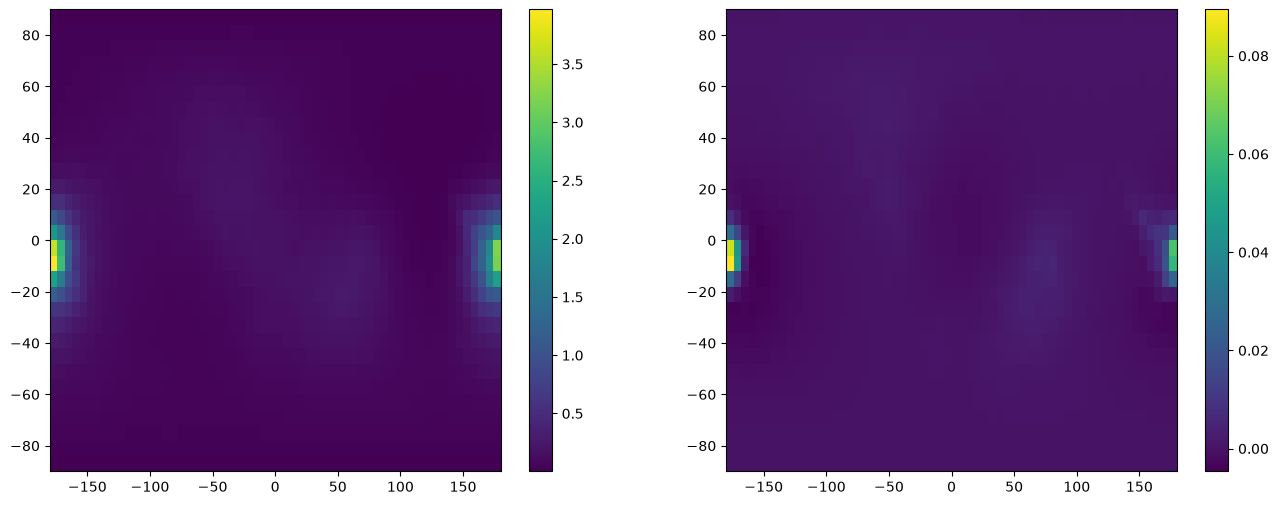

Convolving Delta image, iteration 51


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 51
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 51
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 52, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

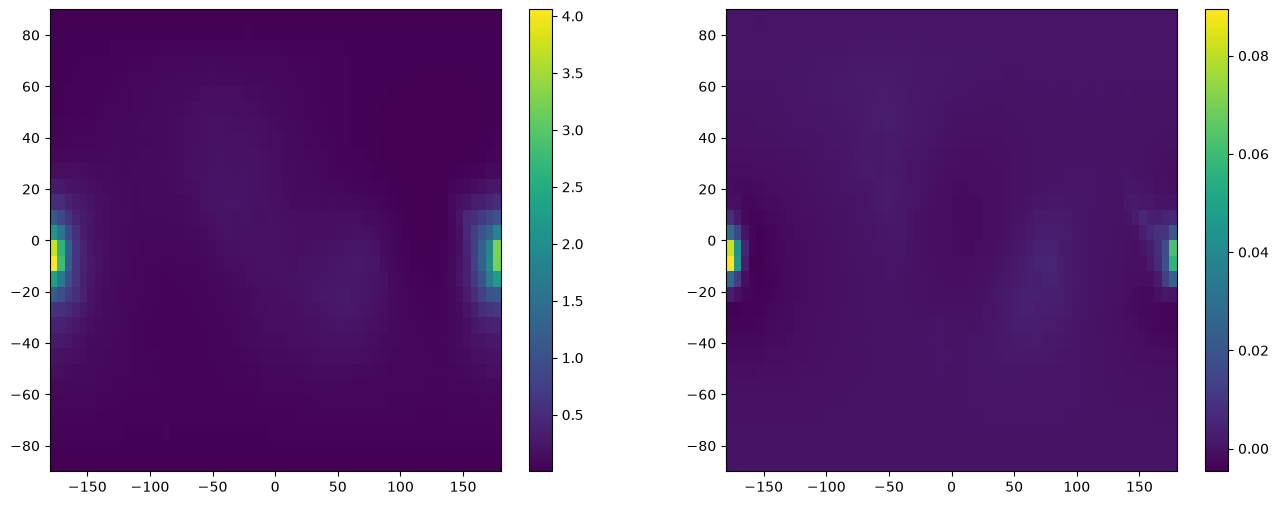

Convolving Delta image, iteration 52


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 52
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 52
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 53, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

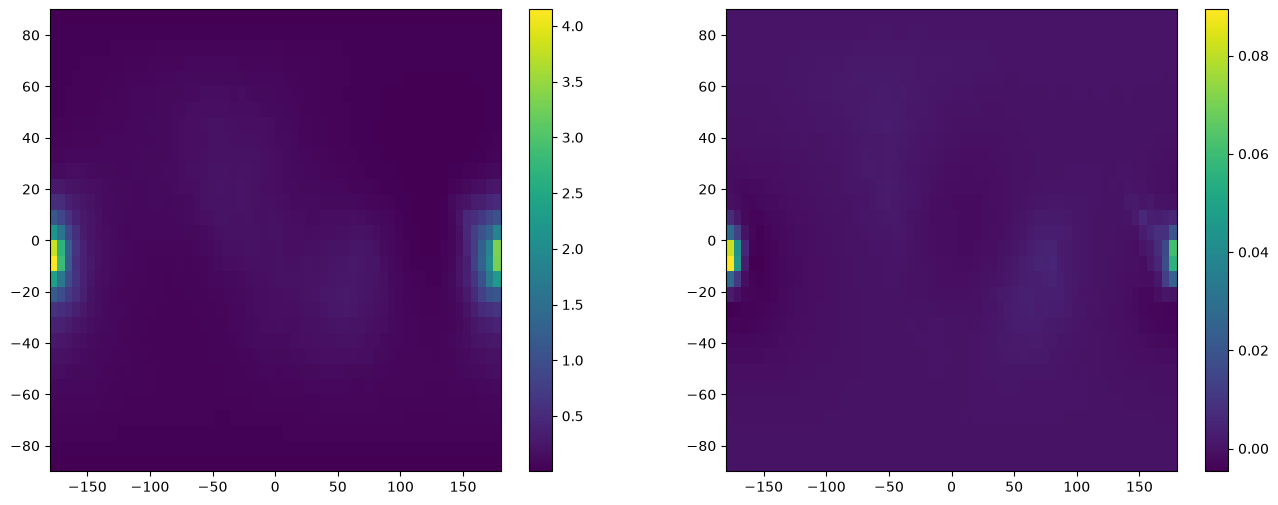

Convolving Delta image, iteration 53


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 53
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 53
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 54, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

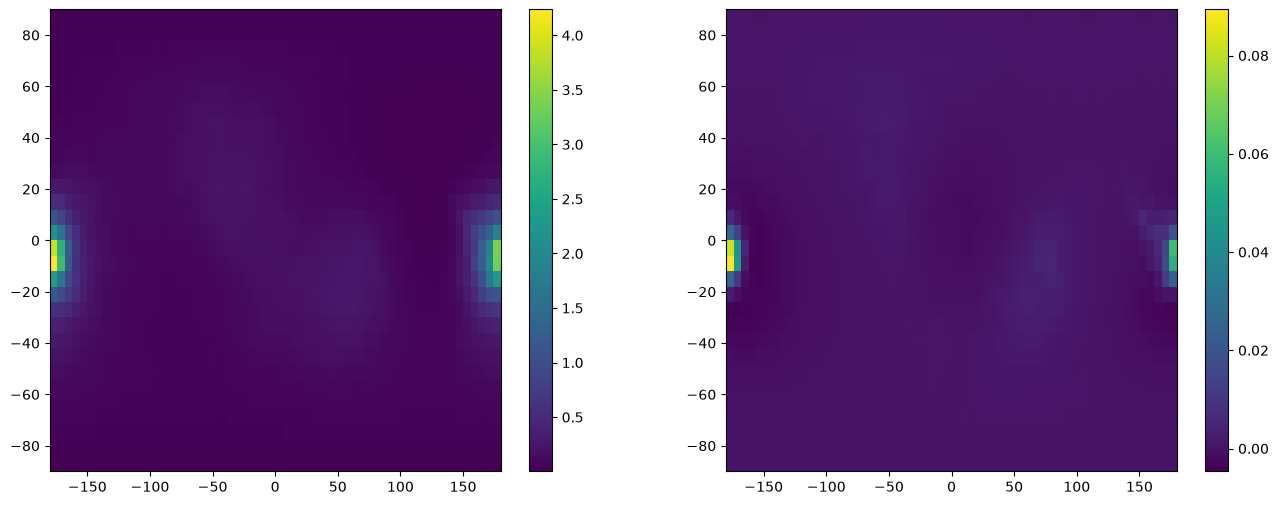

Convolving Delta image, iteration 54


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 54
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 54
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 55, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

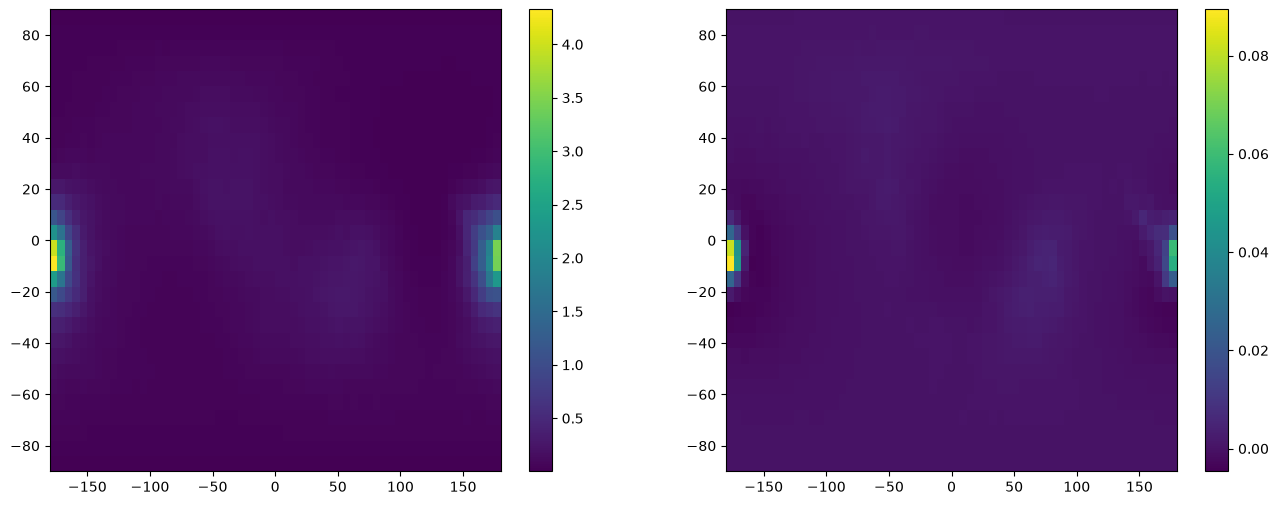

Convolving Delta image, iteration 55


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 55
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 55
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 56, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

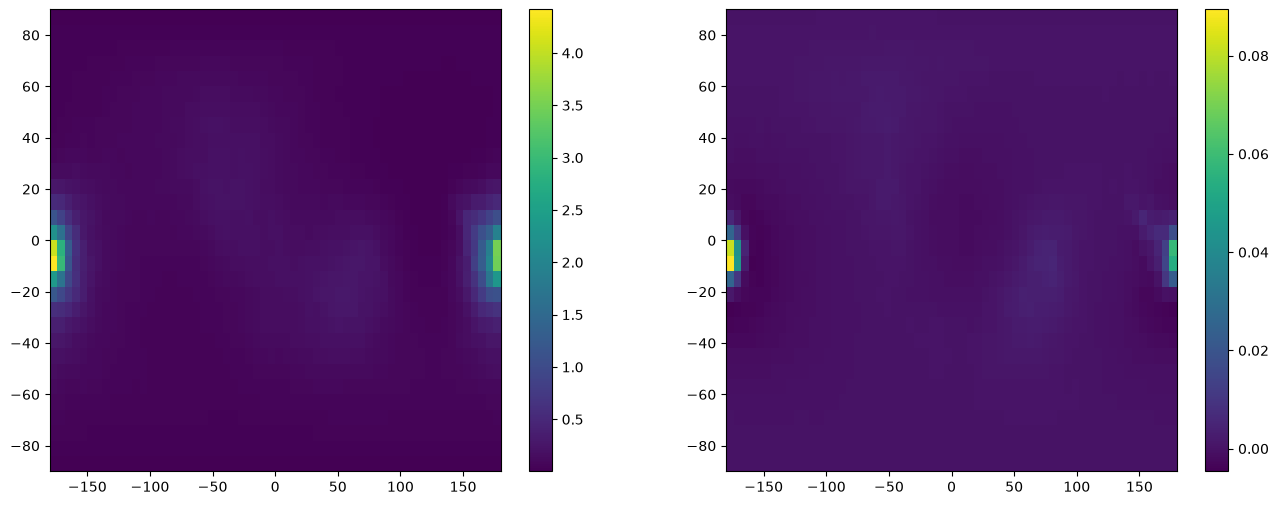

Convolving Delta image, iteration 56


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 56
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 56
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 57, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

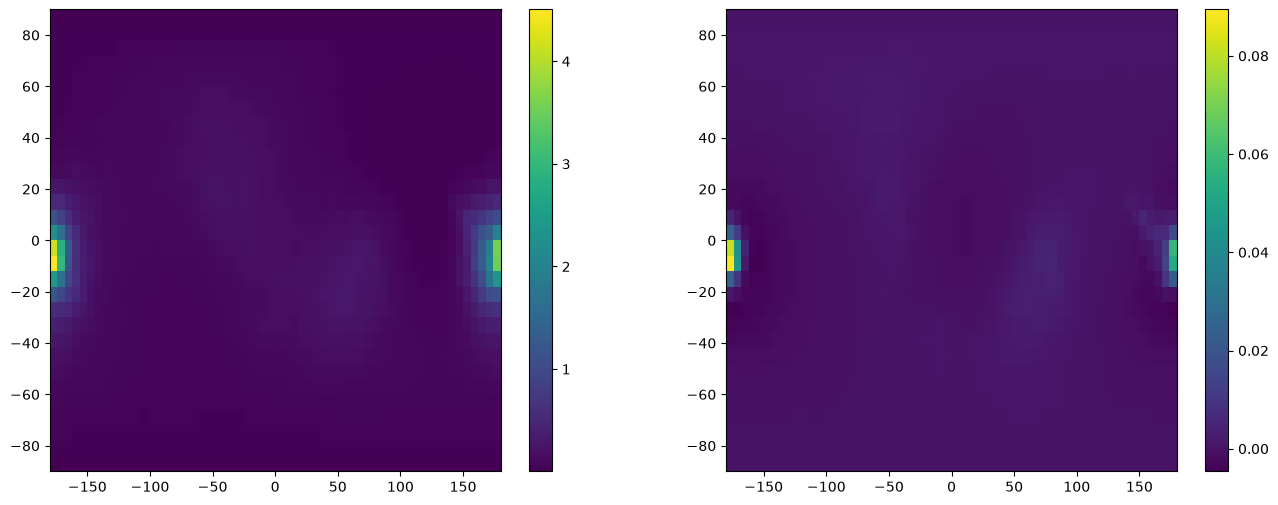

Convolving Delta image, iteration 57


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 57
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 57
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 58, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

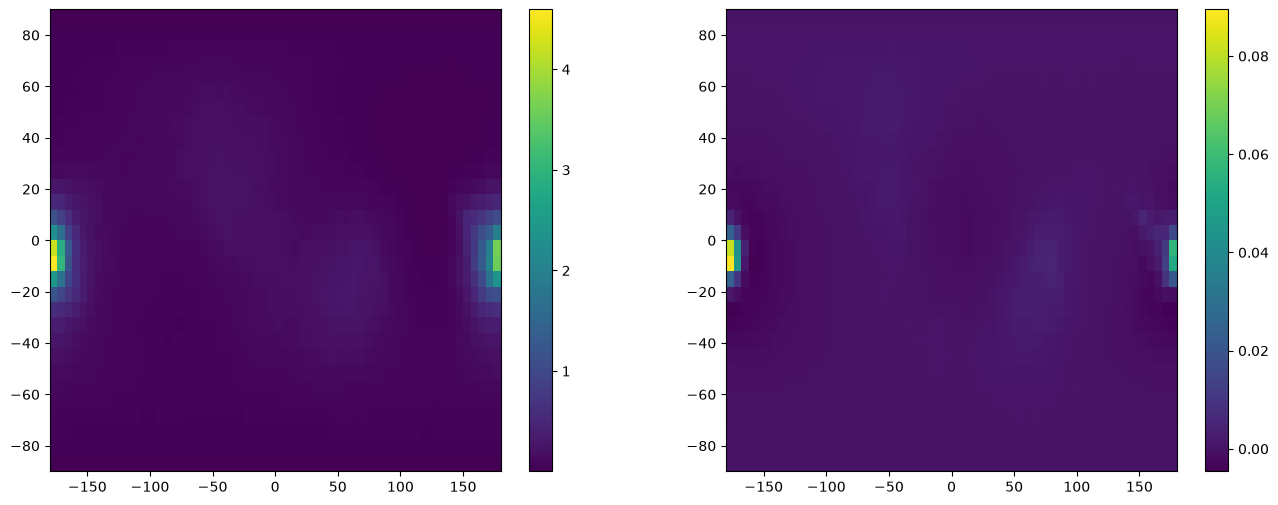

Convolving Delta image, iteration 58


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 58
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 58
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 59, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

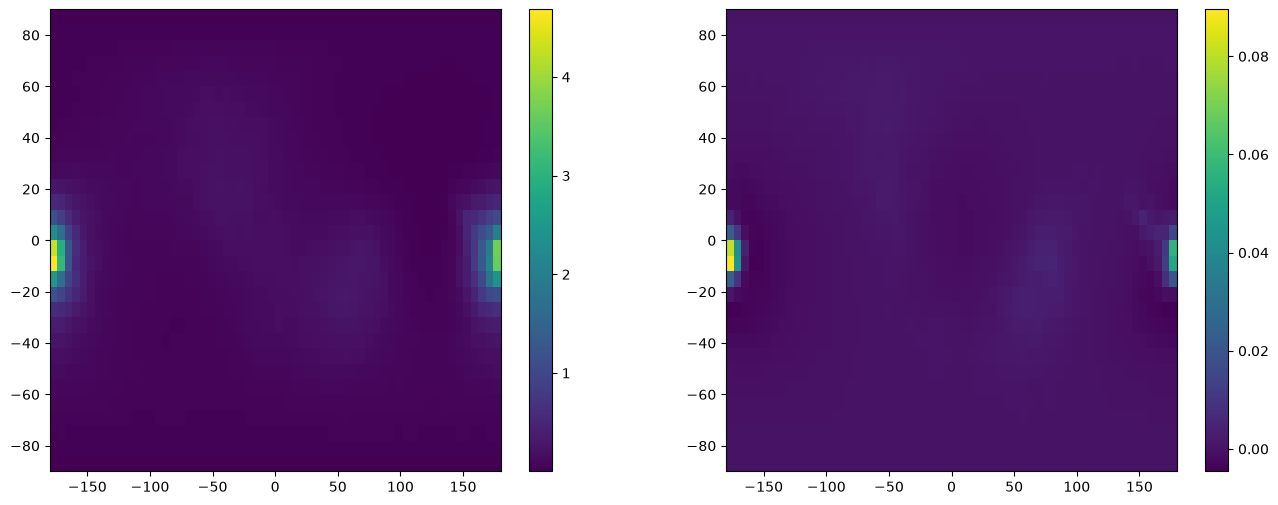

Convolving Delta image, iteration 59


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 59
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 59
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 60, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

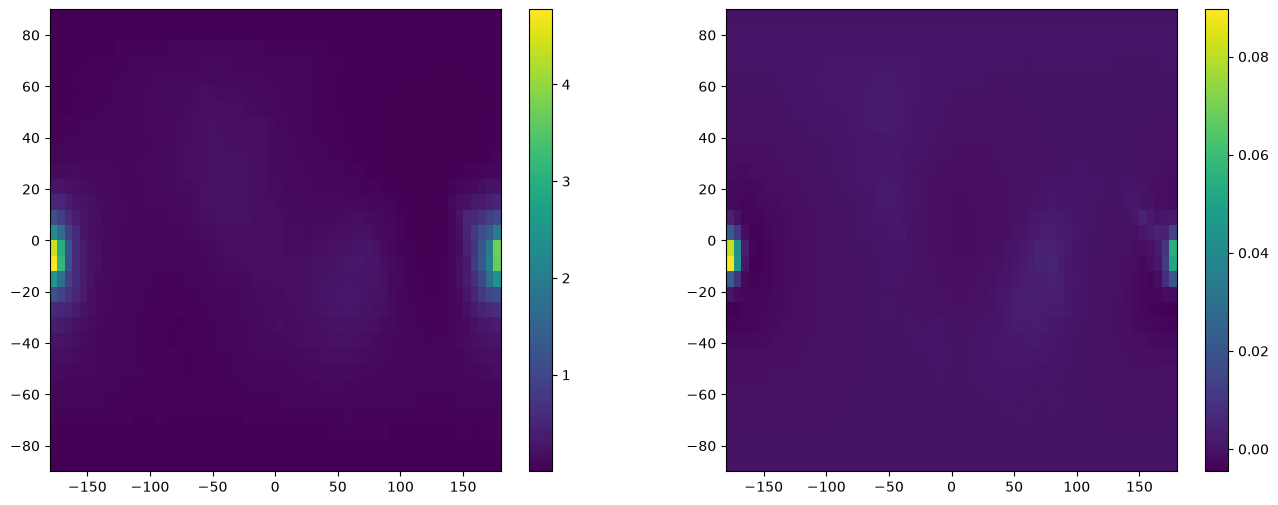

Convolving Delta image, iteration 60


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 60
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 60
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 61, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

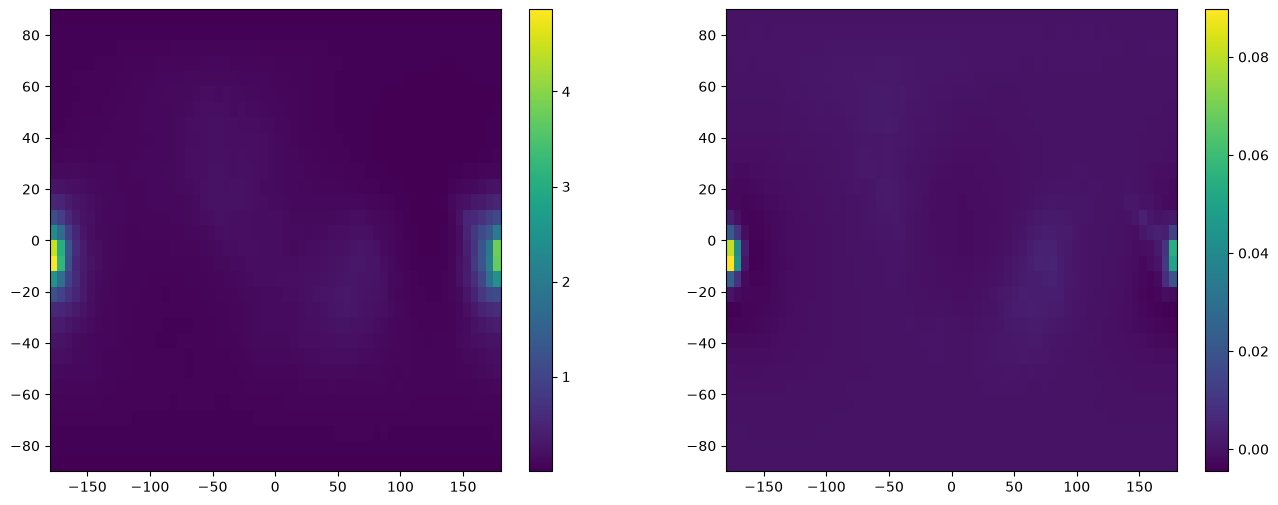

Convolving Delta image, iteration 61


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 61
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 61
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 62, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

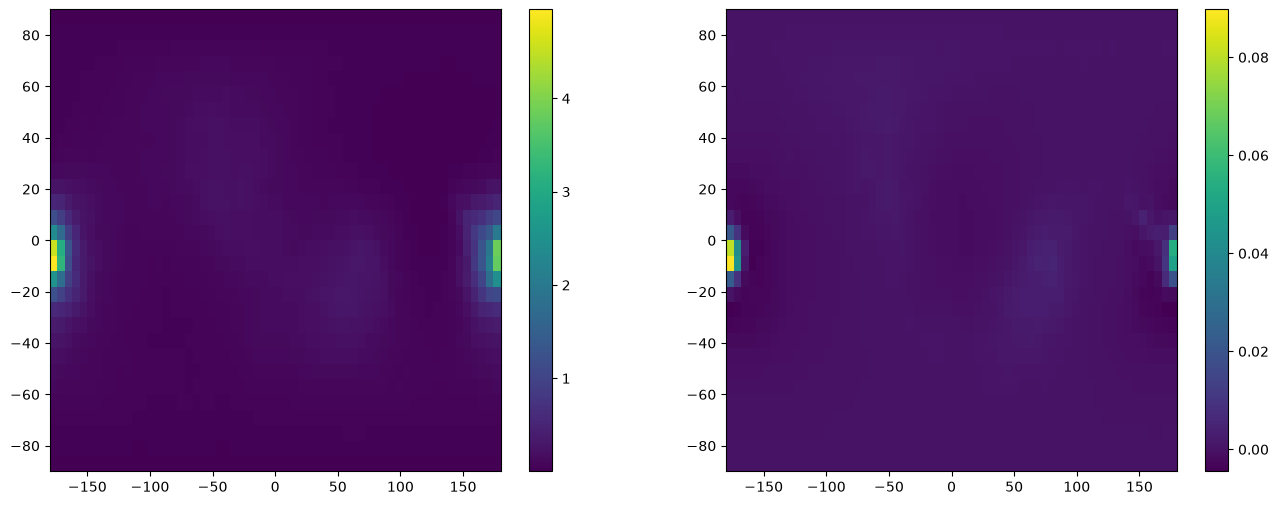

Convolving Delta image, iteration 62


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 62
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 62
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 63, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

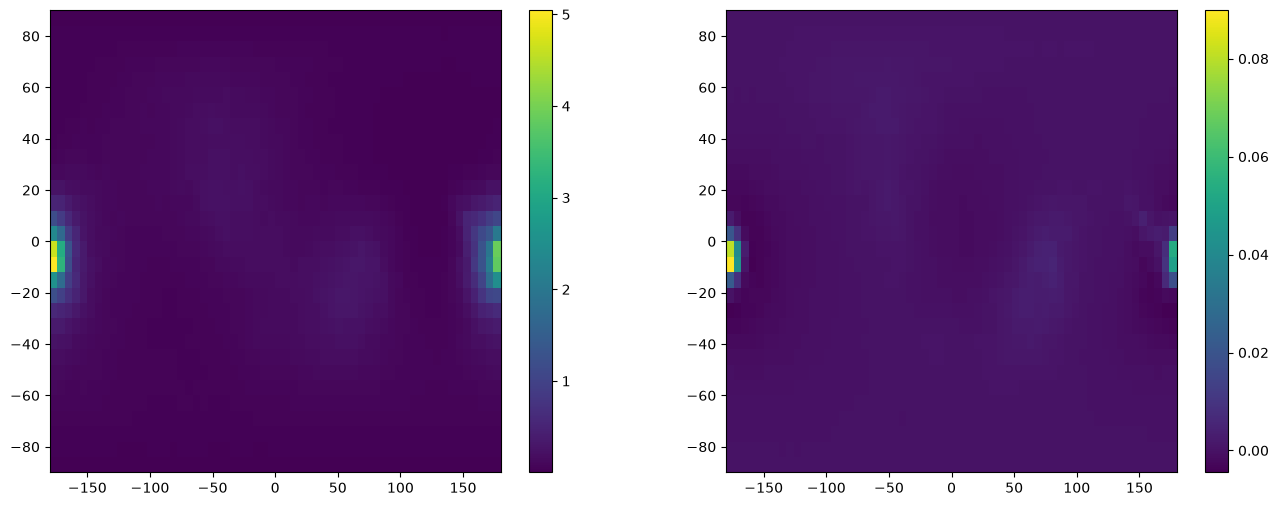

Convolving Delta image, iteration 63


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 63
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 63
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 64, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

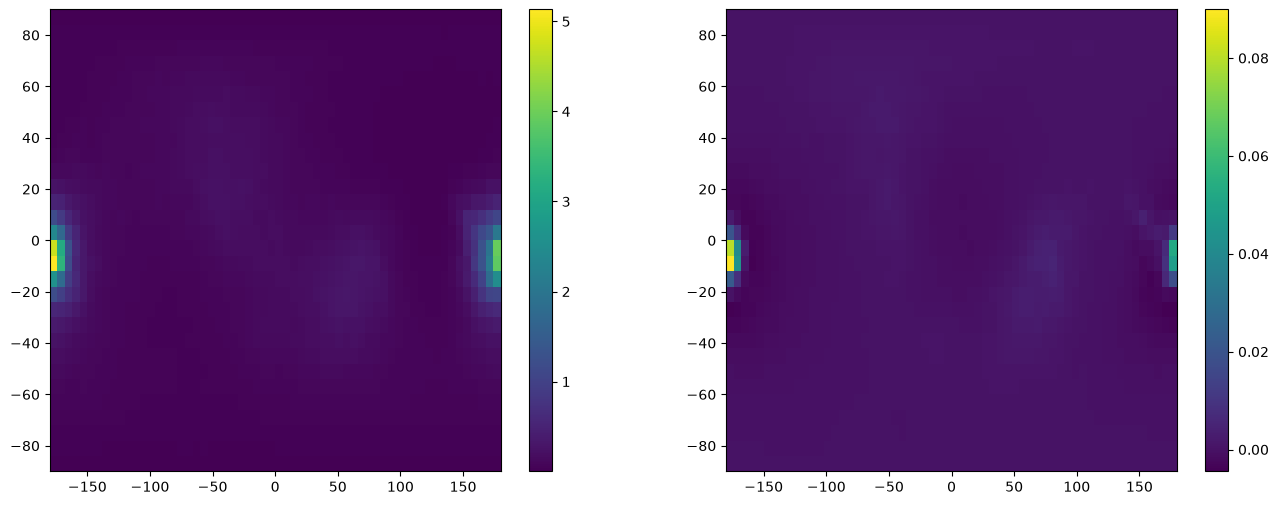

Convolving Delta image, iteration 64


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 64
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 64
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 65, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

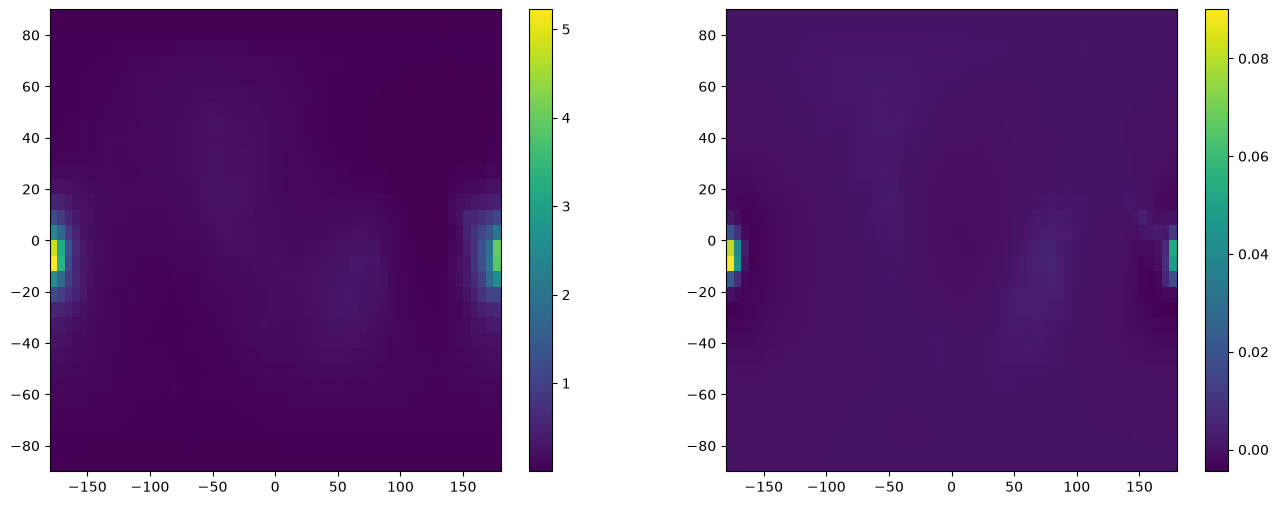

Convolving Delta image, iteration 65


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 65
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 65
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 66, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

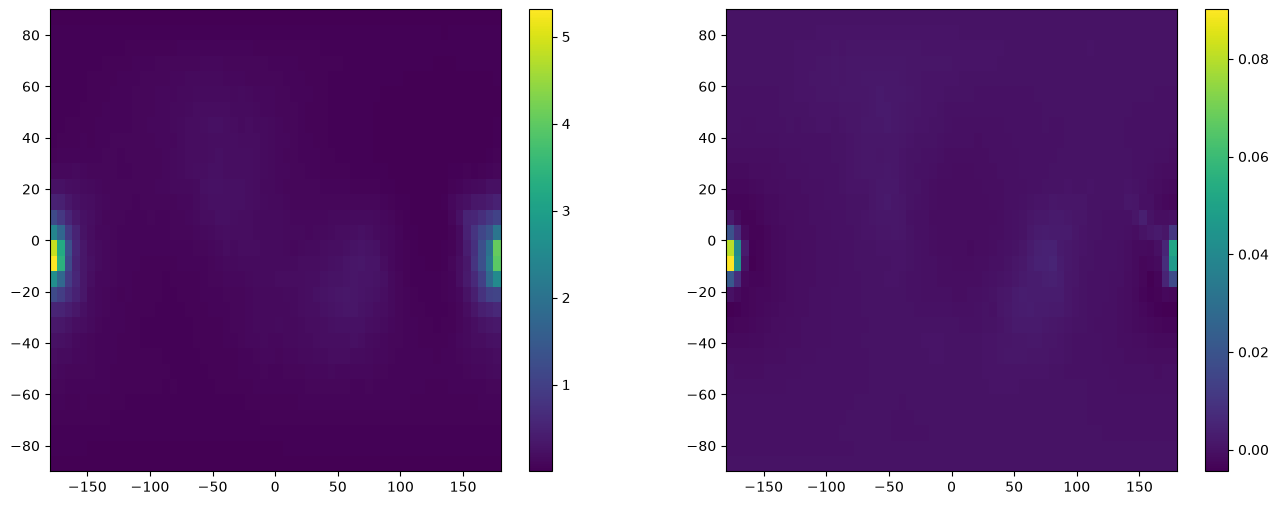

Convolving Delta image, iteration 66


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 66
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 66
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 67, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

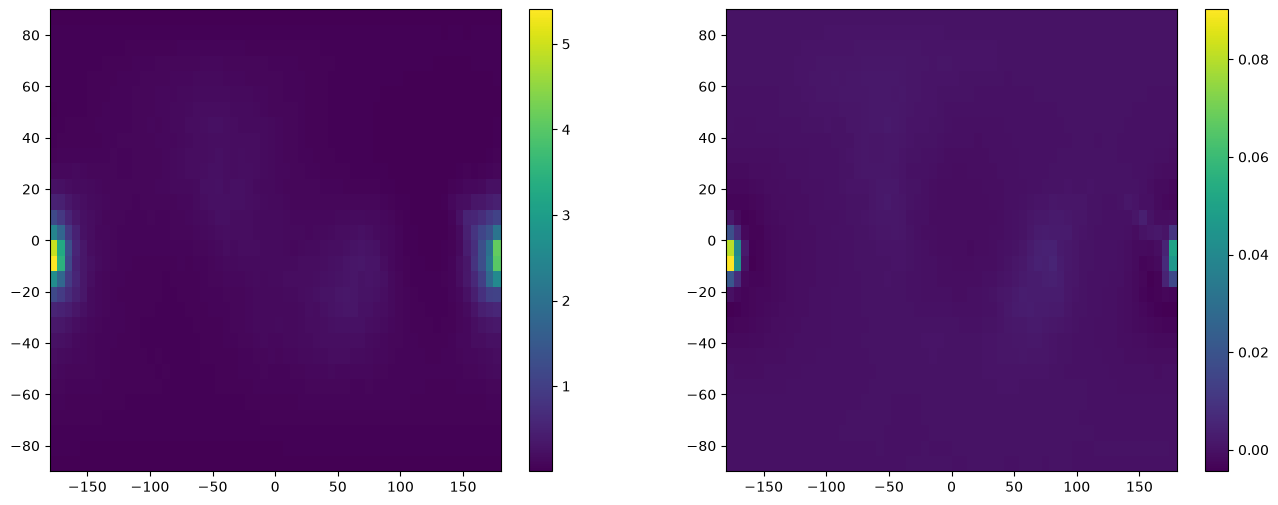

Convolving Delta image, iteration 67


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 67
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 67
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 68, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

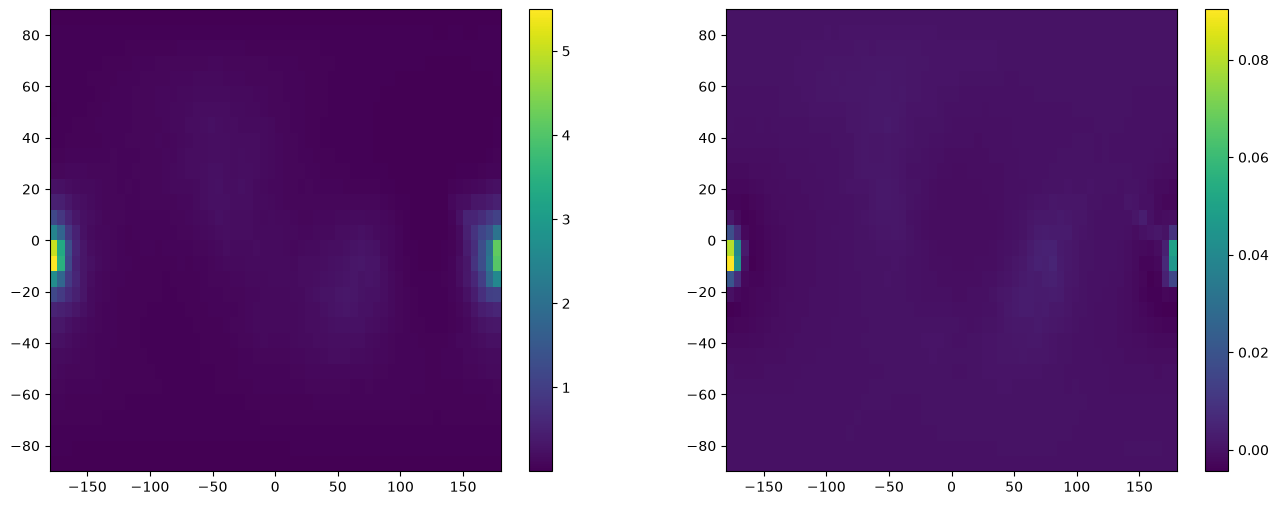

Convolving Delta image, iteration 68


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 68
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 68
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 69, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

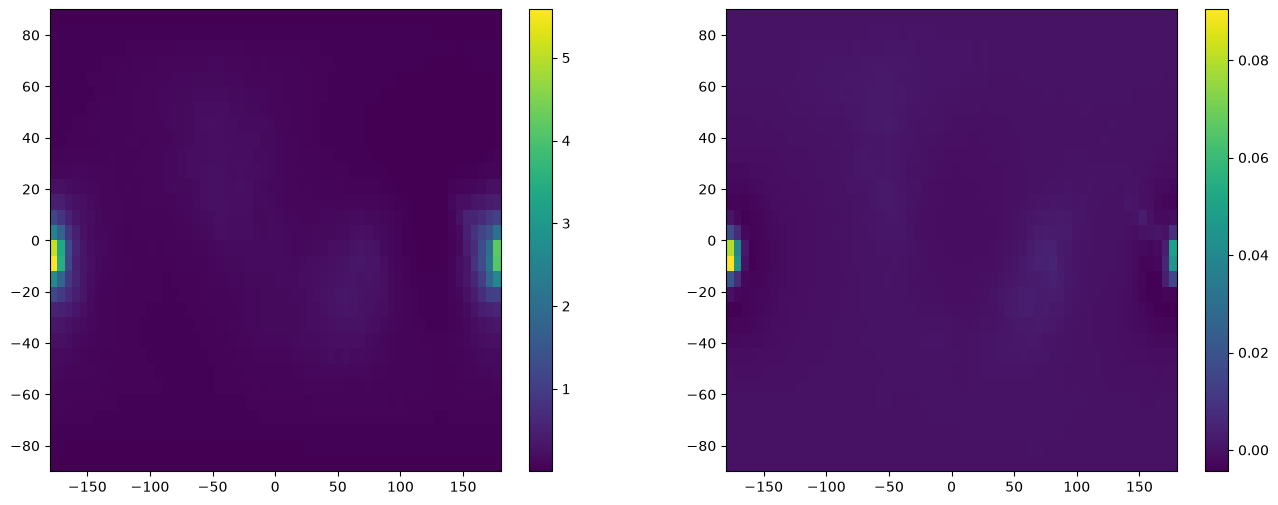

Convolving Delta image, iteration 69


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 69
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 69
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 70, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

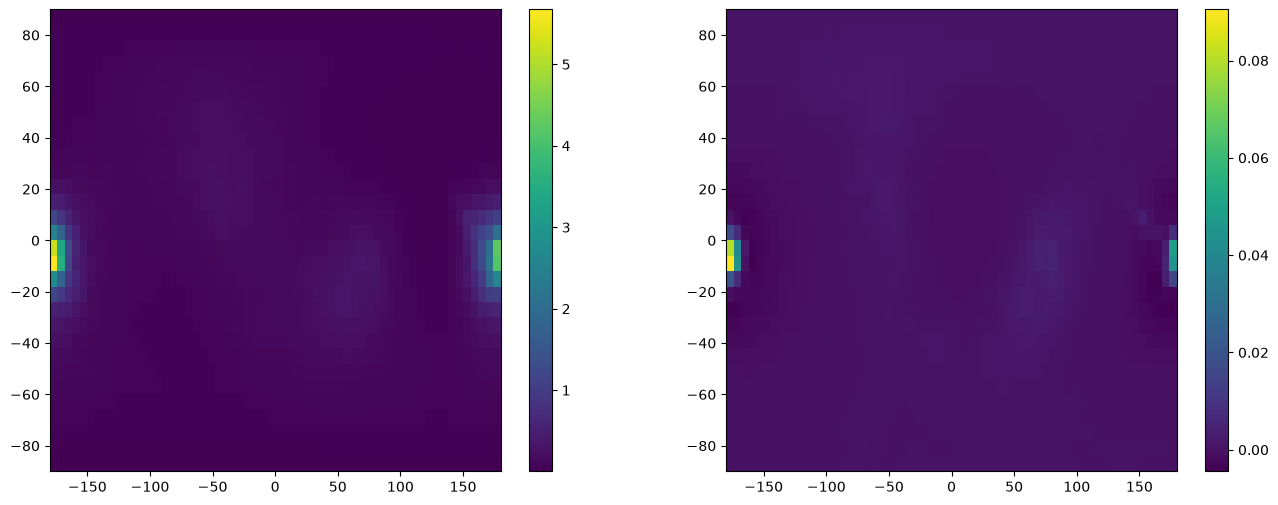

Convolving Delta image, iteration 70


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 70
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 70
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 71, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

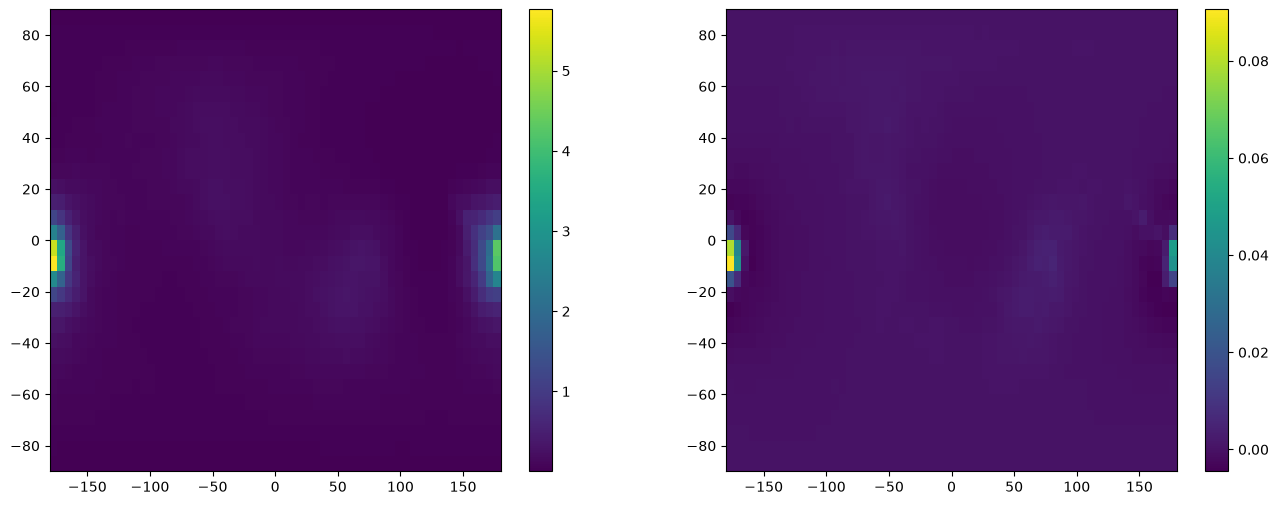

Convolving Delta image, iteration 71


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 71
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 71
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 72, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

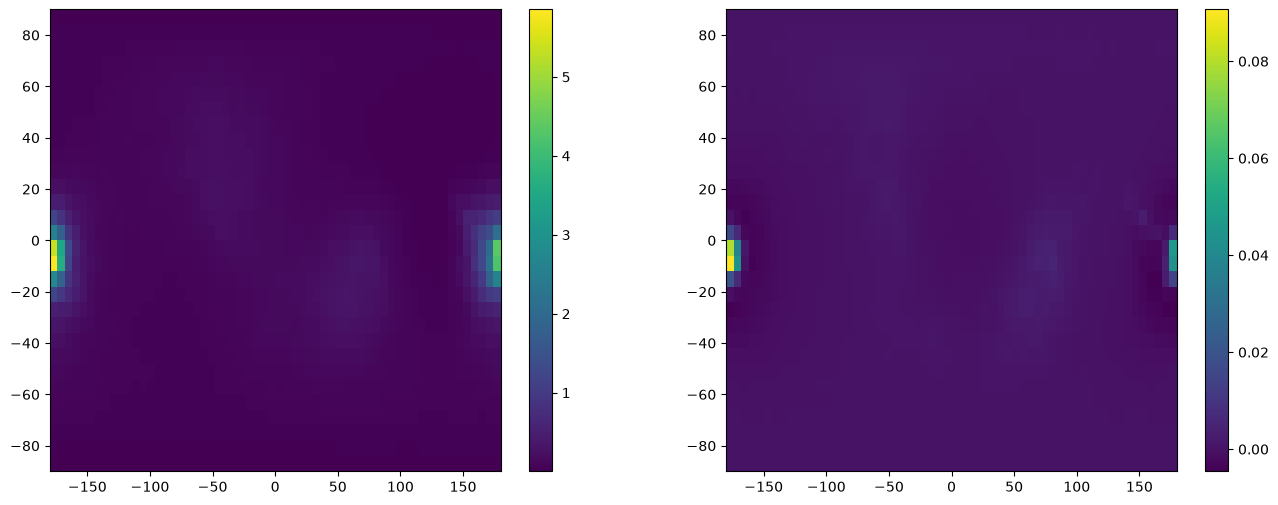

Convolving Delta image, iteration 72


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 72
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 72
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 73, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

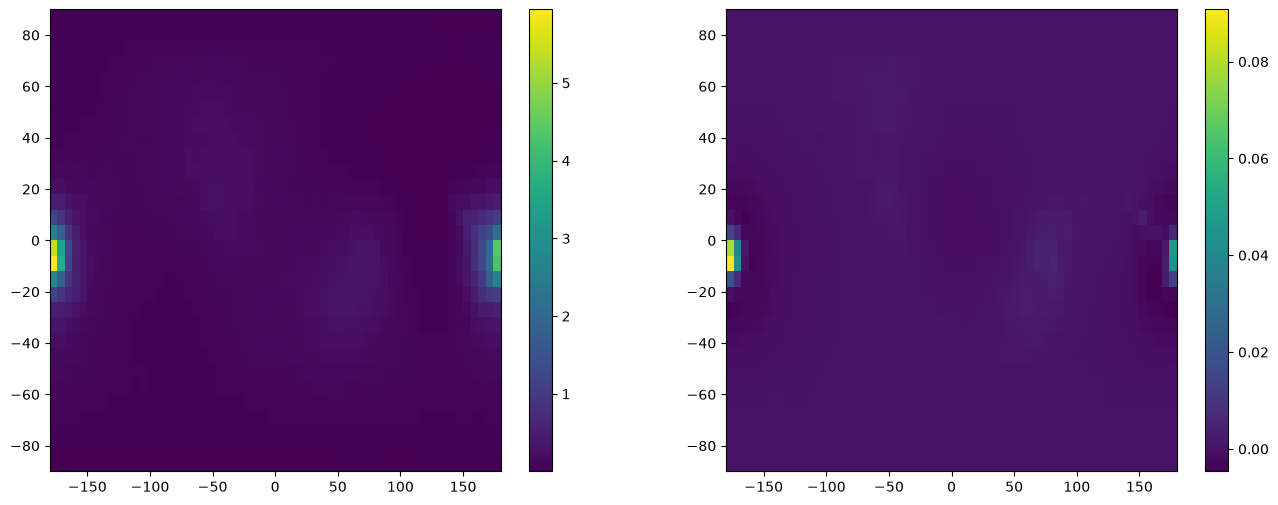

Convolving Delta image, iteration 73


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 73
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 73
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 74, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

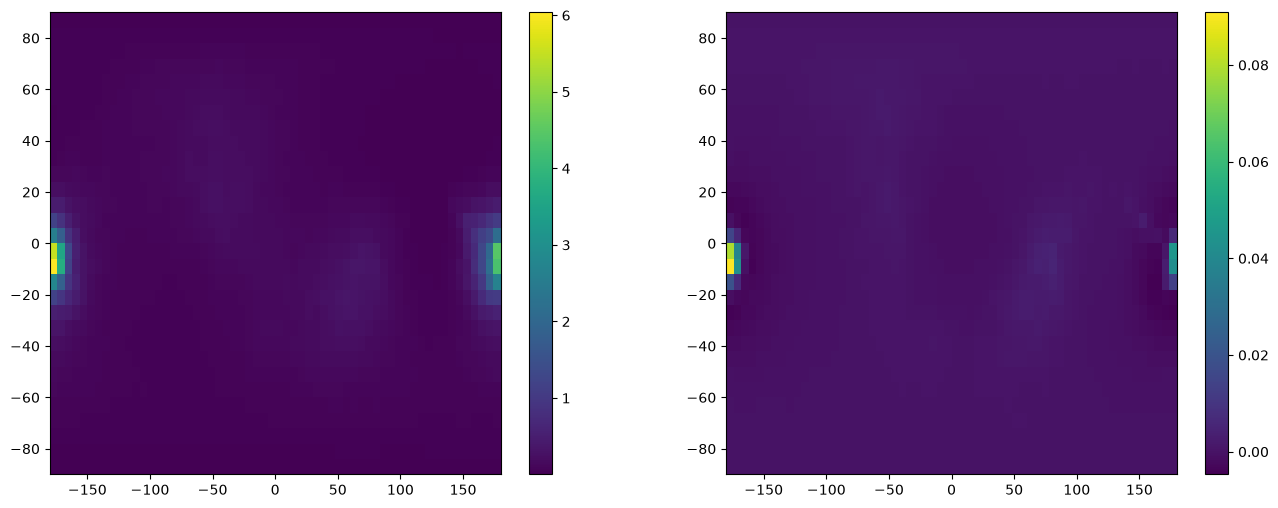

Convolving Delta image, iteration 74


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 74
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 74
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 75, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

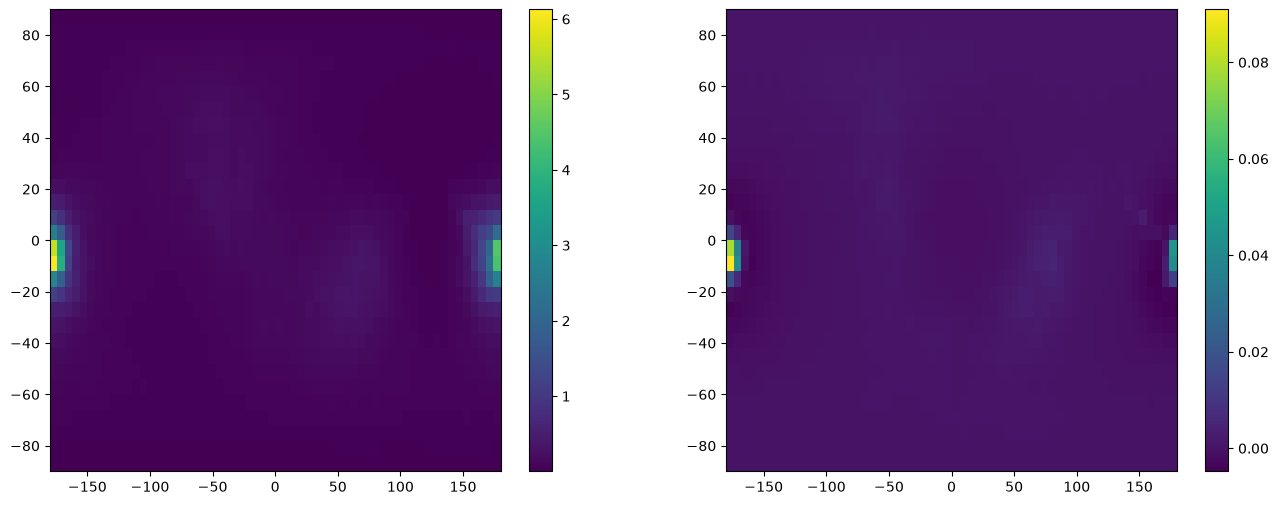

Convolving Delta image, iteration 75


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 75
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 75
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 76, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

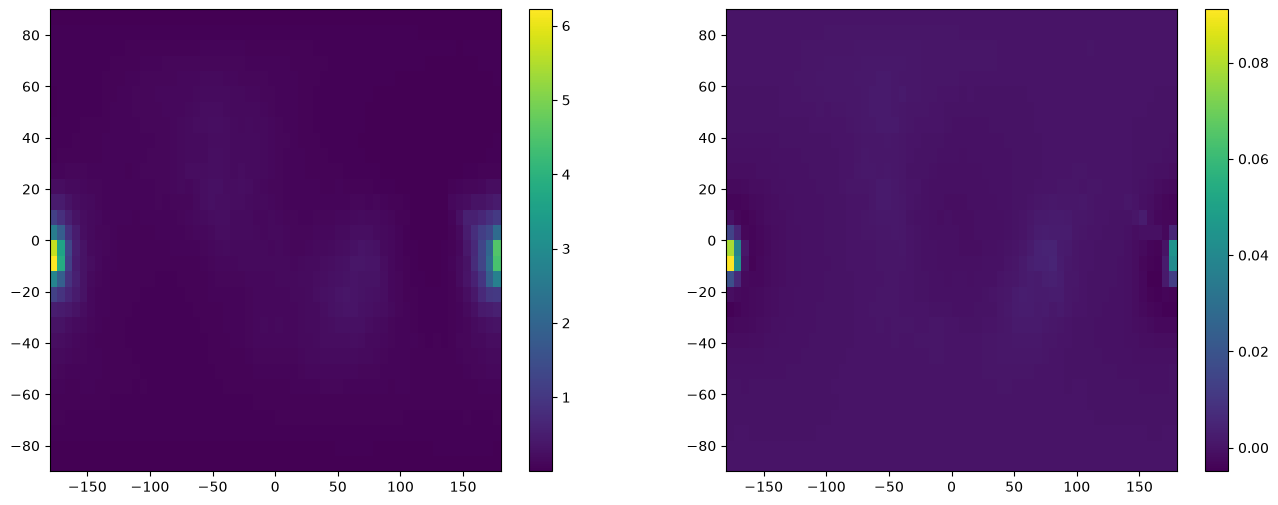

Convolving Delta image, iteration 76


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 76
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 76
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 77, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

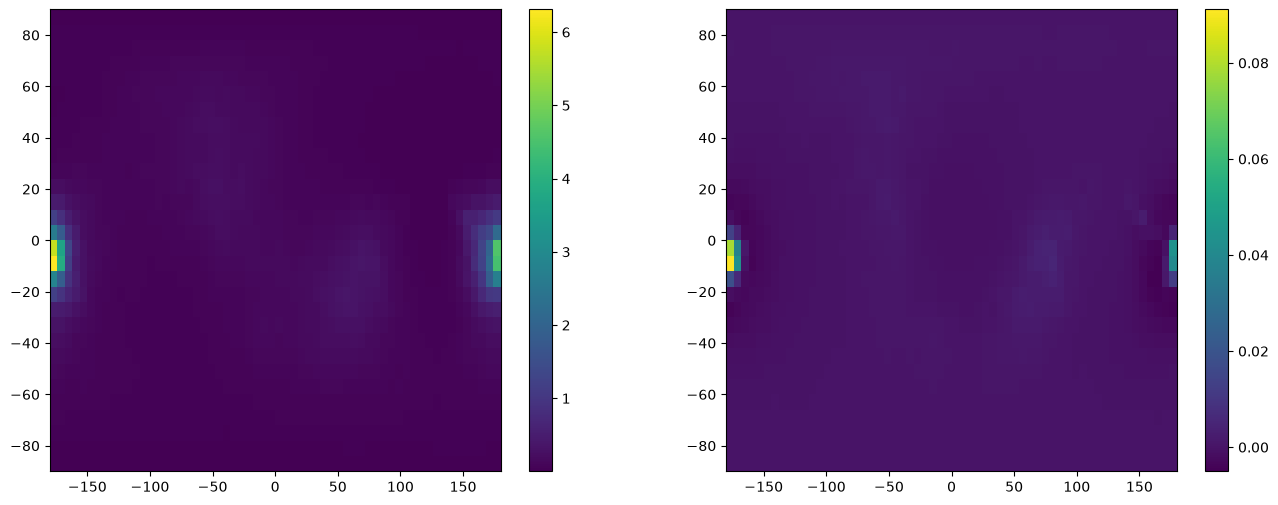

Convolving Delta image, iteration 77


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 77
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 77
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 78, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

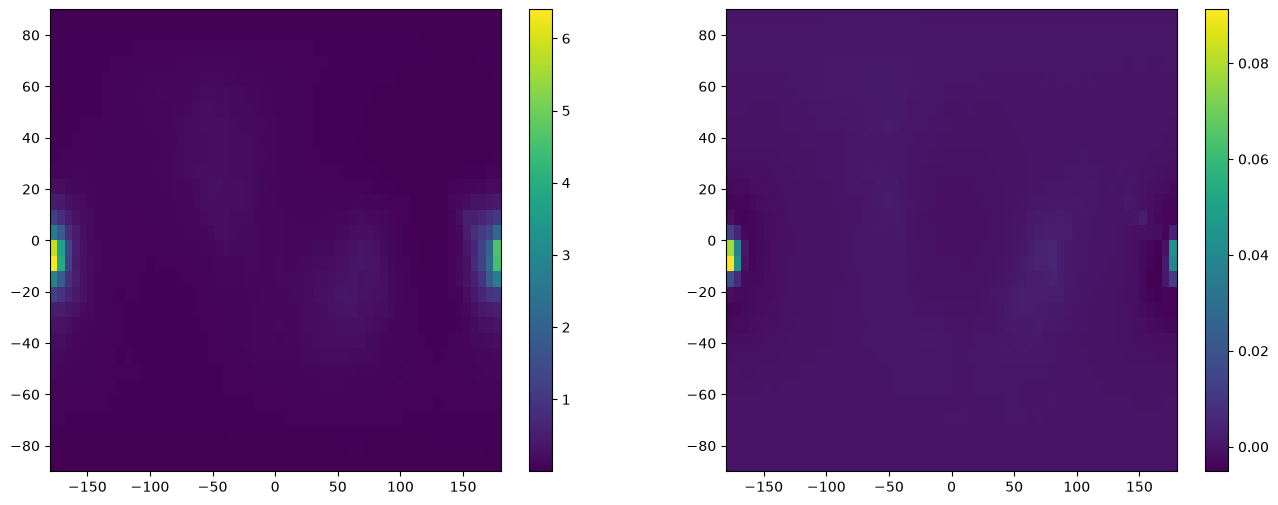

Convolving Delta image, iteration 78


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 78
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 78
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 79, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

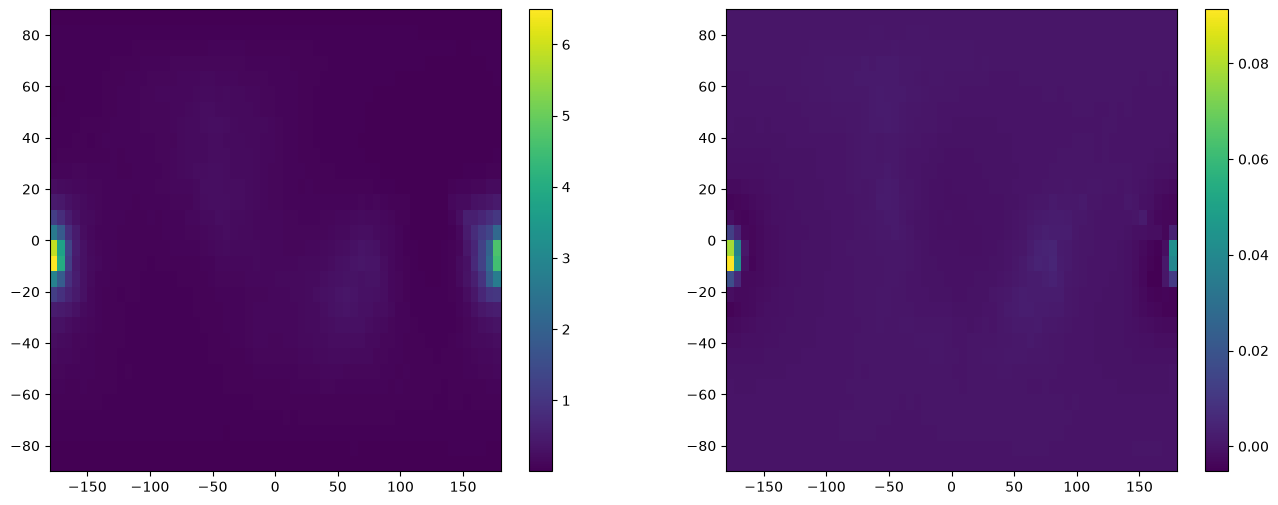

Convolving Delta image, iteration 79


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 79
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 79
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 80, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

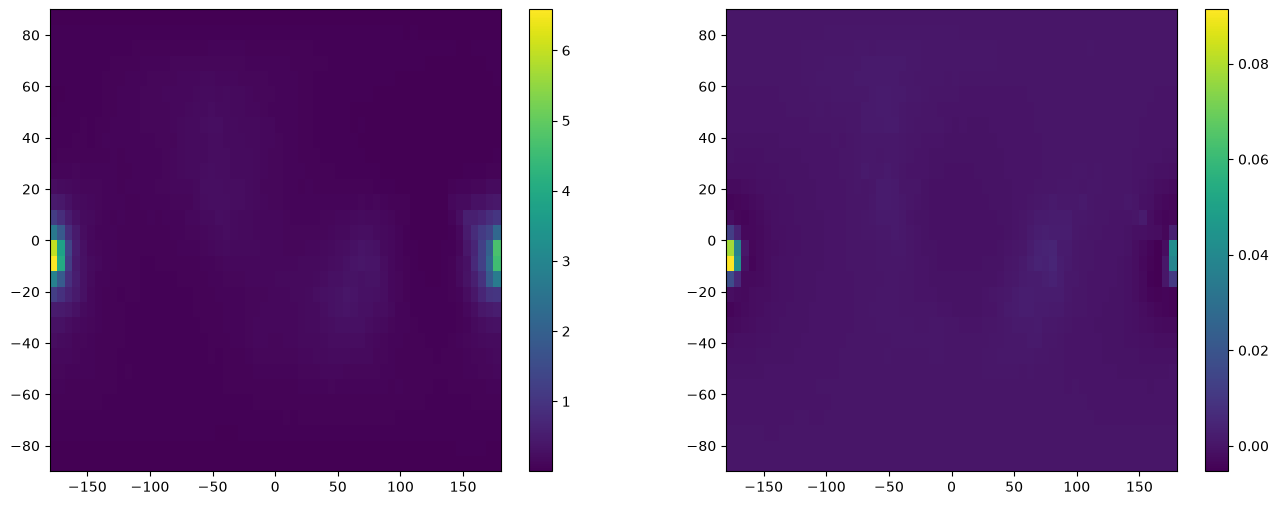

Convolving Delta image, iteration 80


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 80
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 80
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 81, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

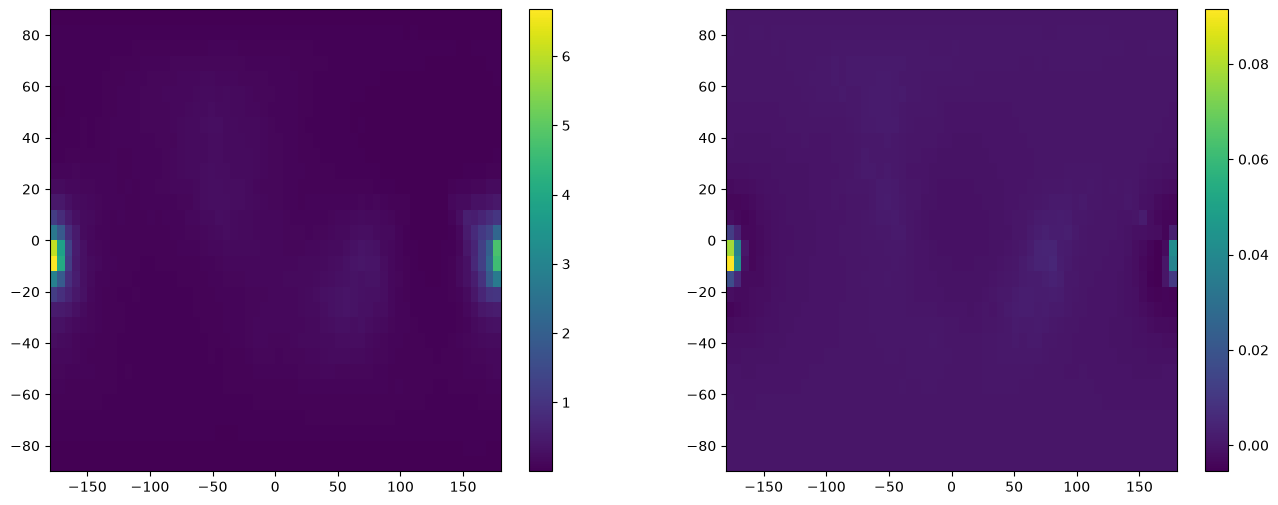

Convolving Delta image, iteration 81


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 81
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 81
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 82, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

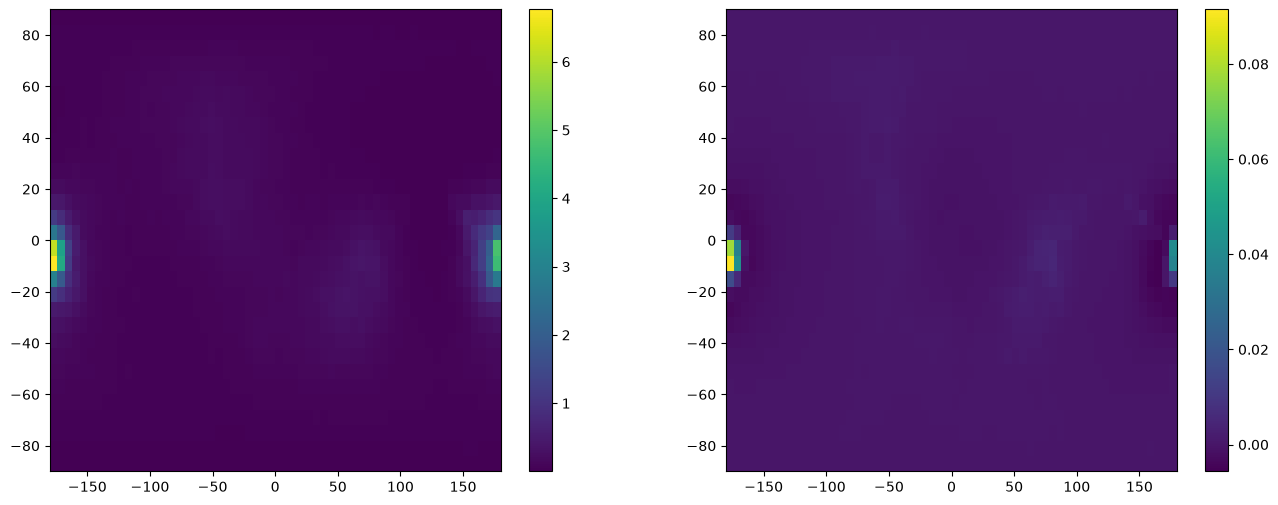

Convolving Delta image, iteration 82


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 82
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 82
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 83, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

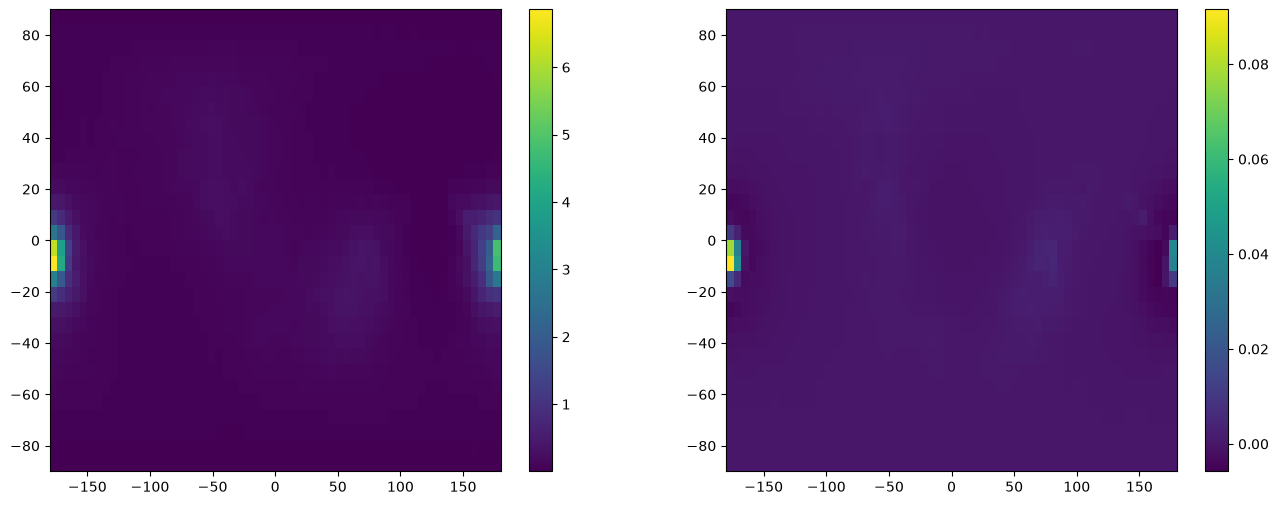

Convolving Delta image, iteration 83


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 83
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 83
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 84, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

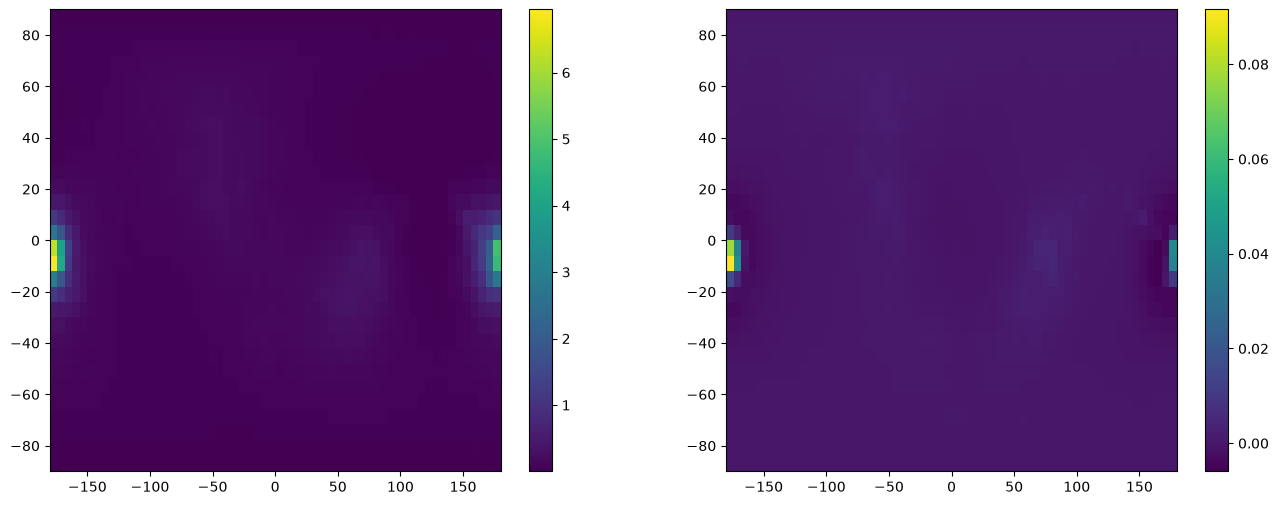

Convolving Delta image, iteration 84


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 84
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 84
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 85, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

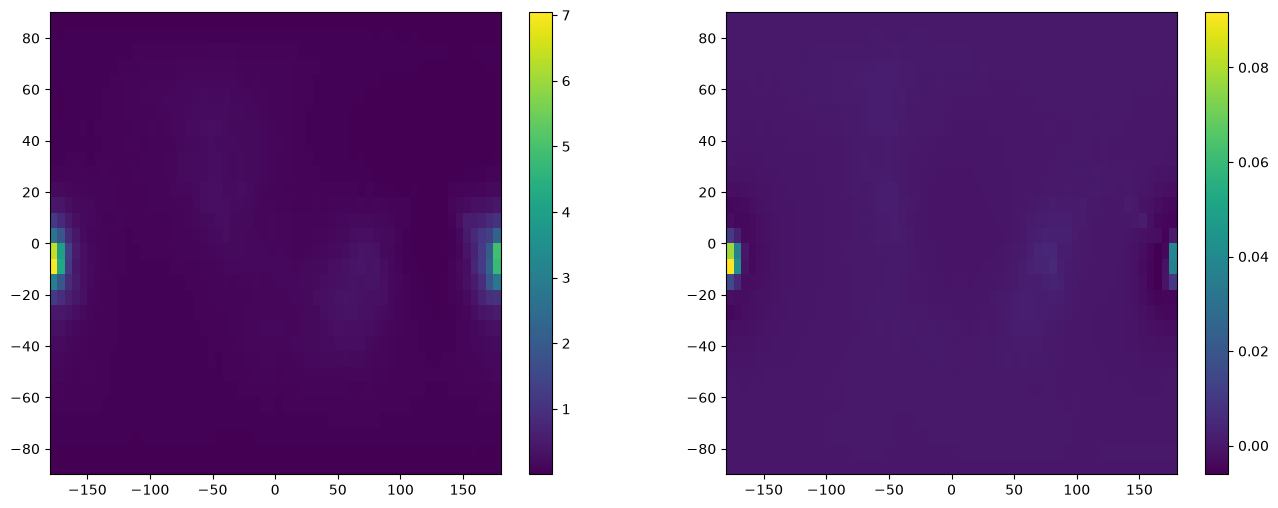

Convolving Delta image, iteration 85


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 85
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 85
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 86, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

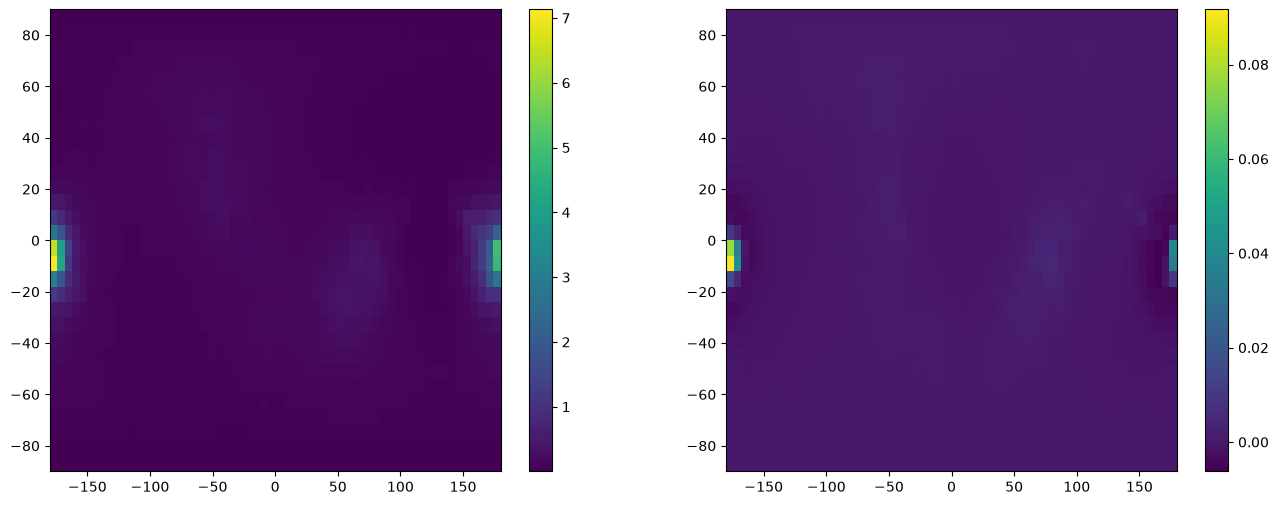

Convolving Delta image, iteration 86


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 86
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 86
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 87, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

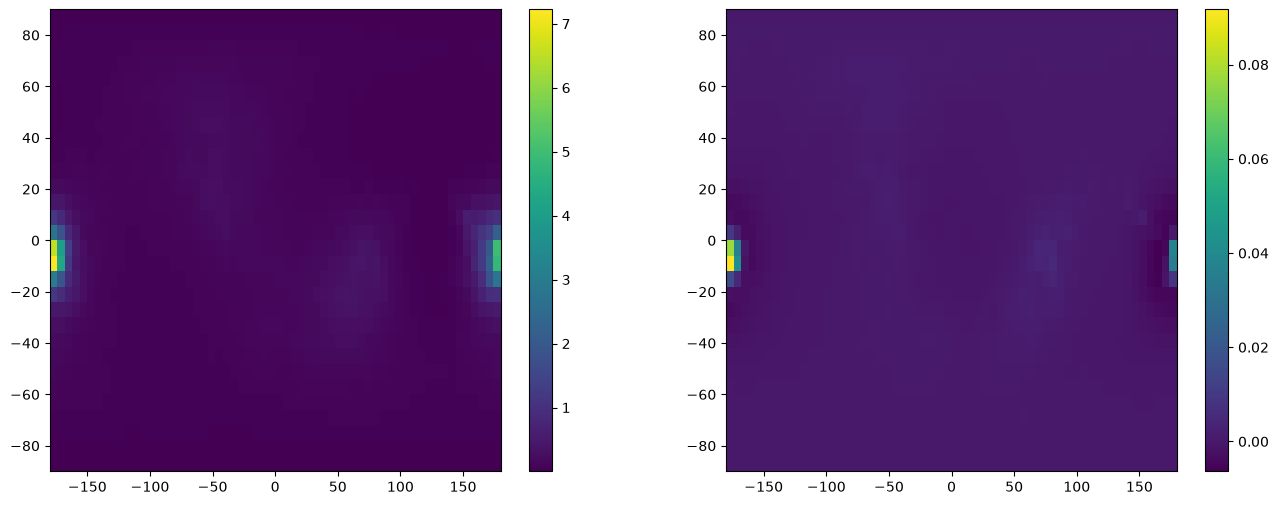

Convolving Delta image, iteration 87


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 87
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 87
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 88, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

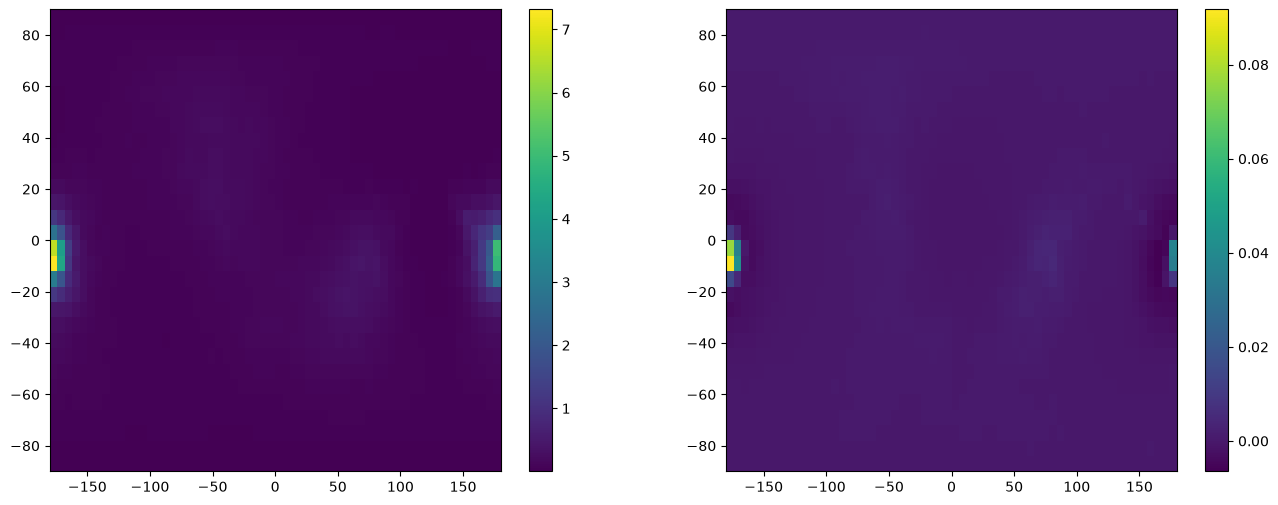

Convolving Delta image, iteration 88


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 88
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 88
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 89, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

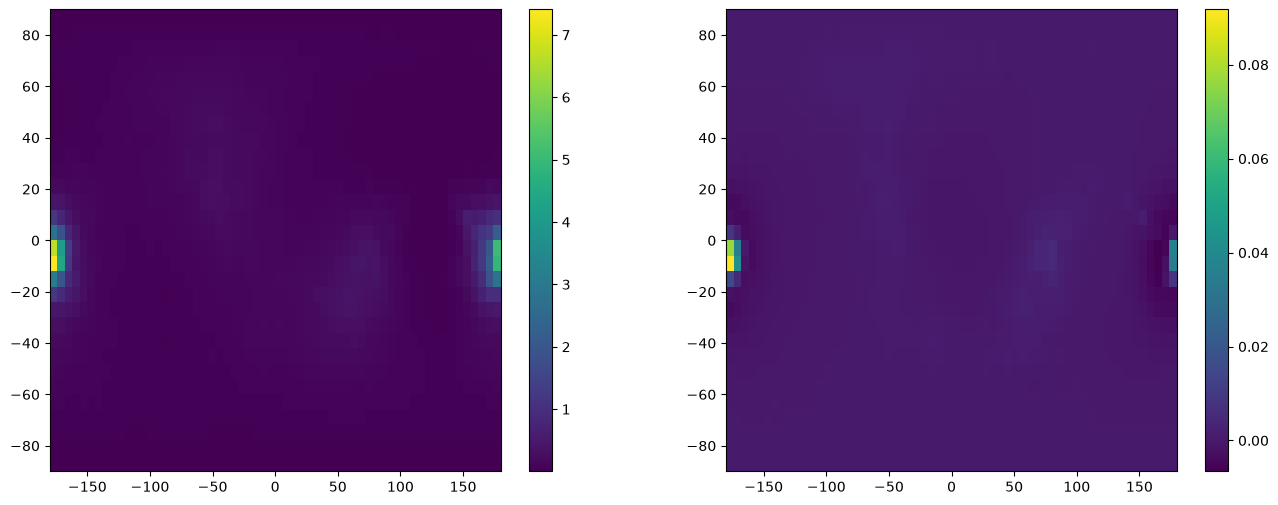

Convolving Delta image, iteration 89


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 89
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 89
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 90, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

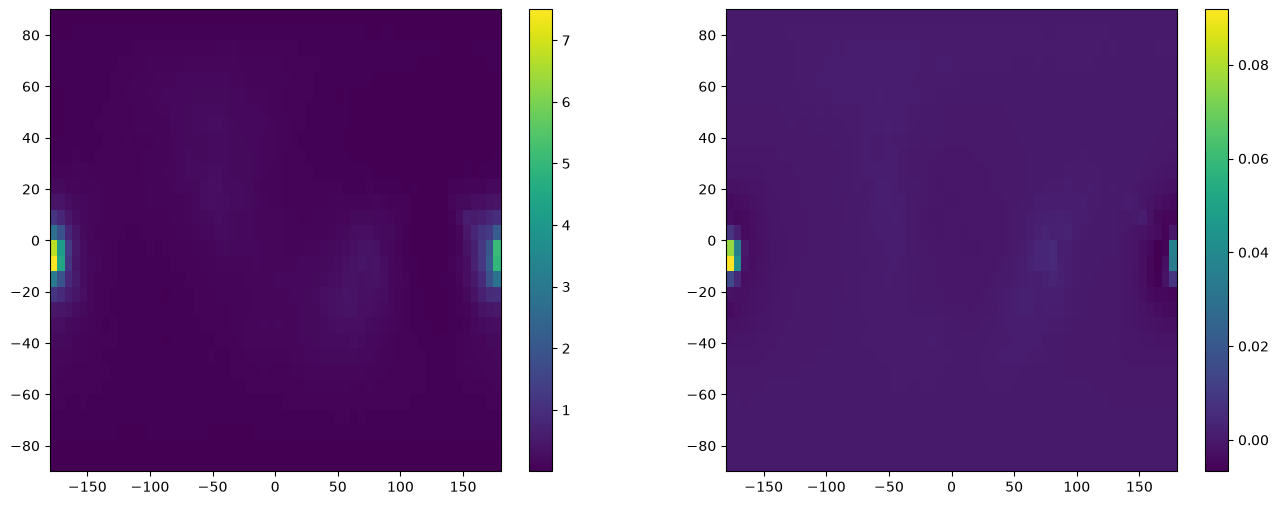

Convolving Delta image, iteration 90


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 90
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 90
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 91, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

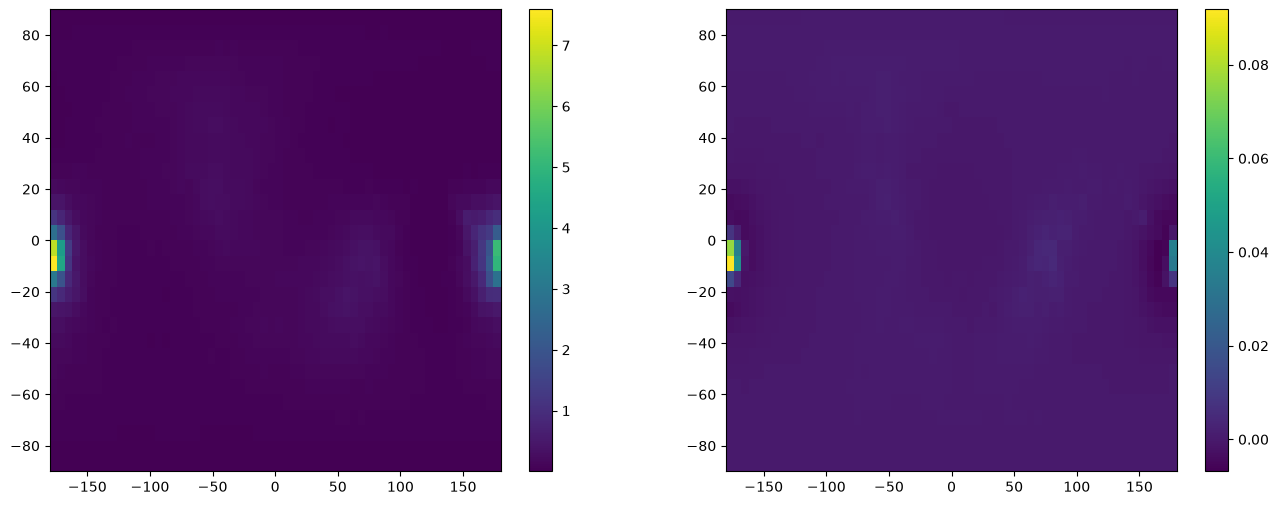

Convolving Delta image, iteration 91


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 91
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 91
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 92, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

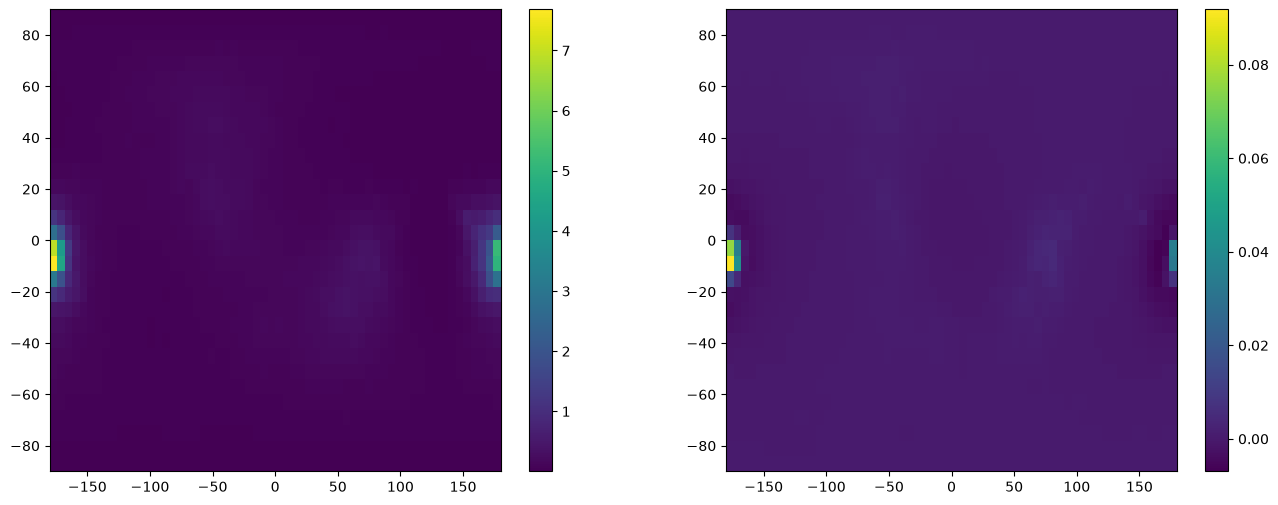

Convolving Delta image, iteration 92


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 92
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 92
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 93, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

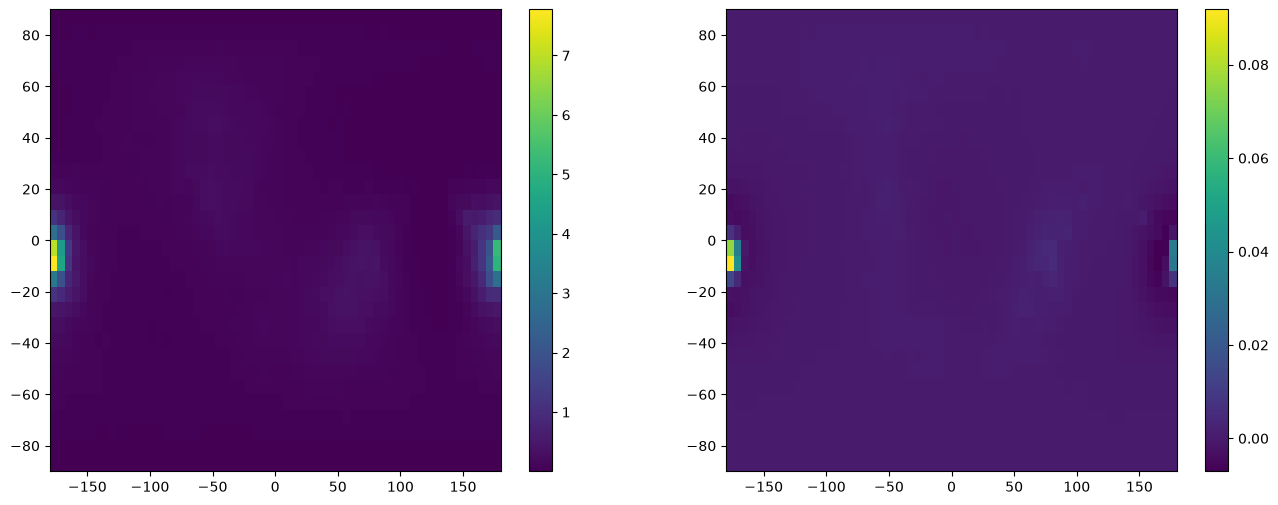

Convolving Delta image, iteration 93


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 93
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 93
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 94, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

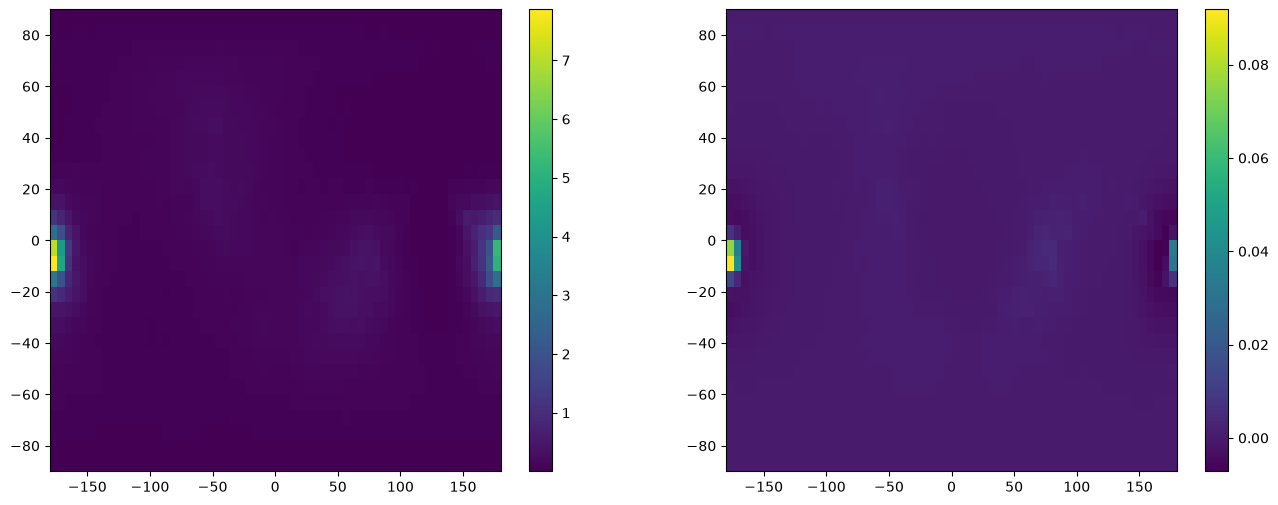

Convolving Delta image, iteration 94


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 94
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 94
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 95, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

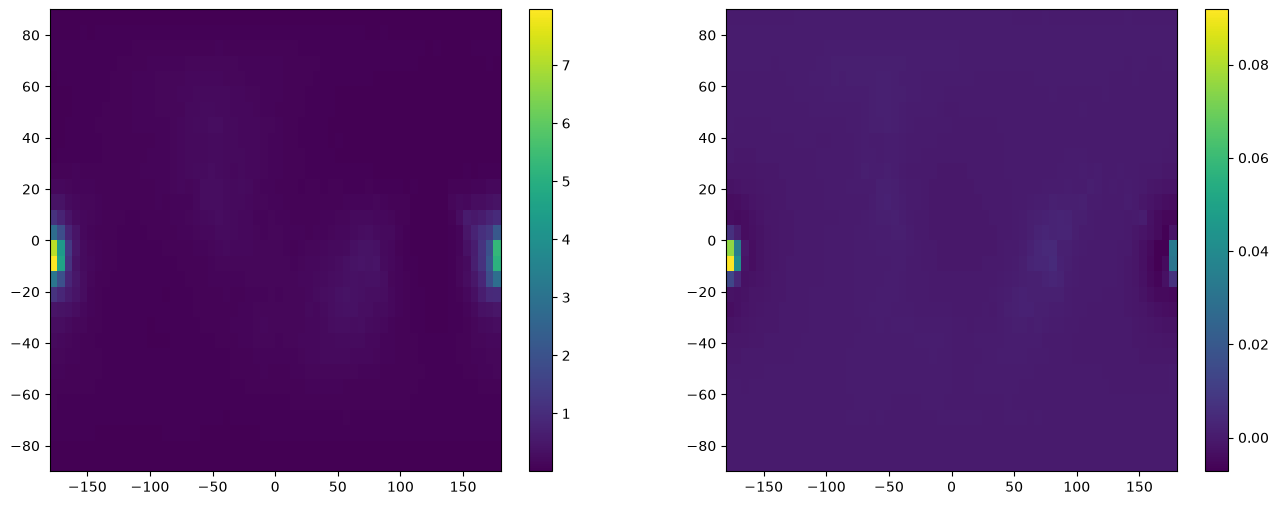

Convolving Delta image, iteration 95


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 95
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 95
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 96, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

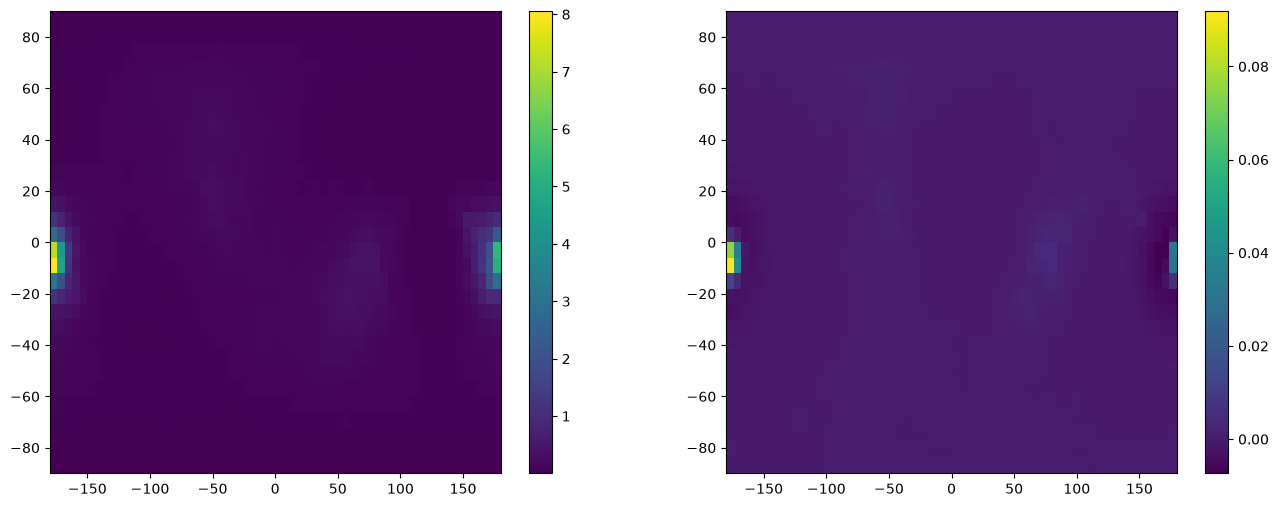

Convolving Delta image, iteration 96


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 96
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 96
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 97, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

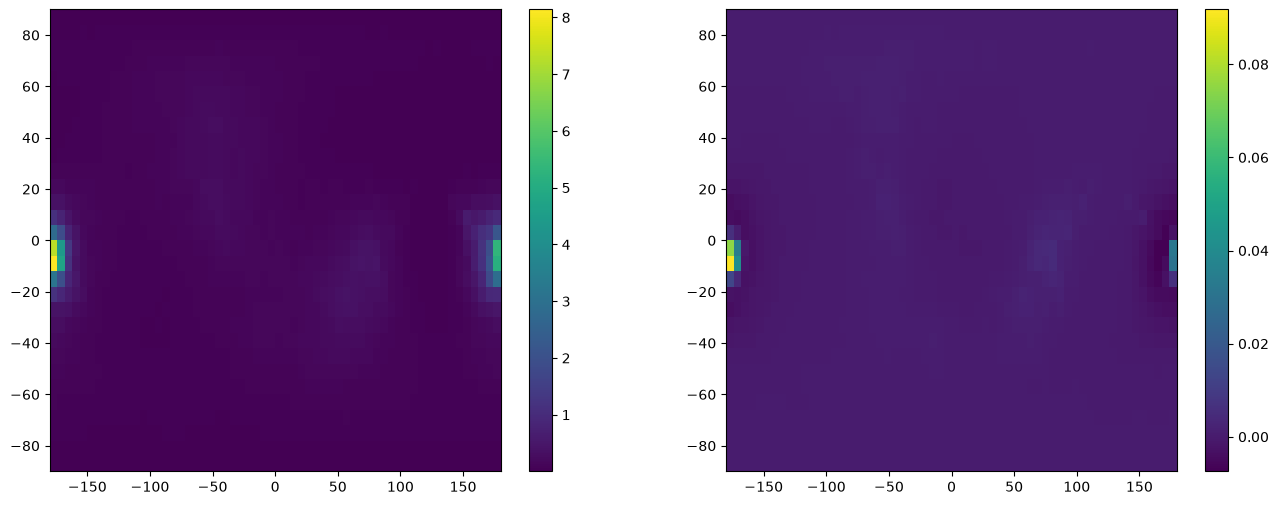

Convolving Delta image, iteration 97


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 97
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 97
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 98, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

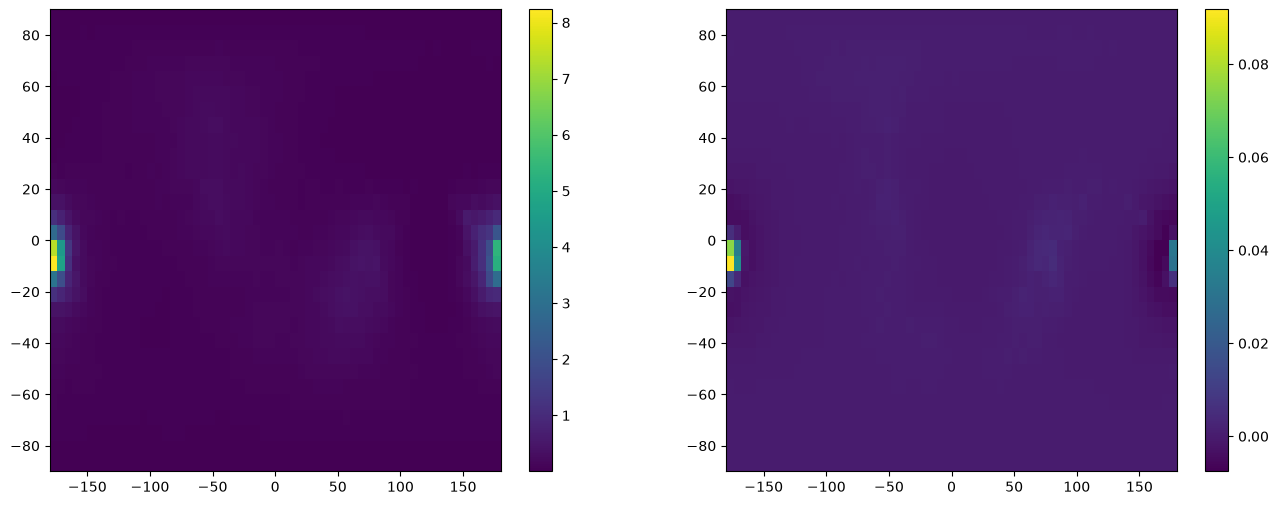

Convolving Delta image, iteration 98


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 98
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 98
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 99, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

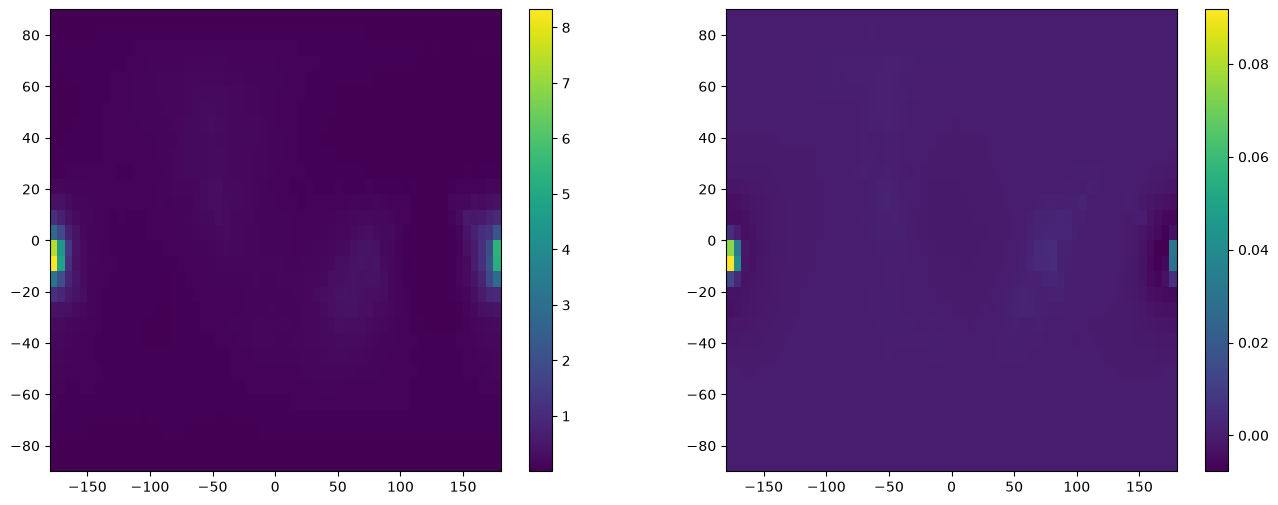

Convolving Delta image, iteration 99


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 99
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 99
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 100, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

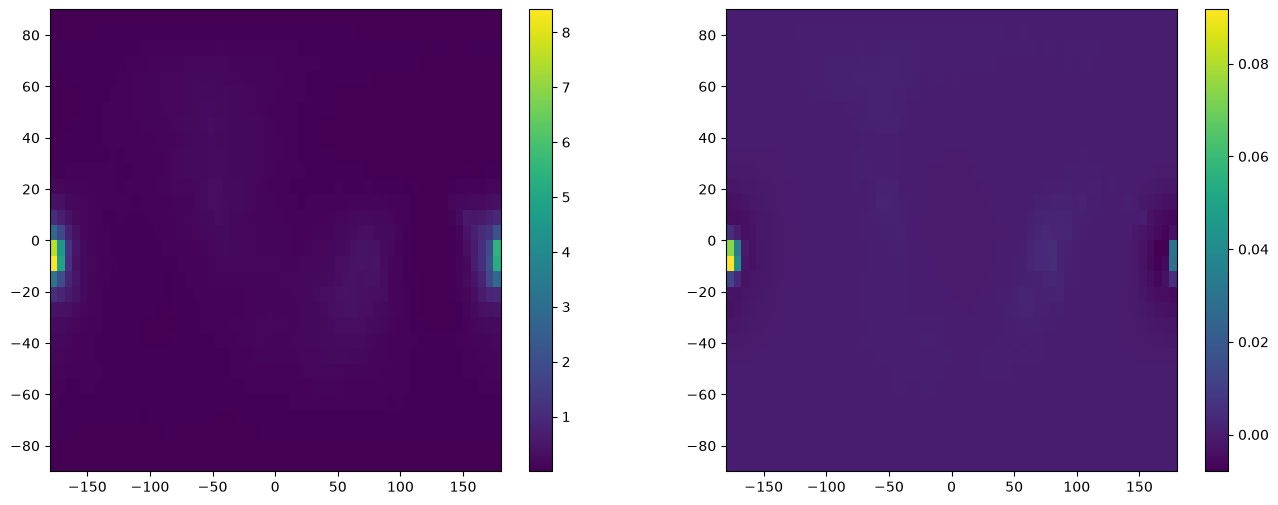

Convolving Delta image, iteration 100


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 100
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 100
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 101, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

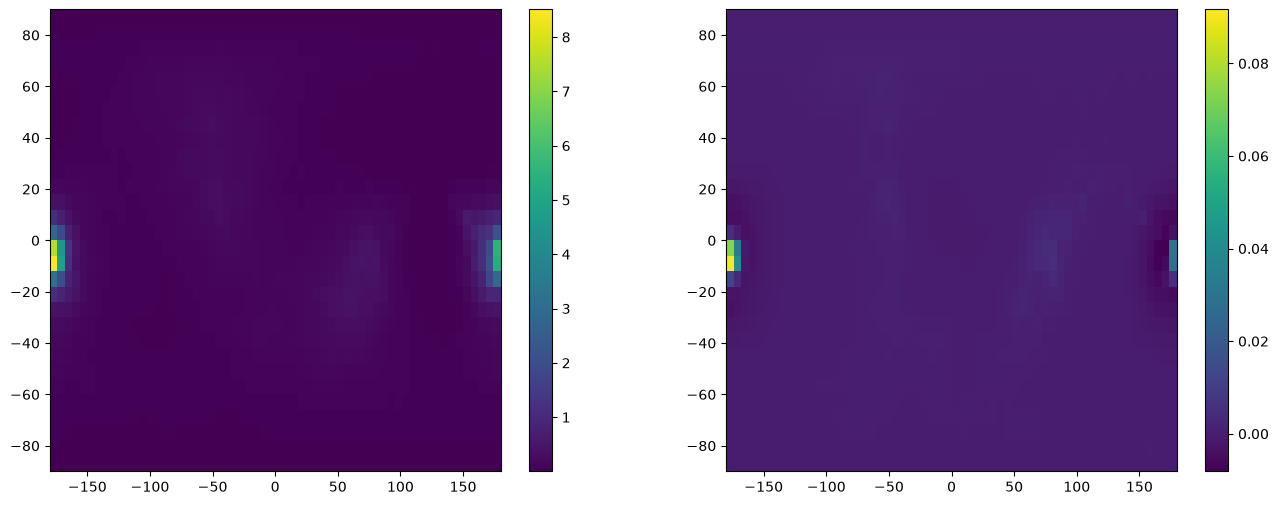

Convolving Delta image, iteration 101


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 101
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 101
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 102, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

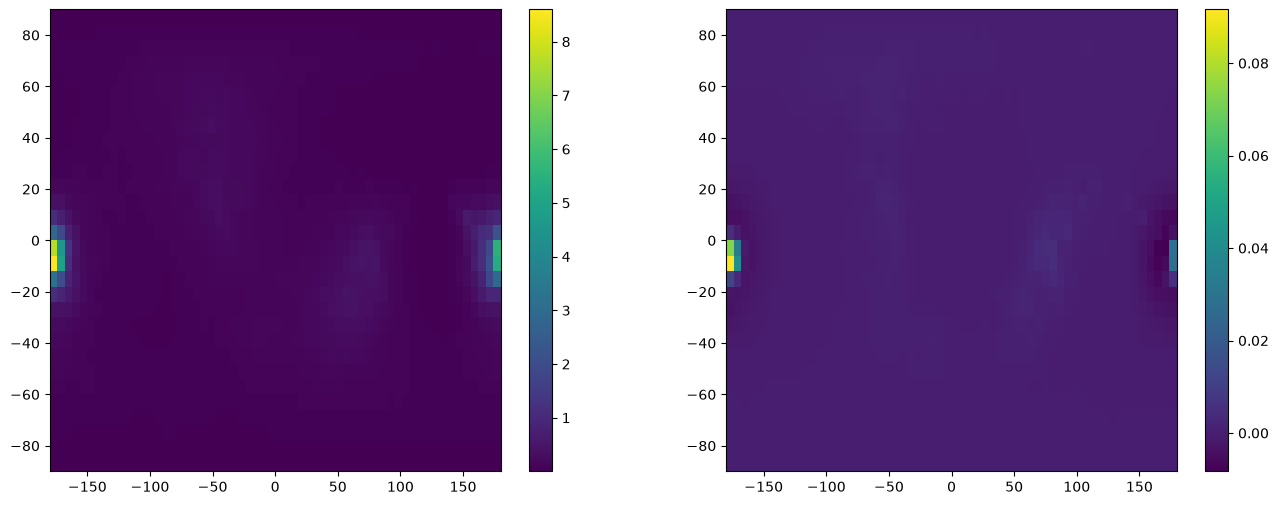

Convolving Delta image, iteration 102


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 102
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 102
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 103, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

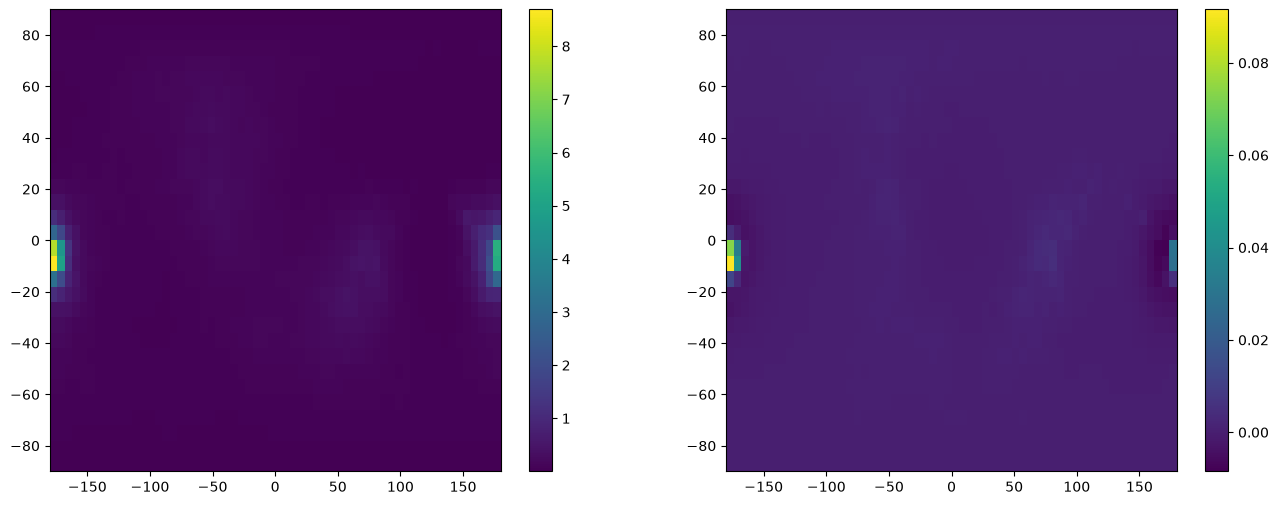

Convolving Delta image, iteration 103


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 103
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 103
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 104, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

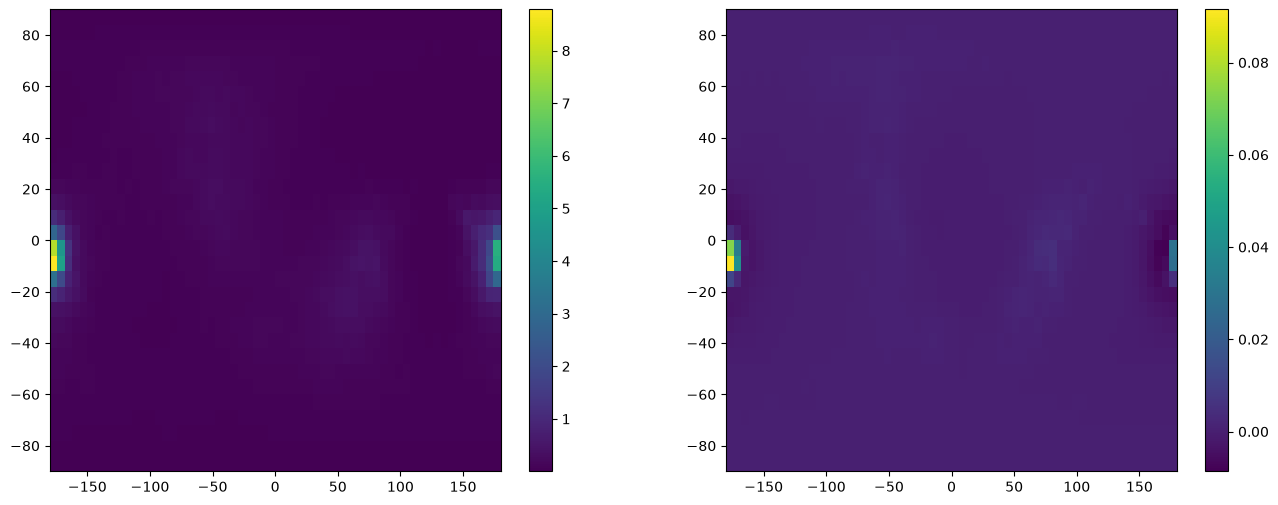

Convolving Delta image, iteration 104


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 104
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 104
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 105, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

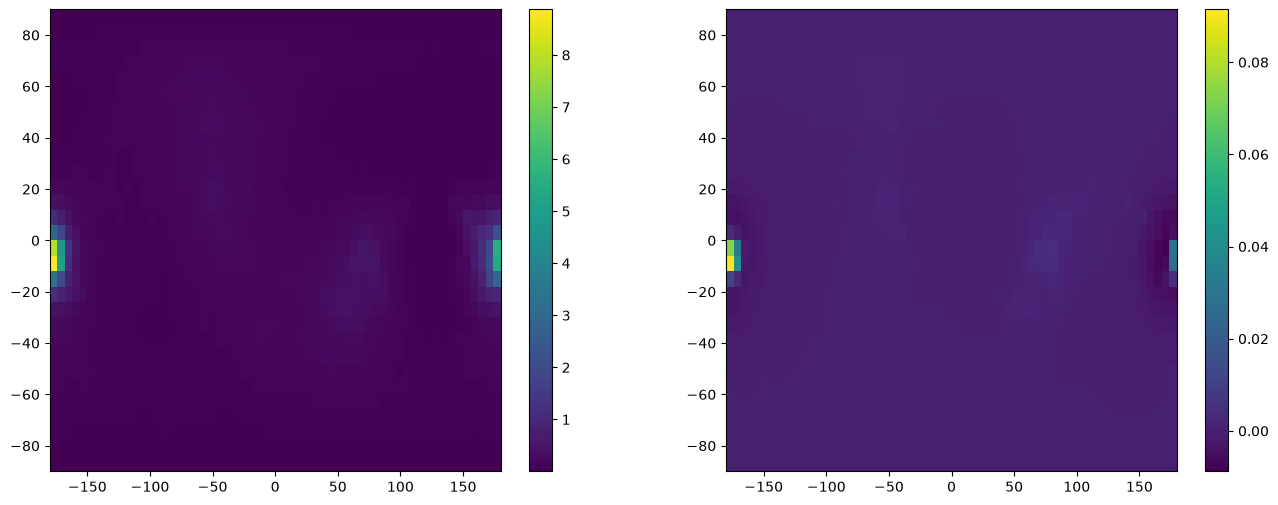

Convolving Delta image, iteration 105


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 105
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 105
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 106, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

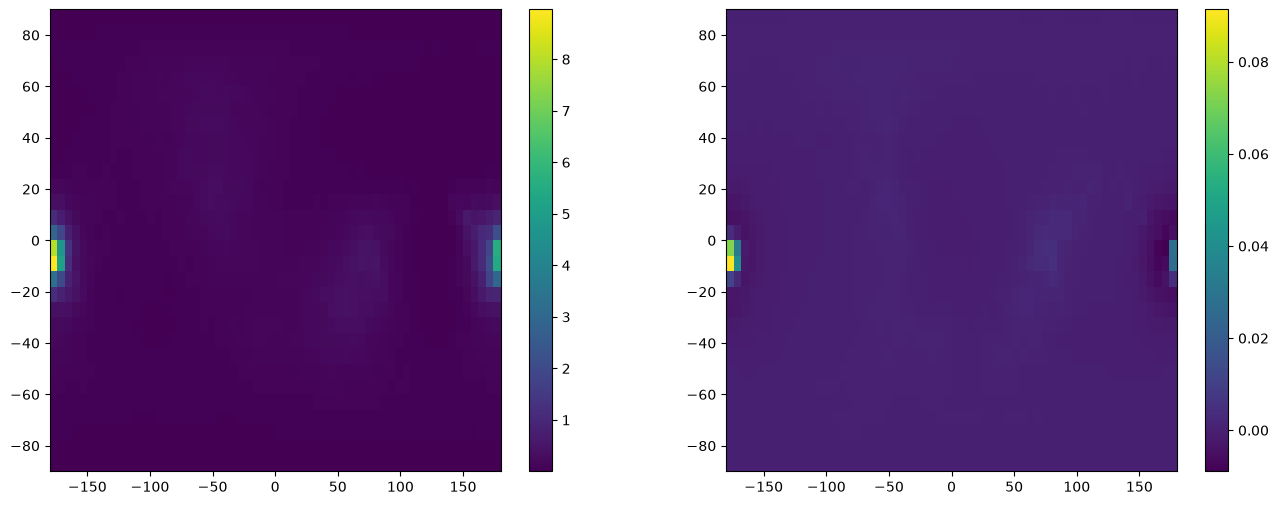

Convolving Delta image, iteration 106


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 106
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 106
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 107, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

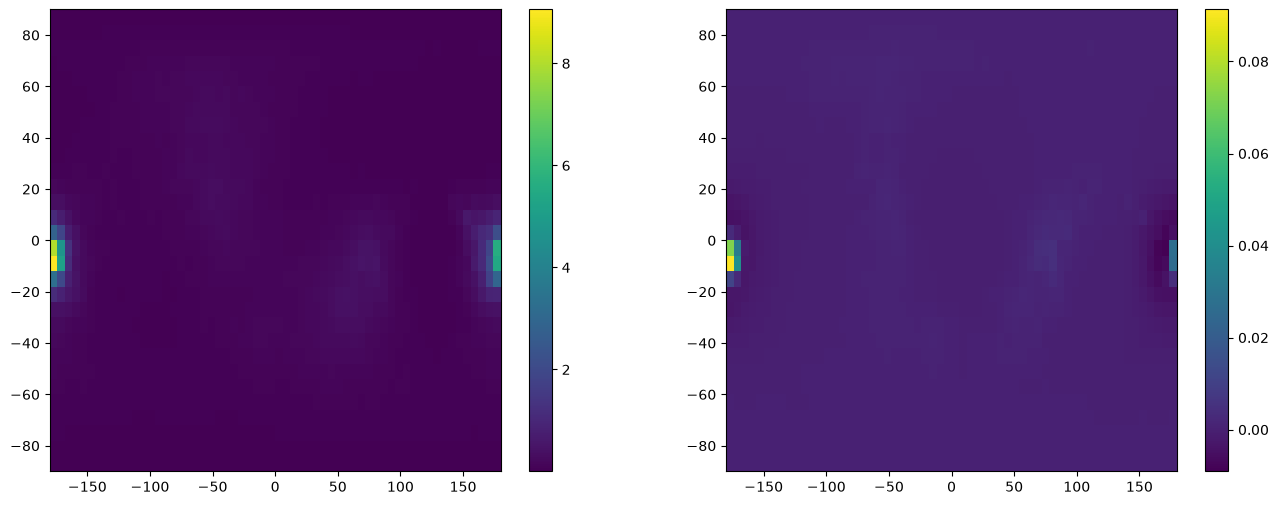

Convolving Delta image, iteration 107


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 107
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 107
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 108, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

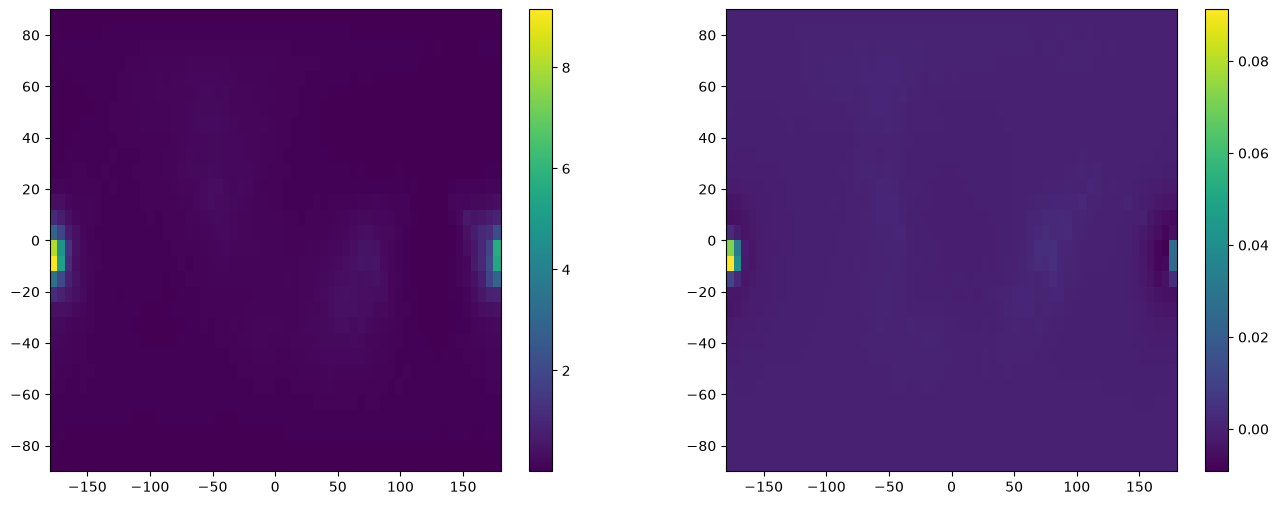

Convolving Delta image, iteration 108


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 108
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 108
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 109, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

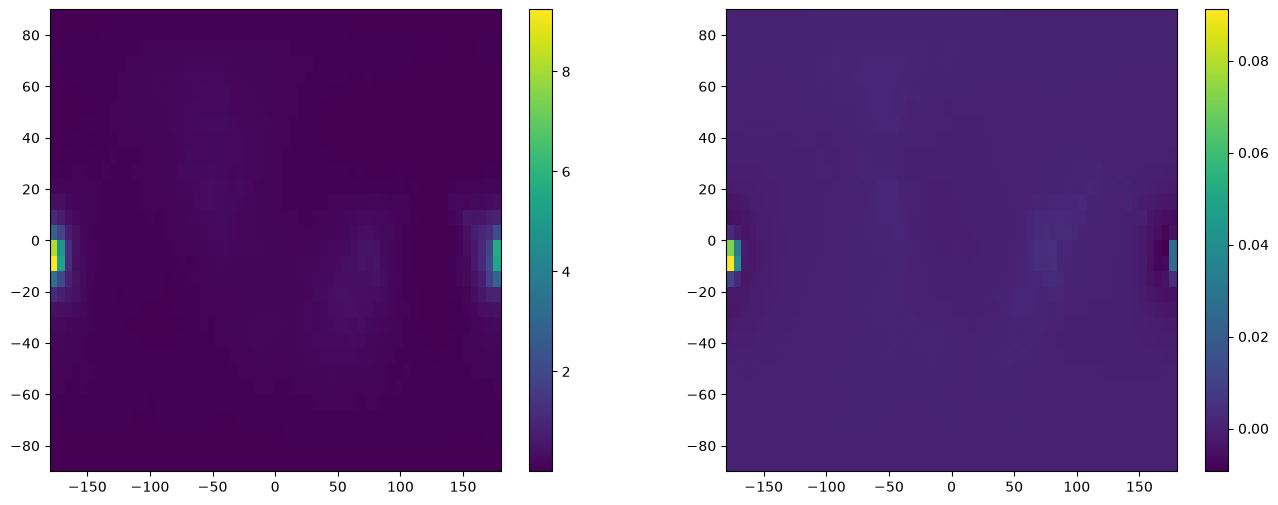

Convolving Delta image, iteration 109


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 109
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 109
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 110, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

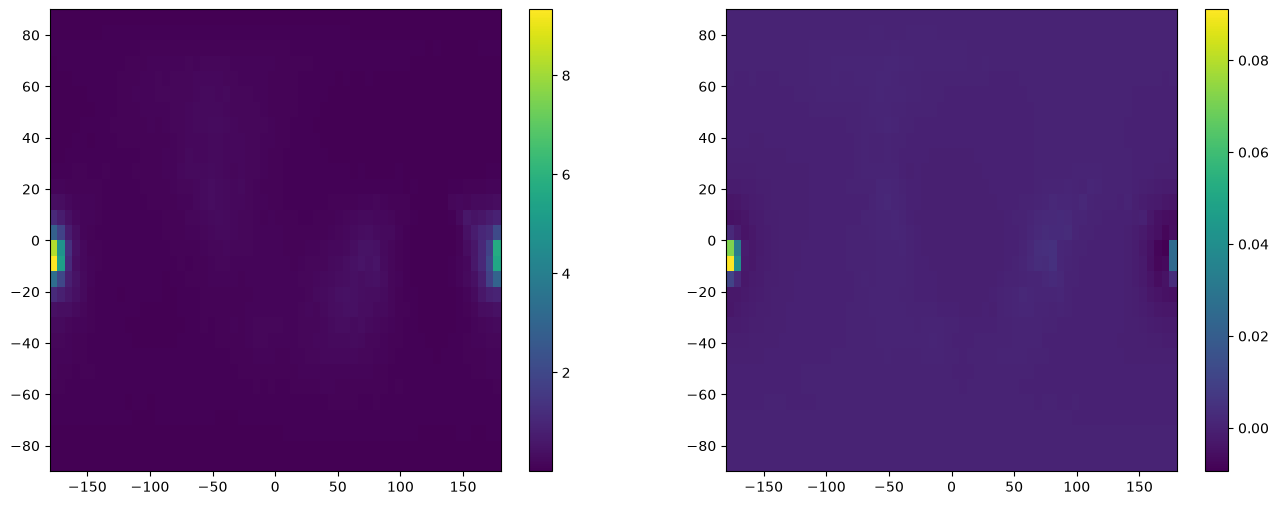

Convolving Delta image, iteration 110


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 110
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 110
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 111, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

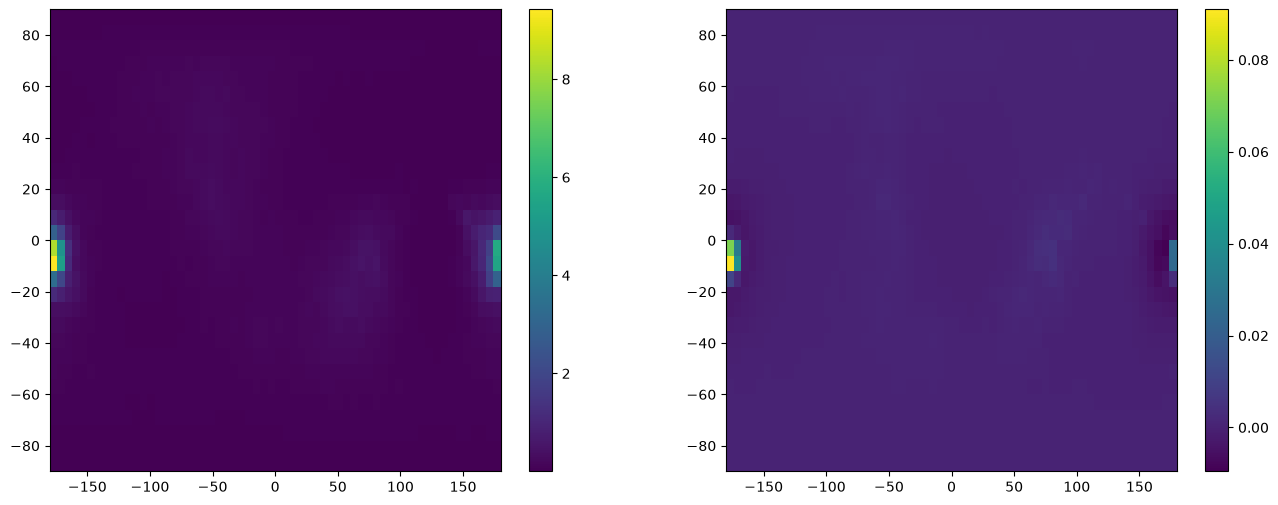

Convolving Delta image, iteration 111


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 111
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 111
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 112, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

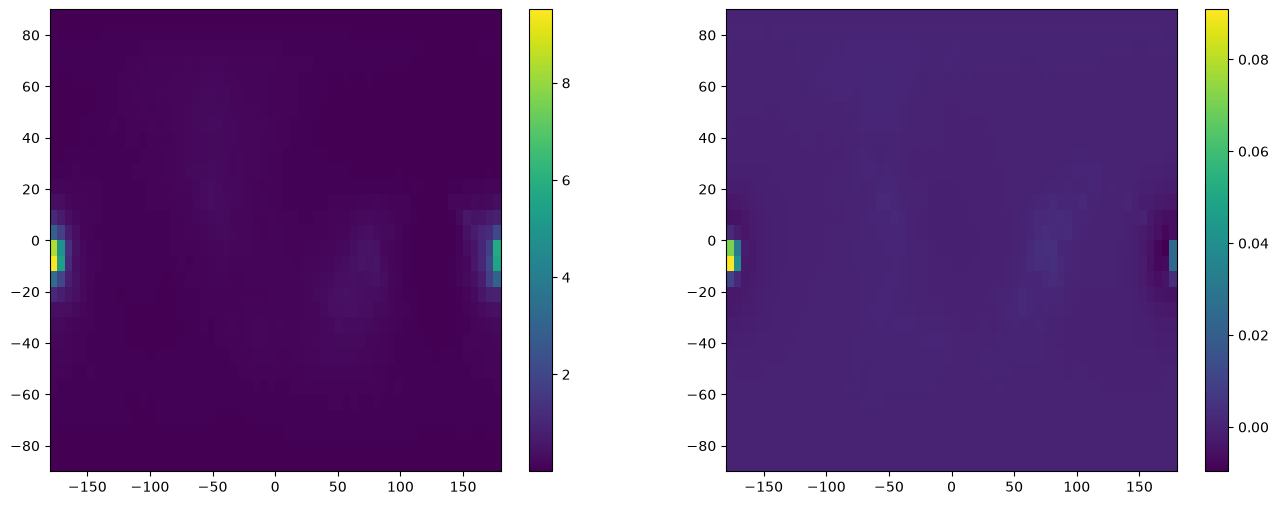

Convolving Delta image, iteration 112


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 112
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 112
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 113, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

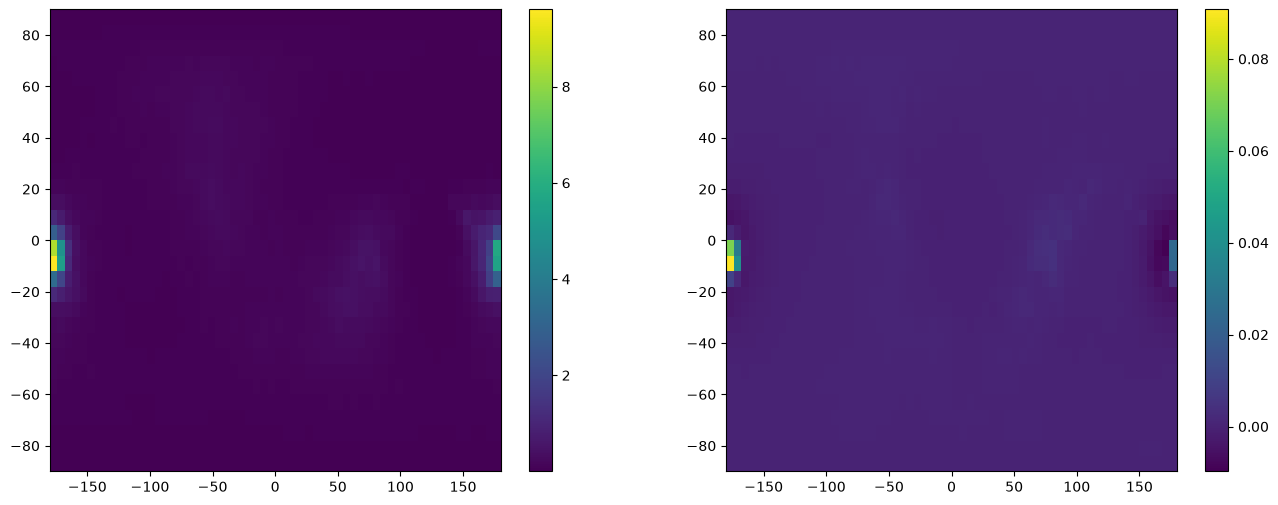

Convolving Delta image, iteration 113


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 113
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 113
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 114, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

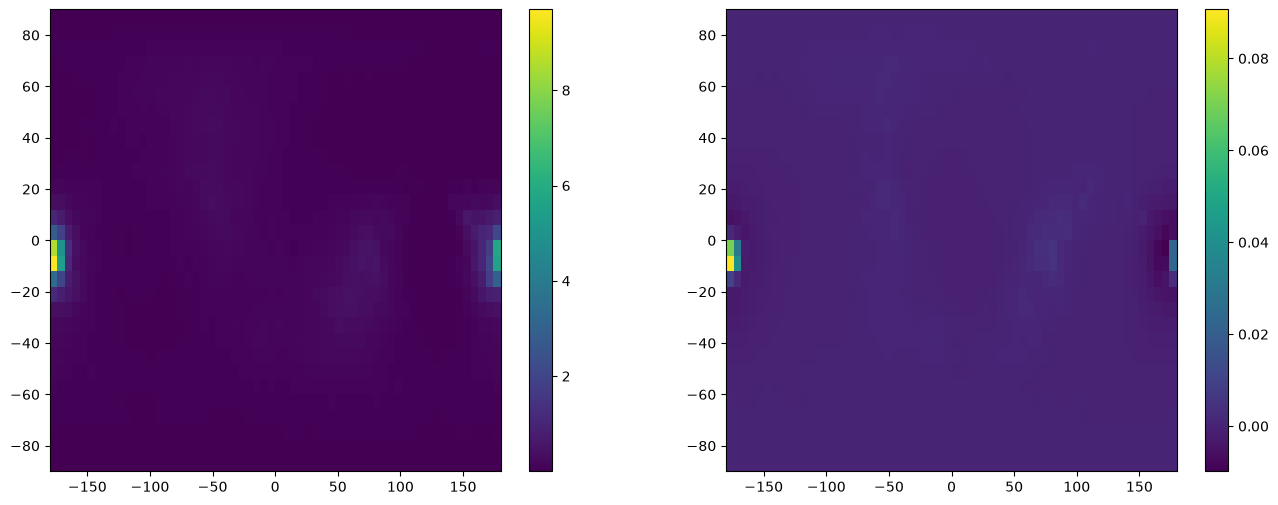

Convolving Delta image, iteration 114


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 114
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 114
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 115, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

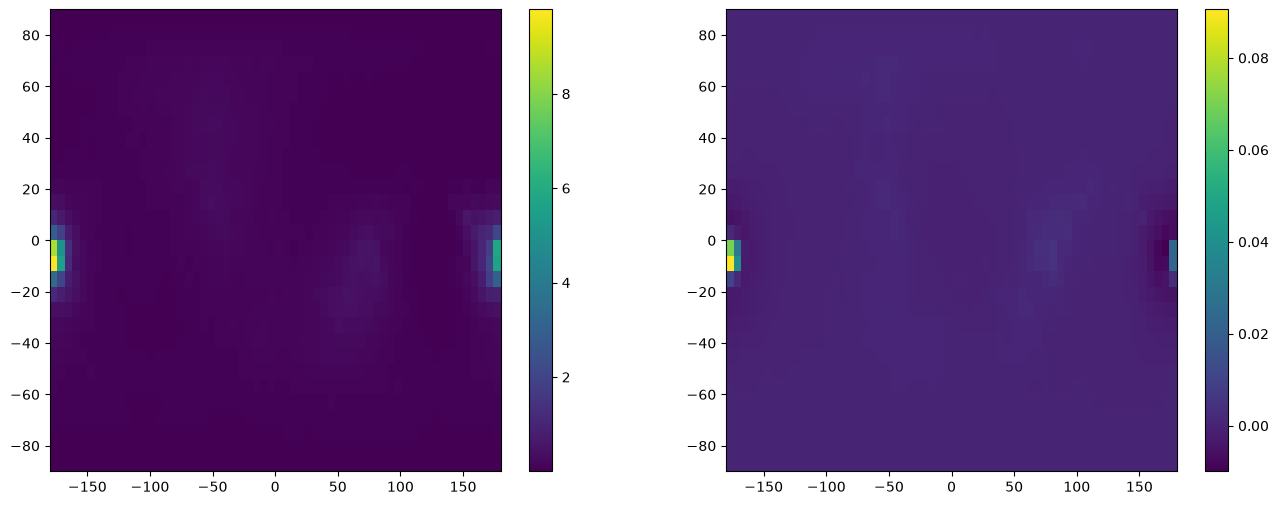

Convolving Delta image, iteration 115


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 115
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 115
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 116, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

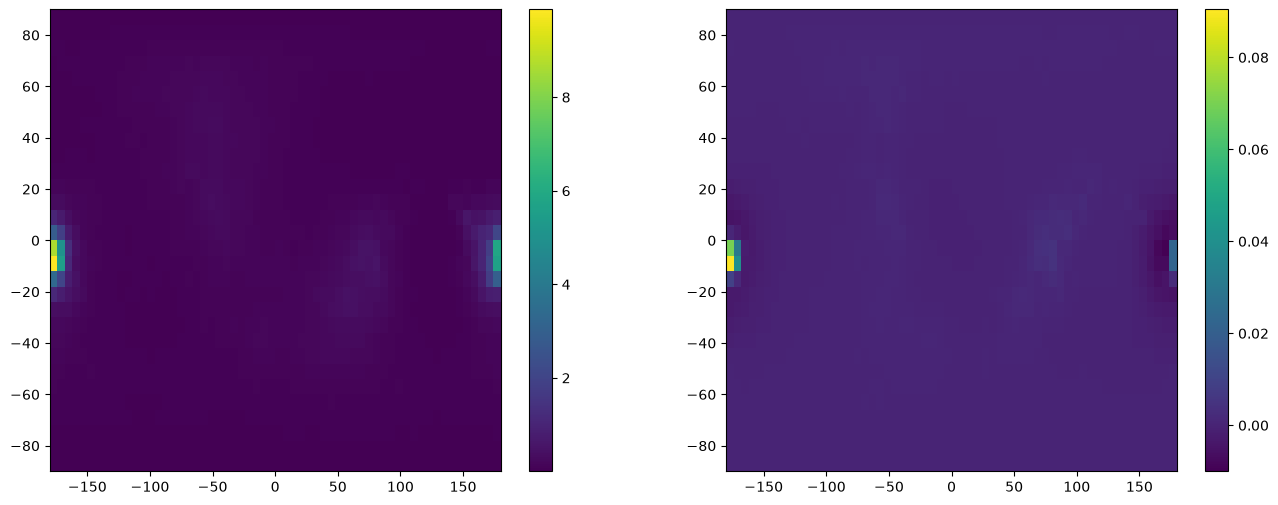

Convolving Delta image, iteration 116


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 116
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 116
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 117, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

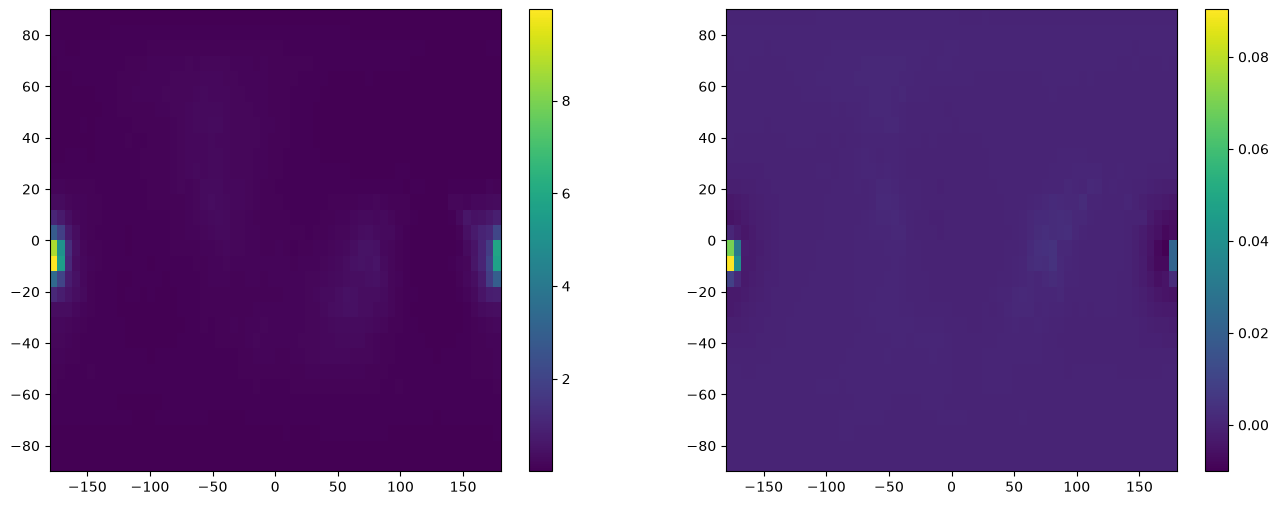

Convolving Delta image, iteration 117


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 117
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 117
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 118, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

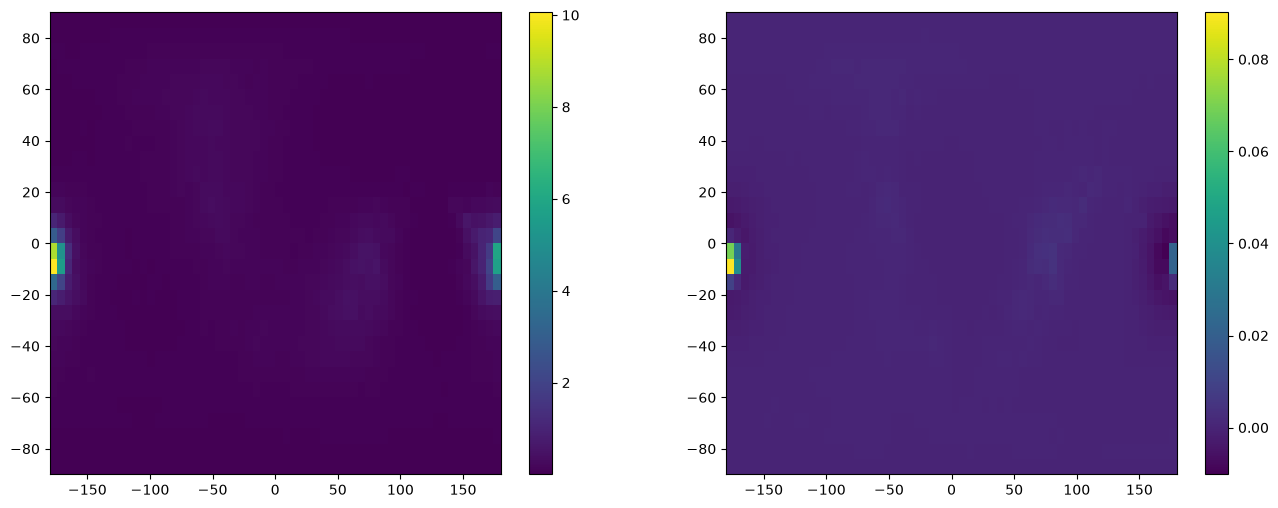

Convolving Delta image, iteration 118


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 118
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 118
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 119, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

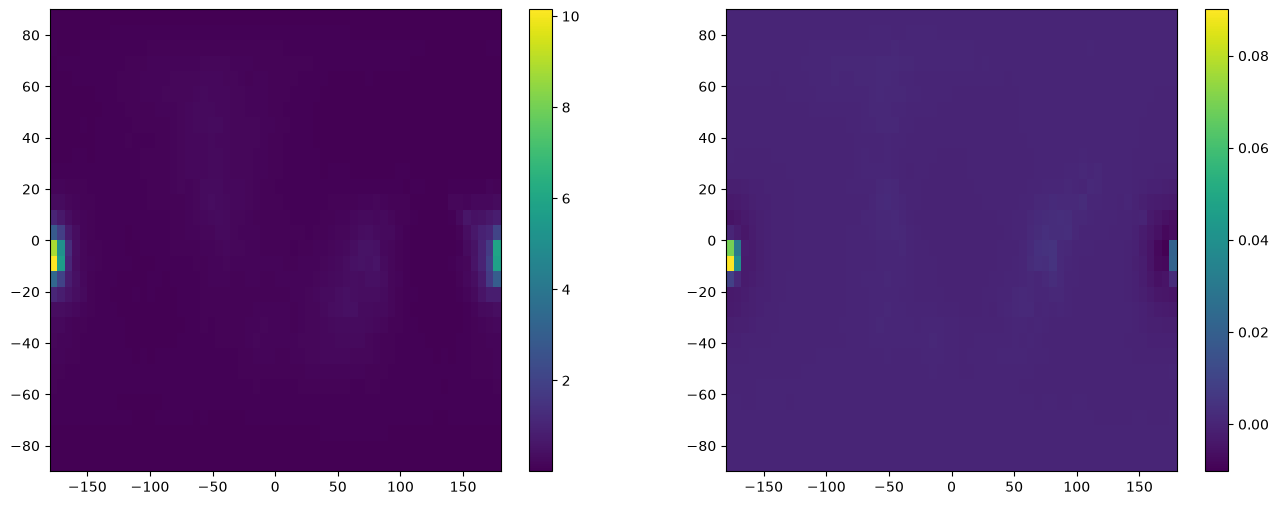

Convolving Delta image, iteration 119


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 119
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 119
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 120, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

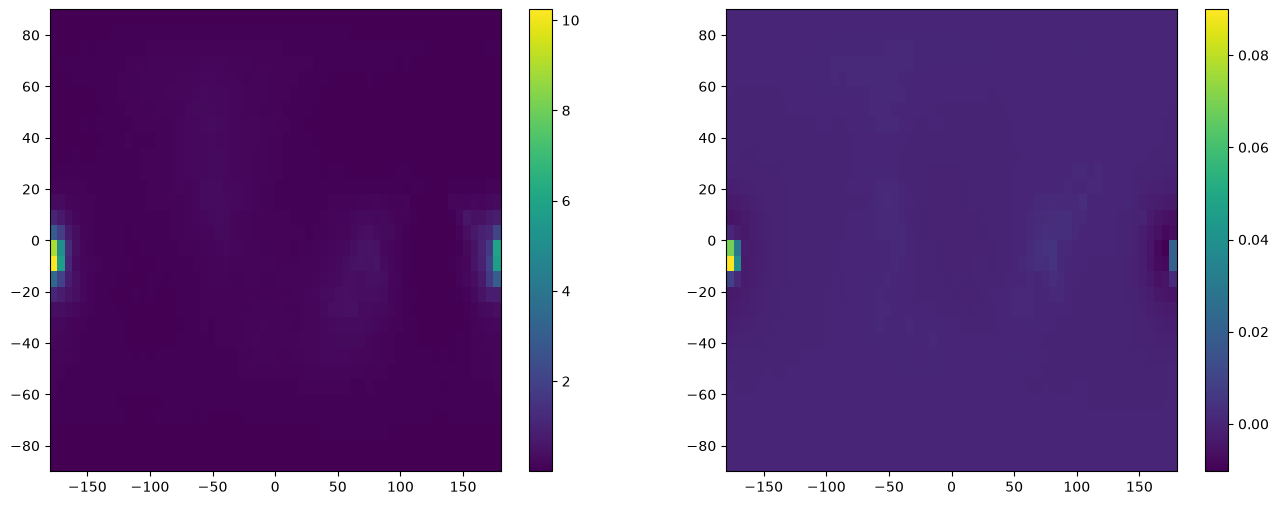

Convolving Delta image, iteration 120


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 120
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 120
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 121, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

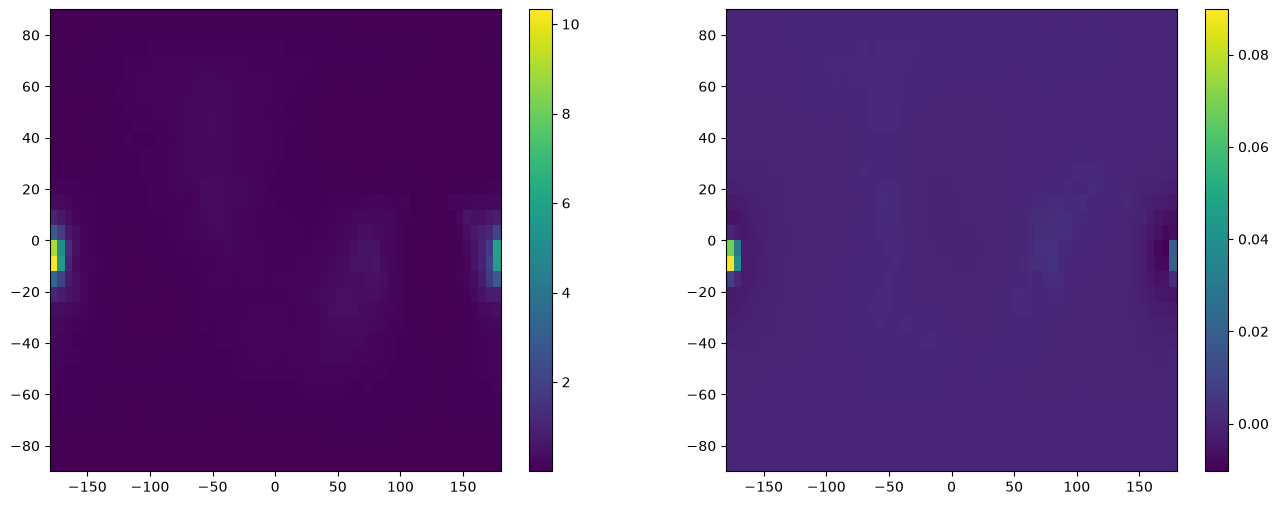

Convolving Delta image, iteration 121


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 121
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 121
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 122, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

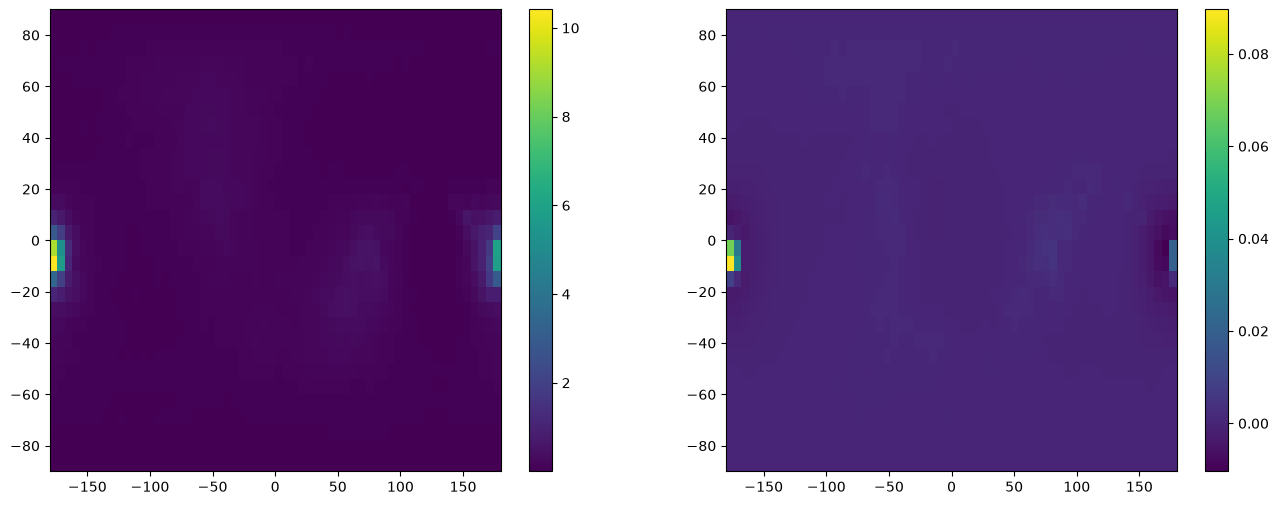

Convolving Delta image, iteration 122


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 122
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 122
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 123, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

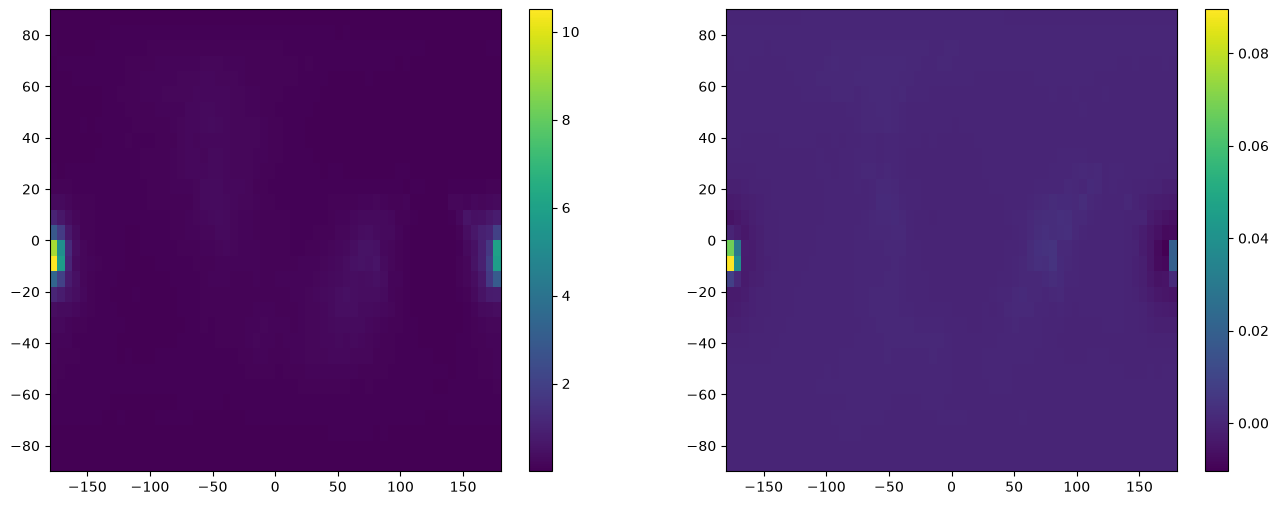

Convolving Delta image, iteration 123


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 123
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 123
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 124, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

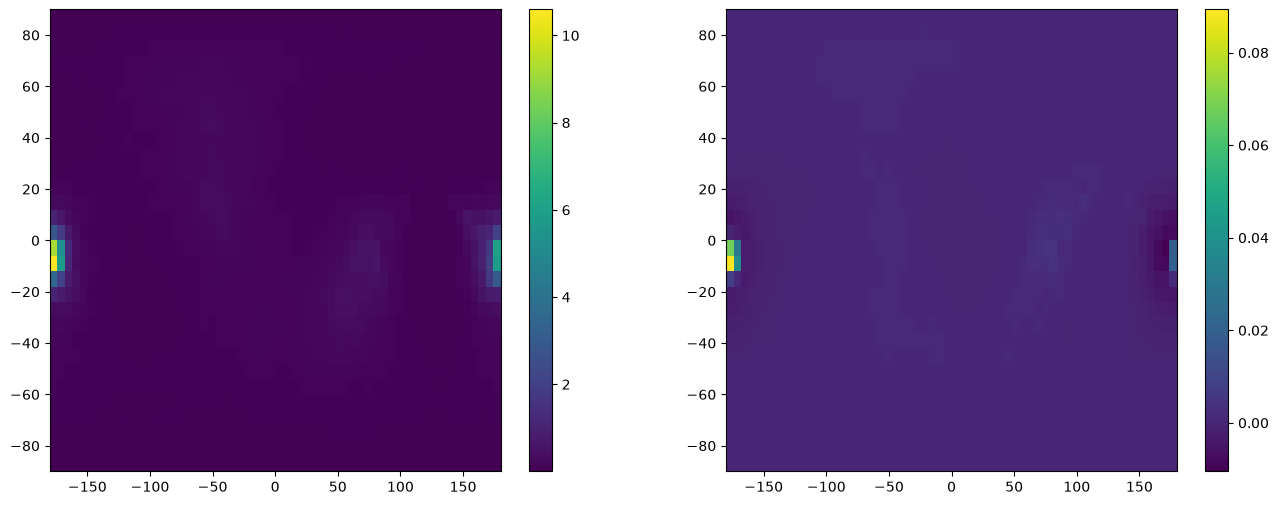

Convolving Delta image, iteration 124


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 124
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 124
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 125, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

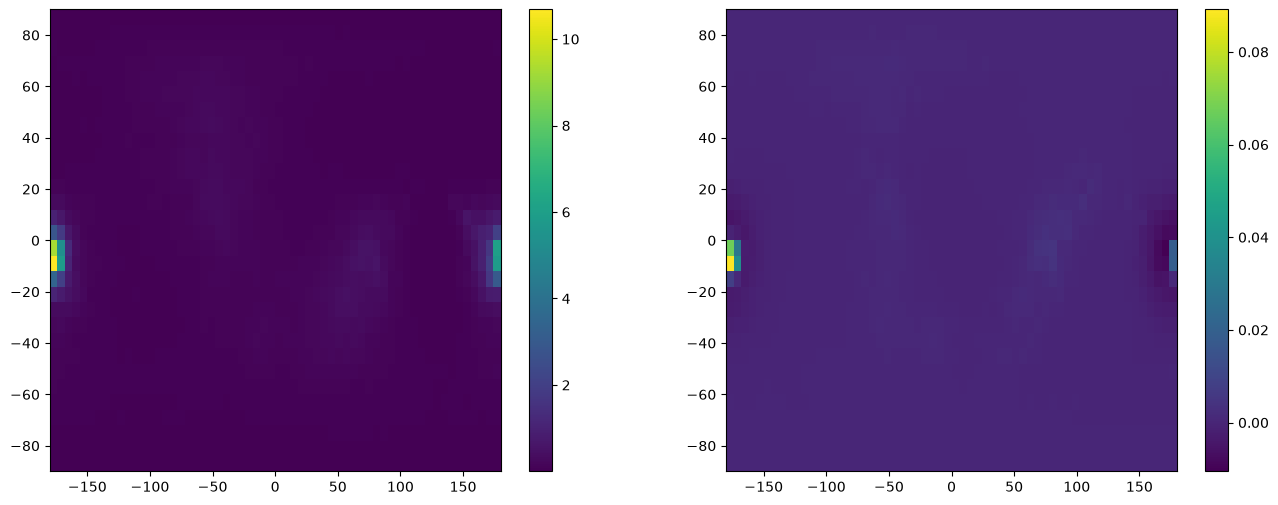

Convolving Delta image, iteration 125


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 125
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 125
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 126, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

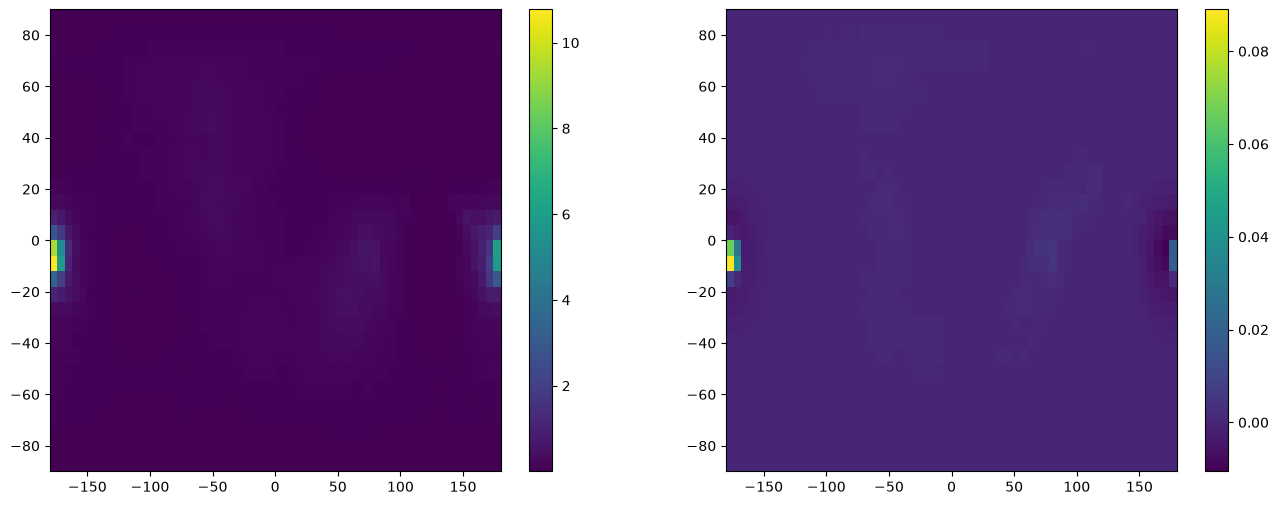

Convolving Delta image, iteration 126


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 126
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 126
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 127, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

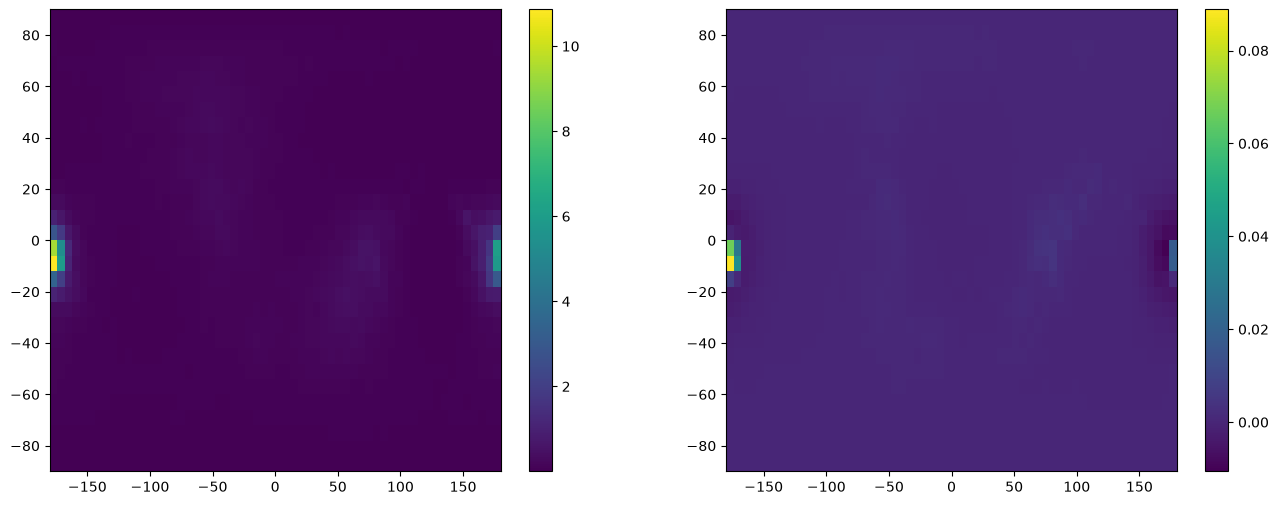

Convolving Delta image, iteration 127


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 127
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 127
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 128, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

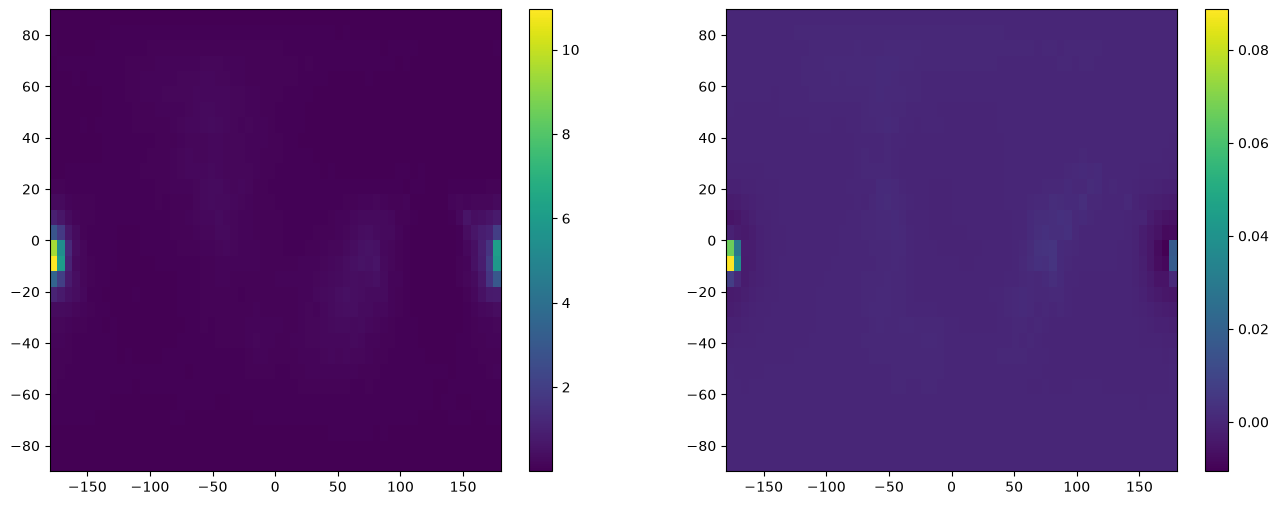

Convolving Delta image, iteration 128


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 128
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 128
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 129, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

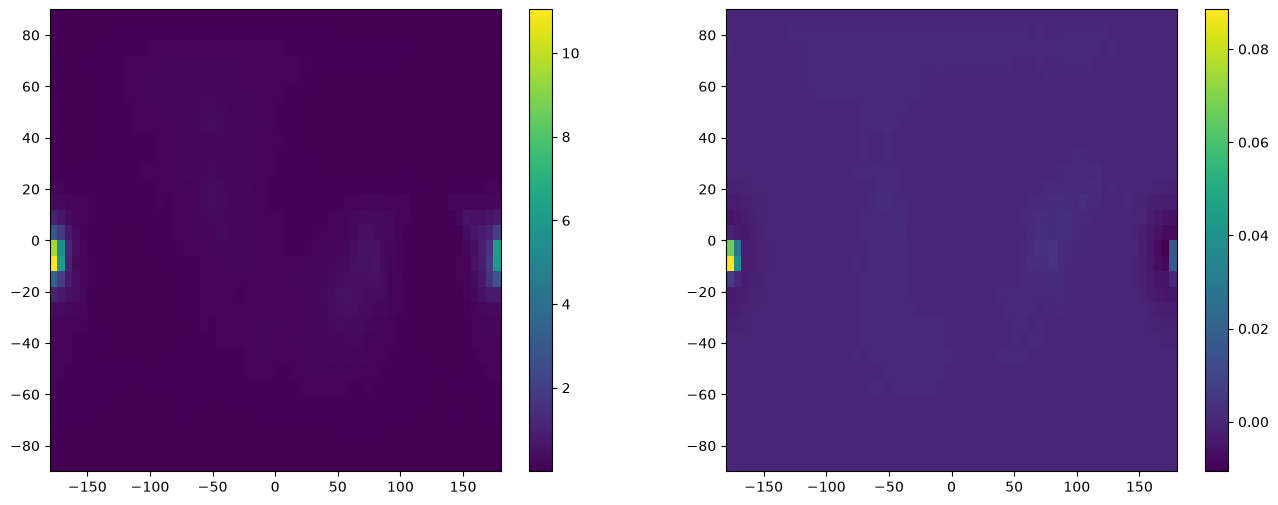

Convolving Delta image, iteration 129


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 129
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 129
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 130, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

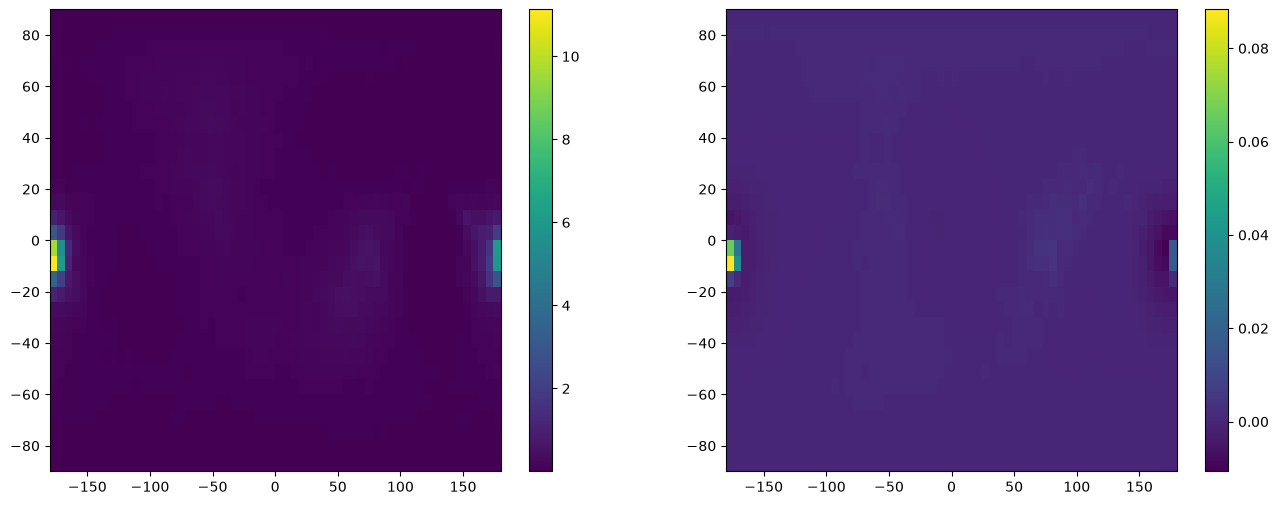

Convolving Delta image, iteration 130


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 130
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 130
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 131, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

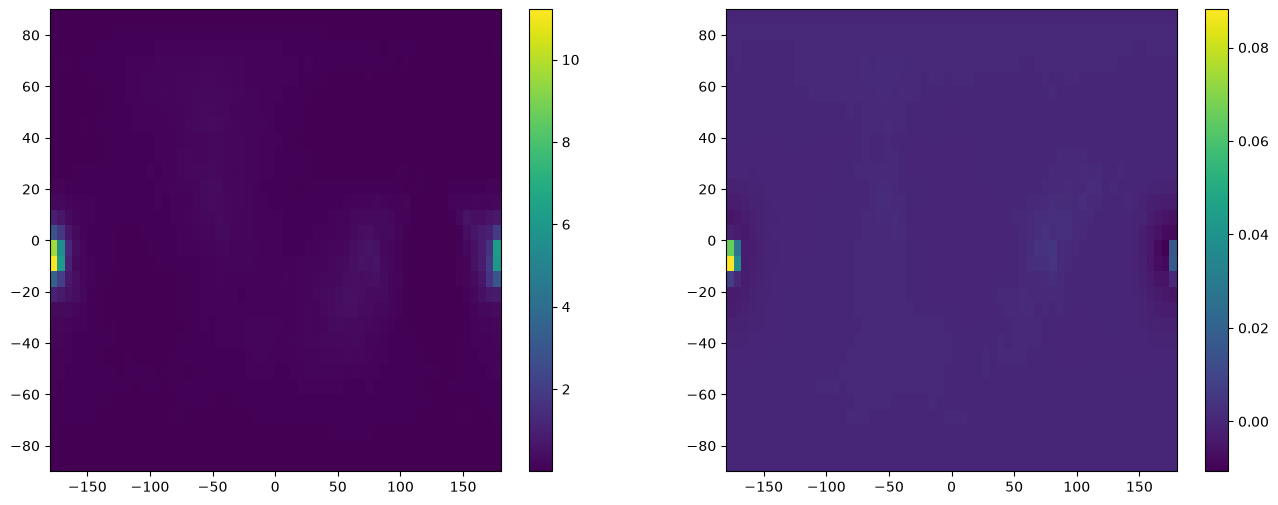

Convolving Delta image, iteration 131


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 131
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 131
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 132, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

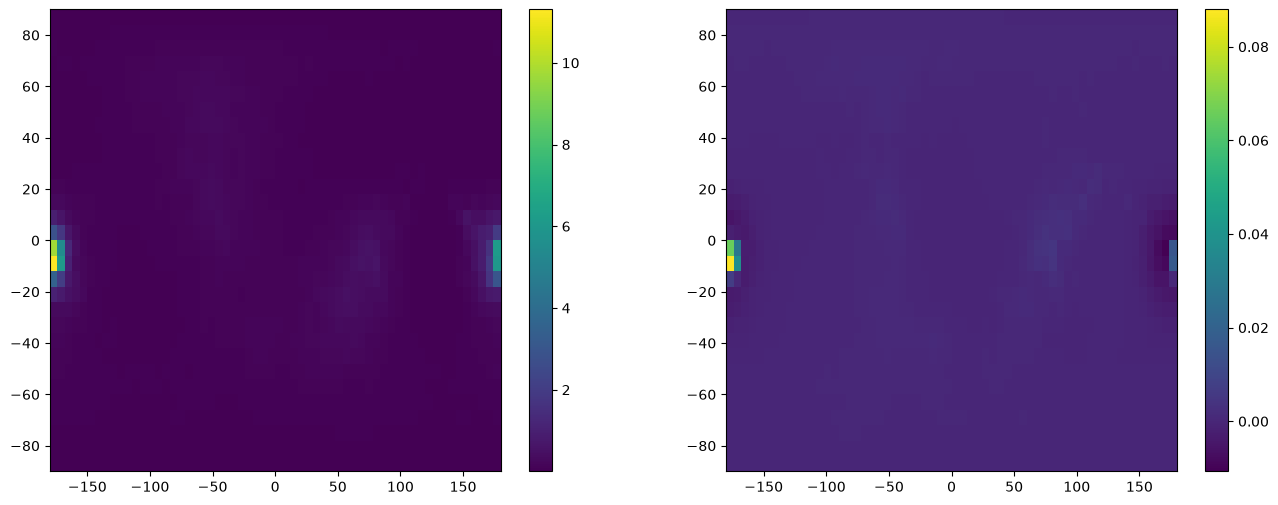

Convolving Delta image, iteration 132


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 132
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 132
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 133, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

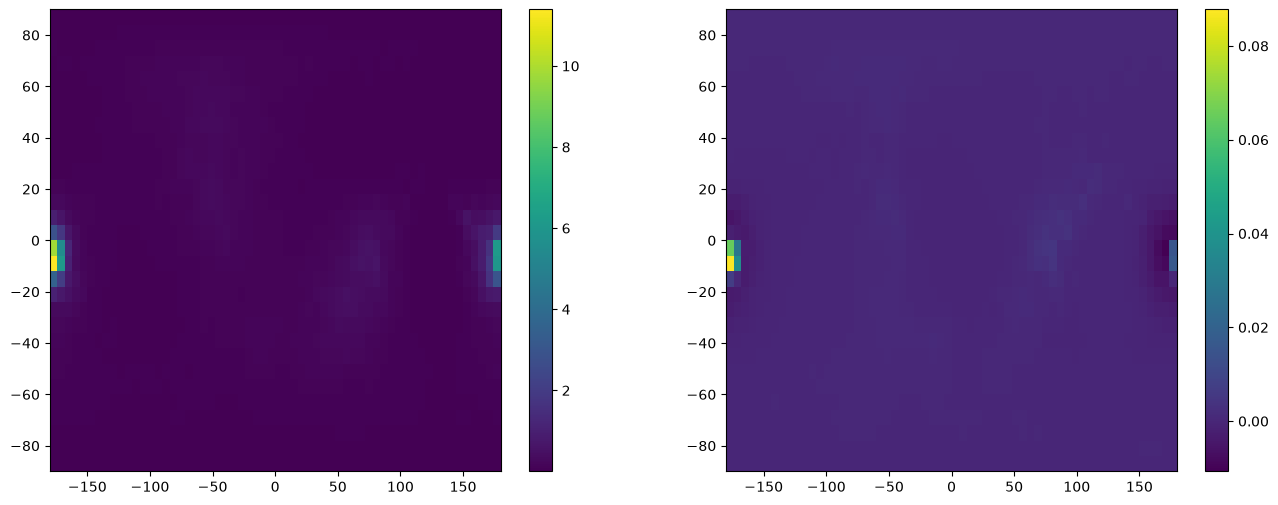

Convolving Delta image, iteration 133


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 133
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 133
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 134, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

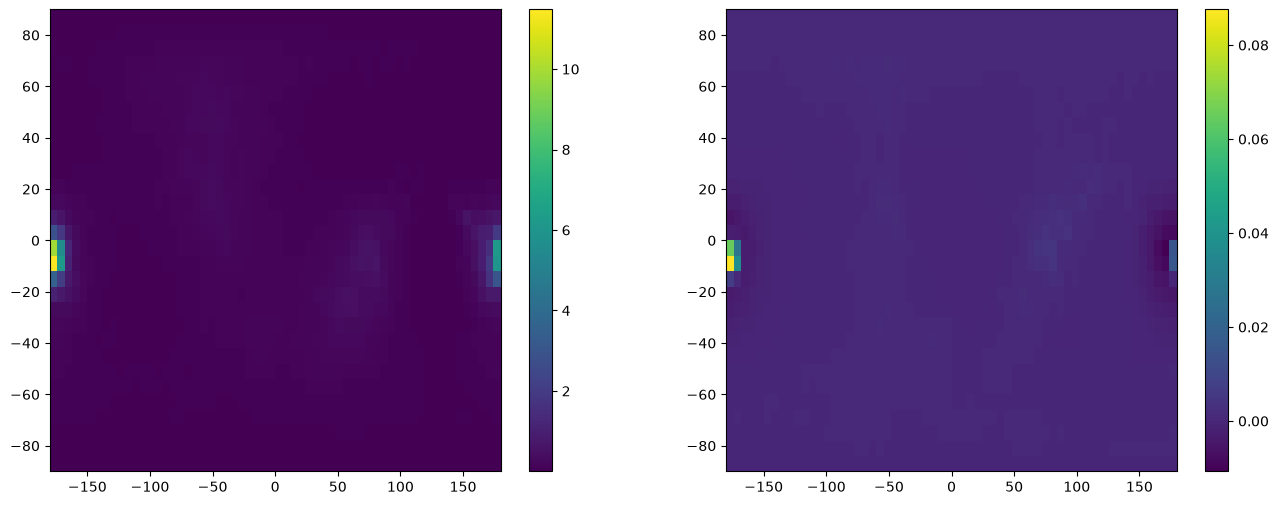

Convolving Delta image, iteration 134


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 134
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 134
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 135, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

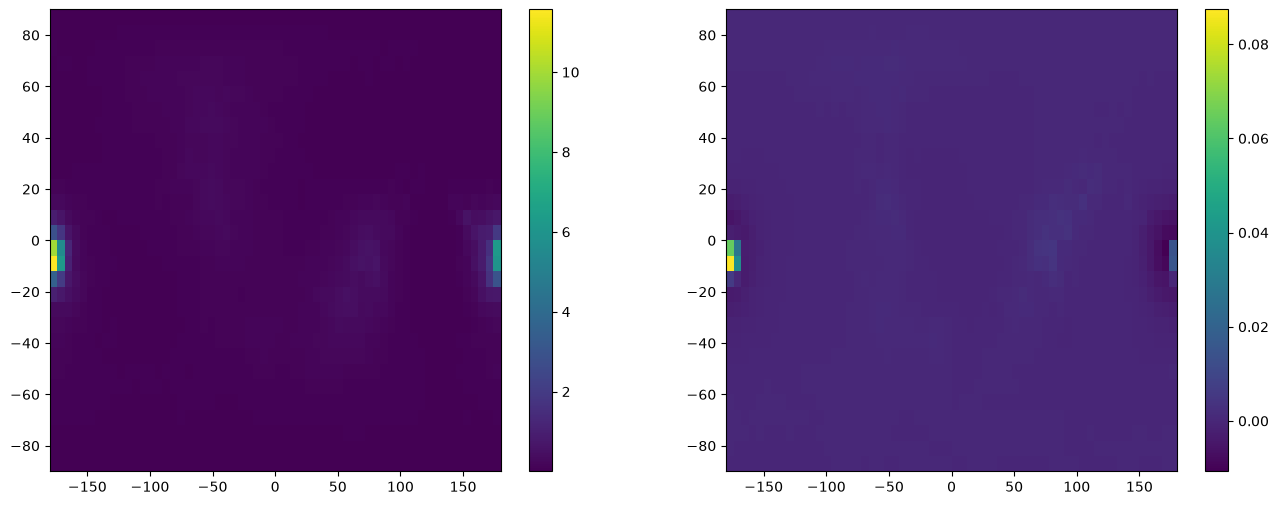

Convolving Delta image, iteration 135


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 135
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 135
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 136, numerator


  0%|          | 0/2240 [15:01<?, ?it/s]

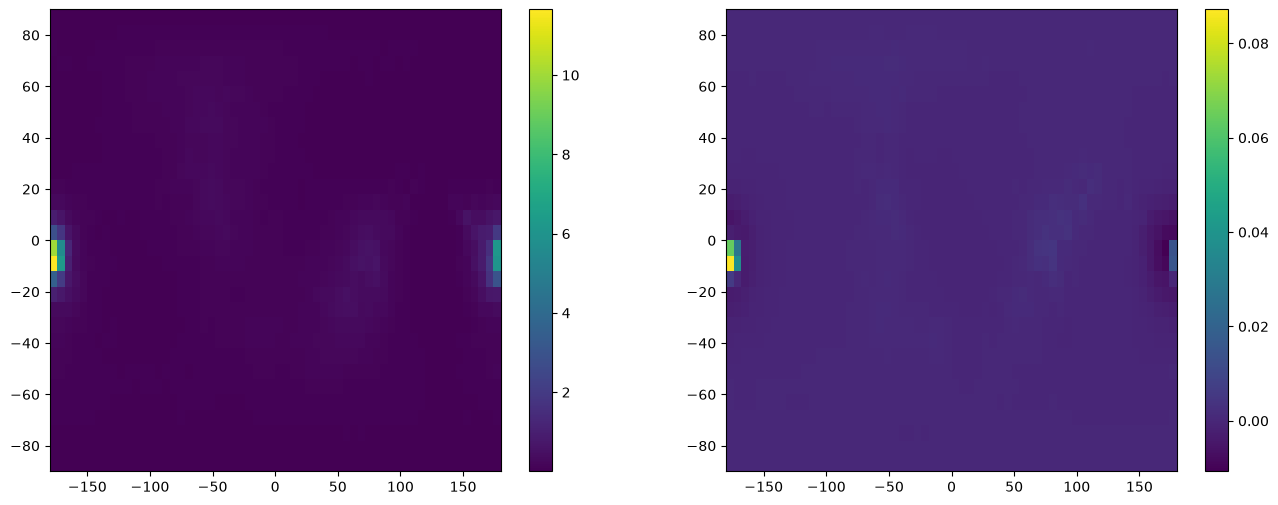

Convolving Delta image, iteration 136


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 136
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 136
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 137, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

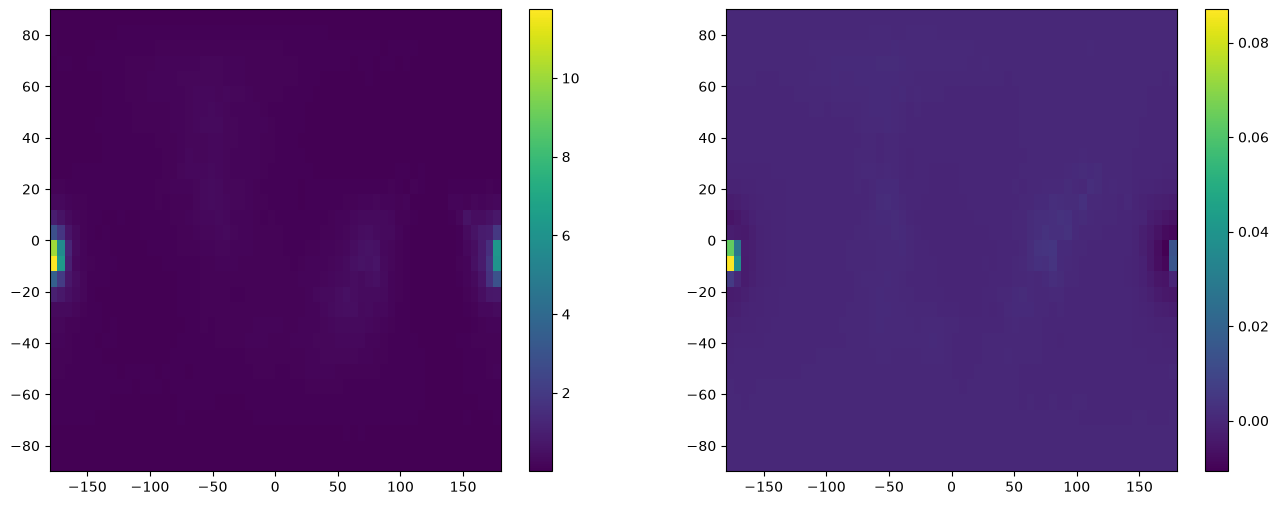

Convolving Delta image, iteration 137


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 137
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 137
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 138, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

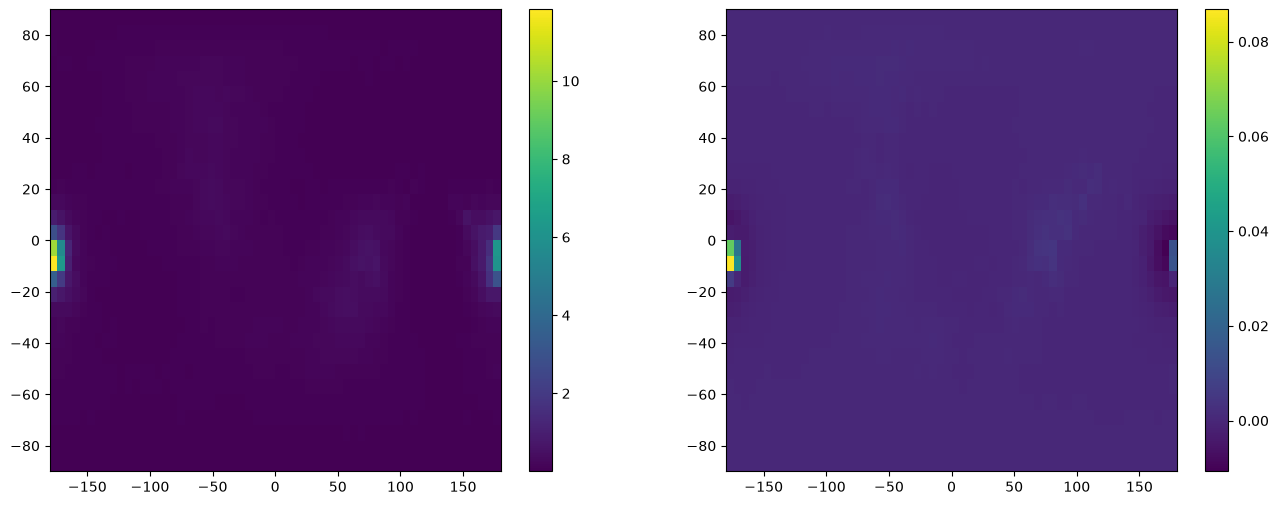

Convolving Delta image, iteration 138


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 138
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 138
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 139, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

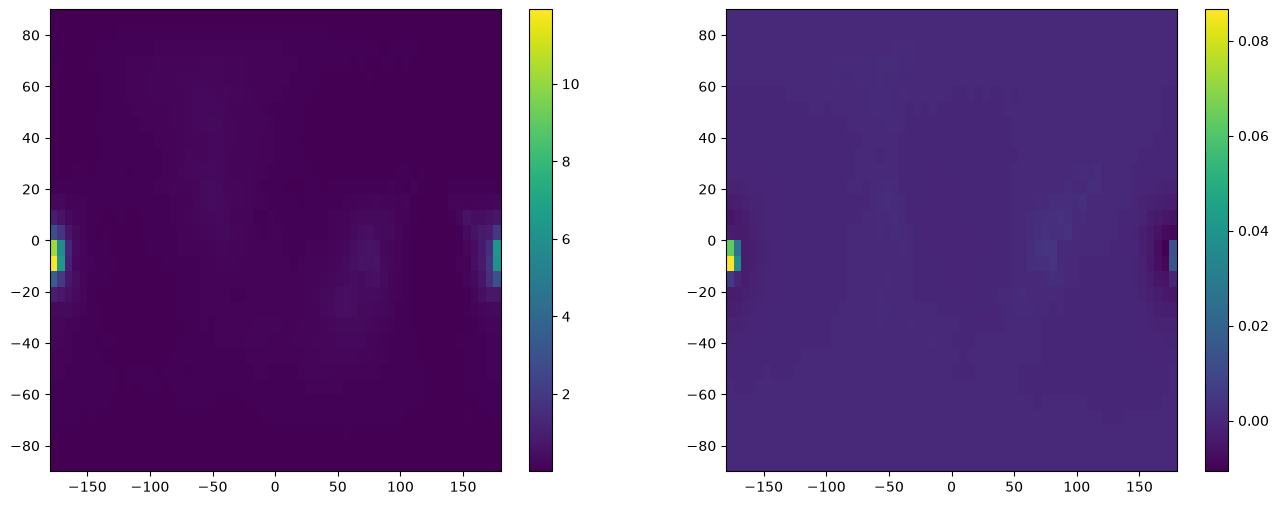

Convolving Delta image, iteration 139


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 139
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 139
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 140, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

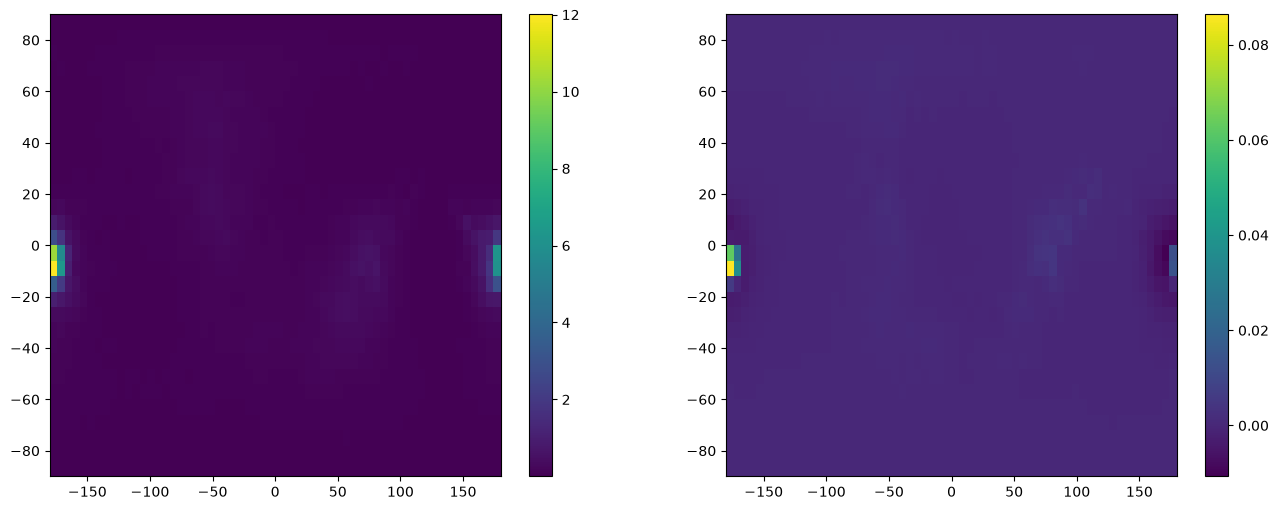

Convolving Delta image, iteration 140


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 140
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 140
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 141, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

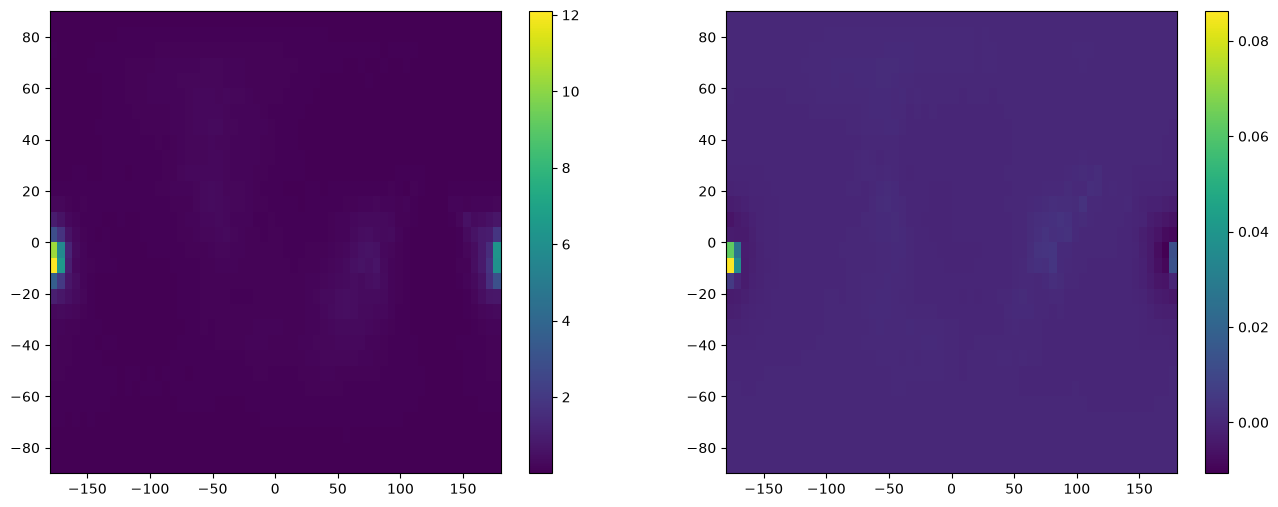

Convolving Delta image, iteration 141


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 141
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 141
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 142, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

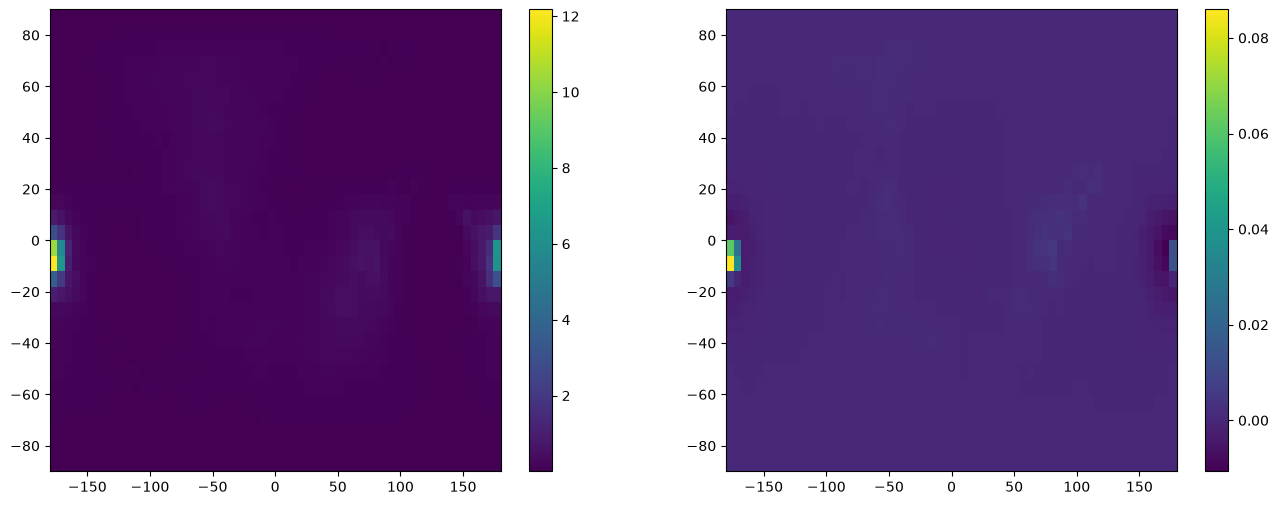

Convolving Delta image, iteration 142


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 142
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 142
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 143, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

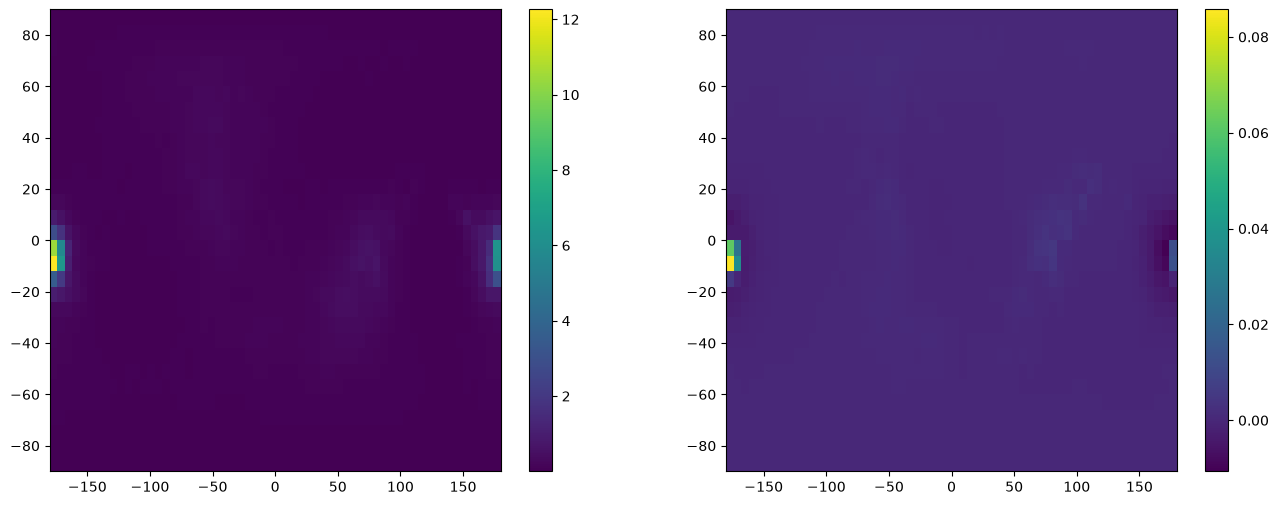

Convolving Delta image, iteration 143


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 143
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 143
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 144, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

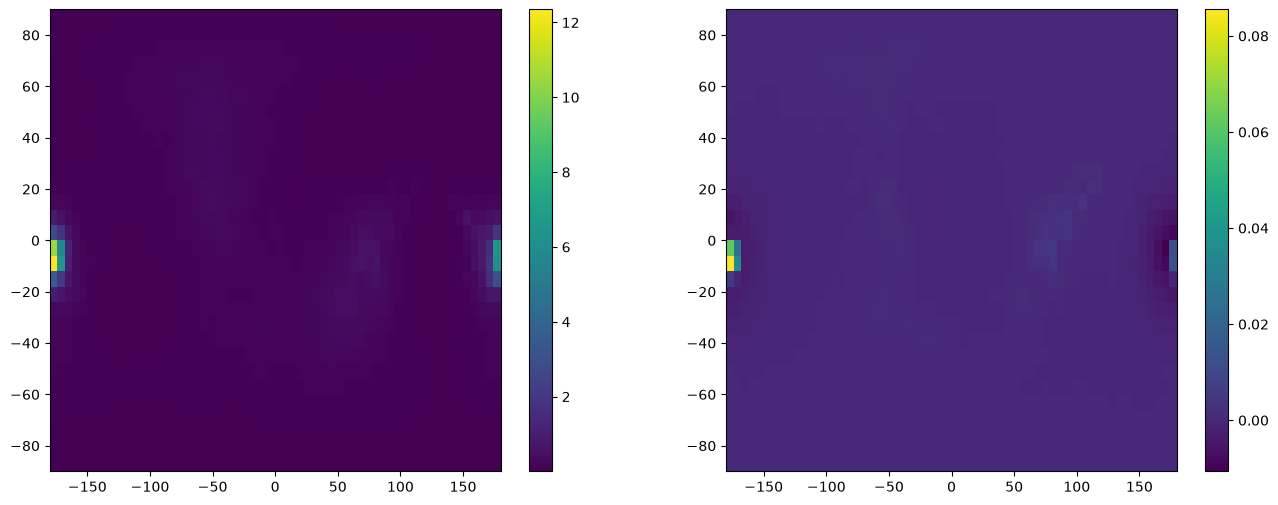

Convolving Delta image, iteration 144


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 144
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 144
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 145, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

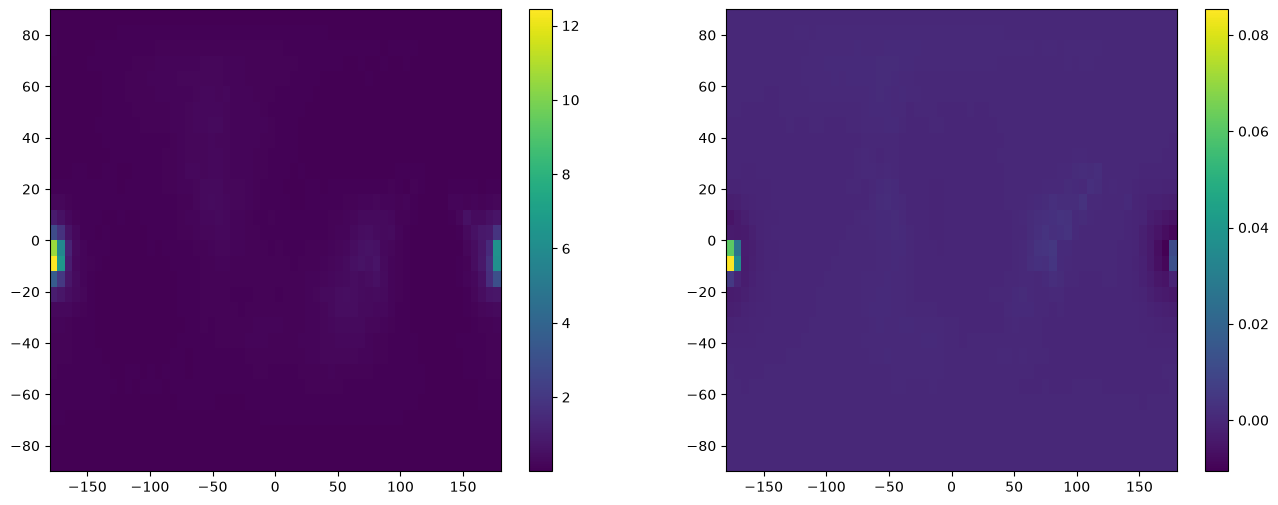

Convolving Delta image, iteration 145


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 145
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 145
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 146, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

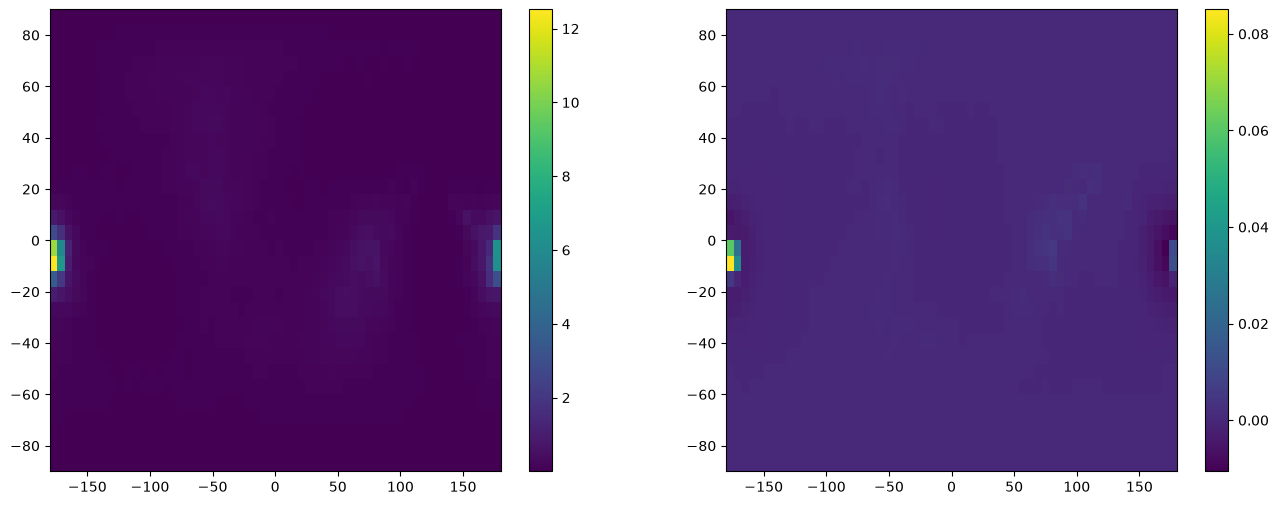

Convolving Delta image, iteration 146


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 146
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 146
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 147, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

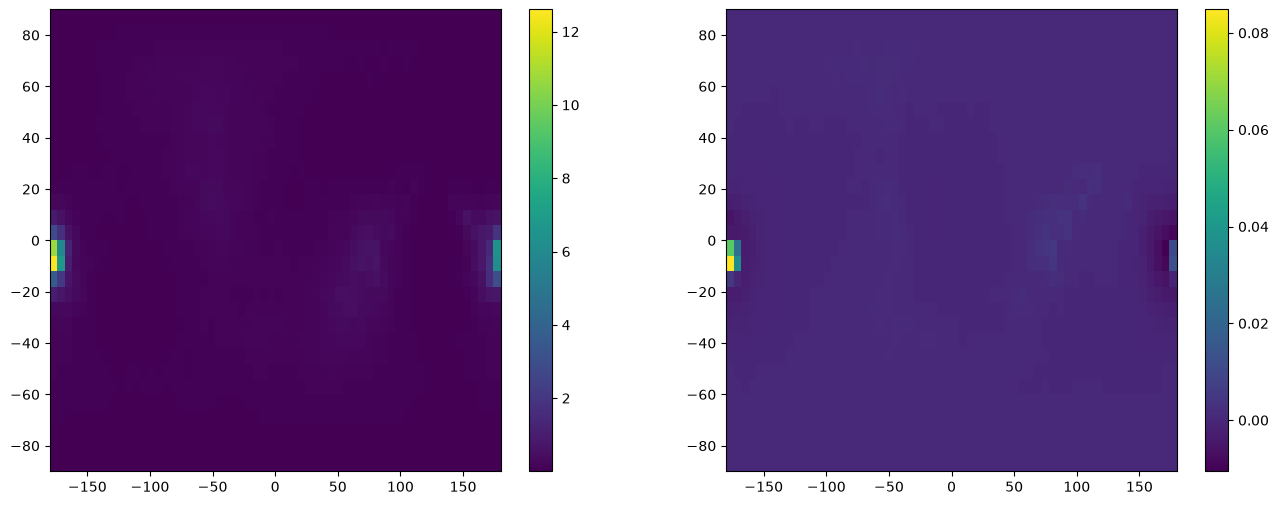

Convolving Delta image, iteration 147


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 147
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 147
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 148, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

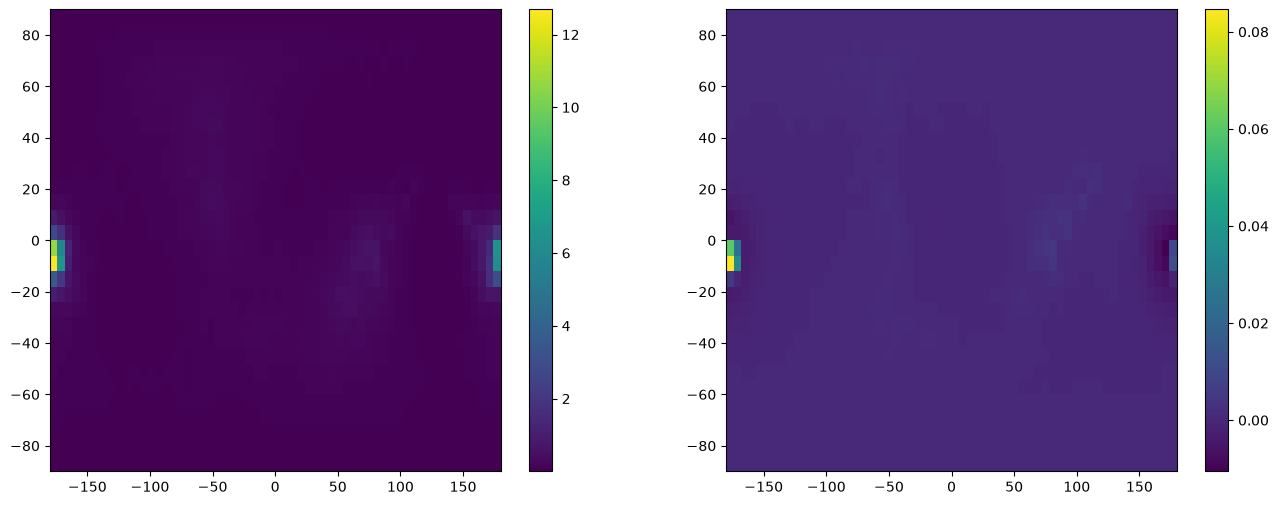

Convolving Delta image, iteration 148


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 148
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 148
############## Fit failed! proceeding without acceleration ##############
Calculating Delta image, iteration 149, numerator


  0%|          | 0/2240 [00:00<?, ?it/s]

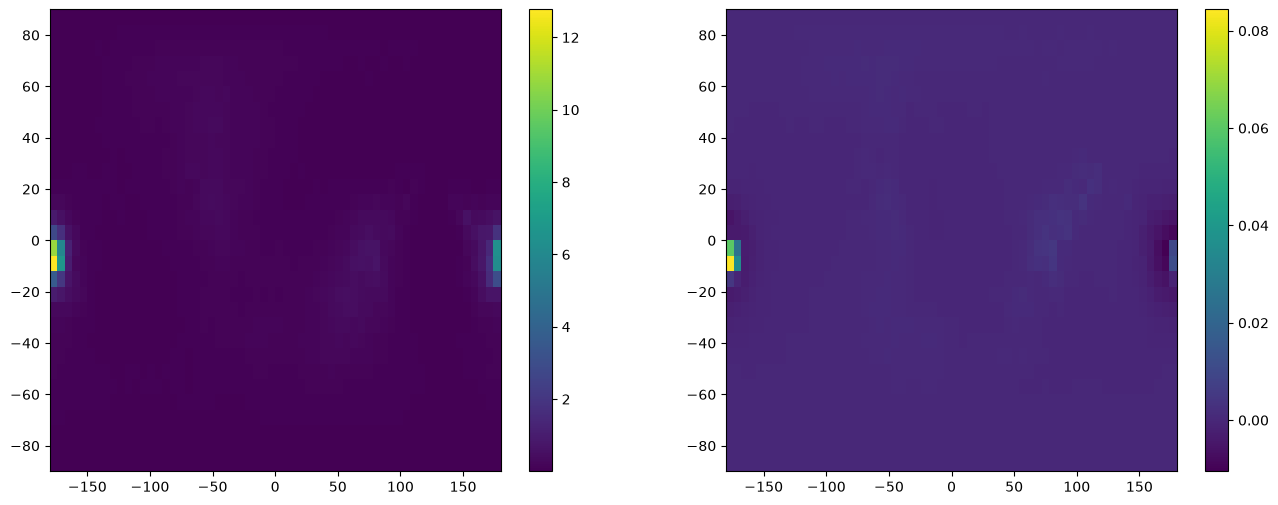

Convolving Delta image, iteration 149


  0%|          | 0/30 [00:00<?, ?it/s]

Finding maximum acceleration parameter, iteration 149
Maximum acceleration parameter found:  4.9995
Fitting delta-map in addition to old map, iteration 149
############## Fit failed! proceeding without acceleration ##############


In [52]:
# Experiment with these variables!
#############################
# initial map (isotropic flat, small value)
map_init = IsoMap(L_ARR, B_ARR, 0.01)

# number of RL iterations, Usually test with ~150 iterations. 
iterations = 150 

# acceleration parameter
afl_scl = 2000.
#############################


## Define background (to be sure it's the same as before)
bg_cuts, idx_arr, Ncuts = background1.bg_cuts, background1.idx_arr, background1.Ncuts
 
    
## Save intermediate iterations: initialise arrays to save images and other parameters
# maps per iteration
map_iterations = np.zeros((n_b, n_l, iterations))

# likelihood of maps (vs. initial i.e. basically only background)
map_likelihoods = np.zeros(iterations)

# fit likelihoods, ie fit quality
intermediate_lp = np.zeros(iterations)

# acceleration parameters (lambda)
acc_par = np.zeros(iterations)

# fitted background parameters 
bg_pars = np.zeros((iterations,Ncuts))


## Zeroth iteration: copy initial map to become the 'old map' (see below)
map_old = map_init

# cf. Knoedlseder+1997 what the values denominator etc are
# this is the response R summed over the CDS and the time bins
denominator = expo_map

# zeroth iteration is then just the initial map
map_iterations[:,:,0] = map_old#[]

# convolve this map with the response
expectation_init = 0
print('Convolving with response (init expectation), iteration 0')
for i in tqdm(range(n_b)):
    for j in range(n_l):
        expectation_init += sky_response_scaled[:,i,j,:]*map_init[i,j]

# set old expectation (in data space bins) to new expectation (convolved image)
expectation_old = expectation_init

### now we have the expectation of the image. Need to go to the BG 
        
###########################################################
###########################################################
## here run over the number of iterations #################
###########################################################
## the time for the convolutions is very large ############
## this can be 10 minutes (!) per iteration ###############
## this should be tested for a few iterations #############
## and then run overnight or similar ######################
###########################################################
###########################################################
for its in tqdm(range(1,iterations)):
    
    # setting the map to zero where we selected a bad exposure (we didn't, but to keep it general)
    map_old[bad_expo[0],bad_expo[1]] = 0
    
    # check for each pixel to be finite
    map_old[np.where(np.isnan(map_old) == True)] = 0
    
    # make new background for the next iteration
    bg_cuts, idx_arr, Ncuts = background1.bg_cuts, background1.idx_arr, background1.Ncuts
    
    # temporary background model
    tmp_model_bg = np.zeros((d2h,background1.bg_model_reduced[ebin].shape[1]))
    
    # there could be something different for the first iteration (here it isn't, same function call)
    if its == 1:
        for g in range(d2h):
            tmp_model_bg[g,:] = background_model[g,:]*fitted_bg[idx_arr-1][g]
    else:
        for g in range(d2h):
            tmp_model_bg[g,:] = background_model[g,:]*fitted_bg[idx_arr-1][g]
            
    # expectation (in data space) is the image (expectation_old) plus the background (tmp_model_bg)
    expectation_tot_old = expectation_old + tmp_model_bg 

    # calculate likelihood of currect total expectation
    map_likelihoods[its-1] = cashstat(dataset.ravel(),expectation_tot_old.ravel())
    
    # calculate numerator of RL algorithm
    numerator = 0
    print('Calculating Delta image, iteration '+str(its)+', numerator')
    for i in tqdm(range(d2h)):
        for j in range(dataset.shape[1]):
            numerator += (dataset[i,j]/expectation_tot_old[i,j]-1)*sky_response_scaled[i,:,:,j]
    
    # calculate delta map (denominator scaled by fourth root to avoid exposure edge effects)
    # You can try changing 0.25 to 0, 0.5, for example
    delta_map_tot_old = (numerator/denominator)*map_old*(denominator)**0.25
    
    # Alternatively, you can also try to smooth it 
    #delta_map_tot_old = gaussian_filter(delta_map_tot_old, 0.5)
    
    #################################
    
    
    
    # check again for finite values and zero our bad exposure regions
    nan_idx = np.where(np.isnan(delta_map_tot_old) == 1)
    delta_map_tot_old[nan_idx[0],nan_idx[1]] = 0
    delta_map_tot_old[bad_expo[0],bad_expo[1]] = 0

    # plot each iterations and its delta map 
    # (not required, but nice to see how the algorithm is doing)
    plt.figure(figsize=(16,6))
    plt.subplot(121)
    plt.pcolormesh(L_ARRg,B_ARRg,np.roll(map_old, axis=1, shift=0)) 
    plt.colorbar()

    plt.subplot(122)
    plt.pcolormesh(L_ARRg,B_ARRg,np.roll(delta_map_tot_old, axis=1, shift=0)) 
    plt.colorbar()
    plt.show()
    
    # convolve delta image
    print('Convolving Delta image, iteration '+str(its))
    conv_delta_map_tot = 0
    for i in tqdm(range(n_b)):
        for j in range(n_l):
            conv_delta_map_tot += sky_response_scaled[:,i,j,:]*delta_map_tot_old[i,j]
    
    # find maximum acceleration parameter to multiply delta image with
    # so that the total image is still positive everywhere
    print('Finding maximum acceleration parameter, iteration '+str(its))
    try:
        len_arr = []
        for i in range(0,10000):
            len_arr.append(len(np.where((map_old+delta_map_tot_old*i/afl_scl) < 0)[0]))
        len_arr = np.array(len_arr)
        afl = np.max(np.where(len_arr == 0)[0])
        print('Maximum acceleration parameter found: ',afl/afl_scl)

        
        # fit delta map and current map to speed up RL algorithm
        print('Fitting delta-map in addition to old map, iteration '+str(its))
        # dictionary for data set and prior
        # note that here the value for N should be your response CDS dimension
        # should be last dimension of the scaled response thing (change to your value)
        data_multimap = dict(N = dataset.shape[1],
                     Nh = d2h,
                     Ncuts = Ncuts,
                     Nsky = 2,
                     acceleration_factor_limit=afl*0.95,
                     bg_cuts = bg_cuts,
                     bg_idx_arr = idx_arr,
                     y = dataset.ravel().astype(int),
                     bg_model = tmp_model_bg,
                     conv_sky = np.concatenate([[expectation_old],[conv_delta_map_tot/afl_scl]]),
                     mu_flux = np.array([1,afl/2]),
                     sigma_flux = np.array([1e-2,afl]),
                     mu_Abg = fitted_bg,    # can play with this
                     sigma_Abg = fitted_bg) # can play with this

        # fit;
        # initial values for fit (somewhat sensitive here with COSI data)
        init = {}
        init['flux'] = np.array([1.,afl/2.])
        init['Abg'] = np.repeat(fitted_bg, Ncuts) # can play with this
        
        # fit: might take some time but it shouldn't be more than a minute
        op2D = model_multimap.optimizing(data=data_multimap,init=init,as_vector=False,verbose=True,
                                                tol_rel_grad=1e3,tol_obj=1e-20)

        # save values
        print('Saving new map, and fitted parameters, iteration '+str(its))
        intermediate_lp[its-1] = op2D['value']
        acc_par[its-1] = op2D['par']['flux'][1]
        bg_pars[its-1,:] = op2D['par']['Abg']
  
        # make new map as old map plus scaled delta map
        map_new = map_old+op2D['par']['flux'][1]*delta_map_tot_old/afl_scl
    
        # same with expectation (data space)
        expectation_new = expectation_old + op2D['par']['flux'][1]*conv_delta_map_tot/afl_scl
        

    except:
        # if the fit failed...
        # this shouldn't happen too often (or at all). 
        # This will happen if pystan is not loaded. Proceed anyway.
        print('############## Fit failed! proceeding without acceleration ##############')
        map_new = map_old + delta_map_tot_old
        expectation_new = expectation_old + conv_delta_map_tot
    
    # check finite values again
    if its == 1:
        bad_index_init = np.where(np.isnan(map_new) == True)
    
    # also here
    map_new[bad_expo[0],bad_expo[1]] = 0
    map_new[np.where(np.isnan(map_new) == True)] = 0
    map_iterations[:,:,its] = map_new

    # swap maps
    map_old = map_new
    
    # and expectations
    expectation_old = expectation_new
    
    # and repeat

In [74]:
np.savez_compressed(
    "point_sources_RL_results.npz",
    map_iterations=map_iterations,
    map_likelihoods=map_likelihoods,
    intermediate_lp=intermediate_lp,
    acc_par=acc_par,
    bg_pars=bg_pars
)

## Plot the fitted background parameter and the map flux

Text(0, 0.5, 'Flux')

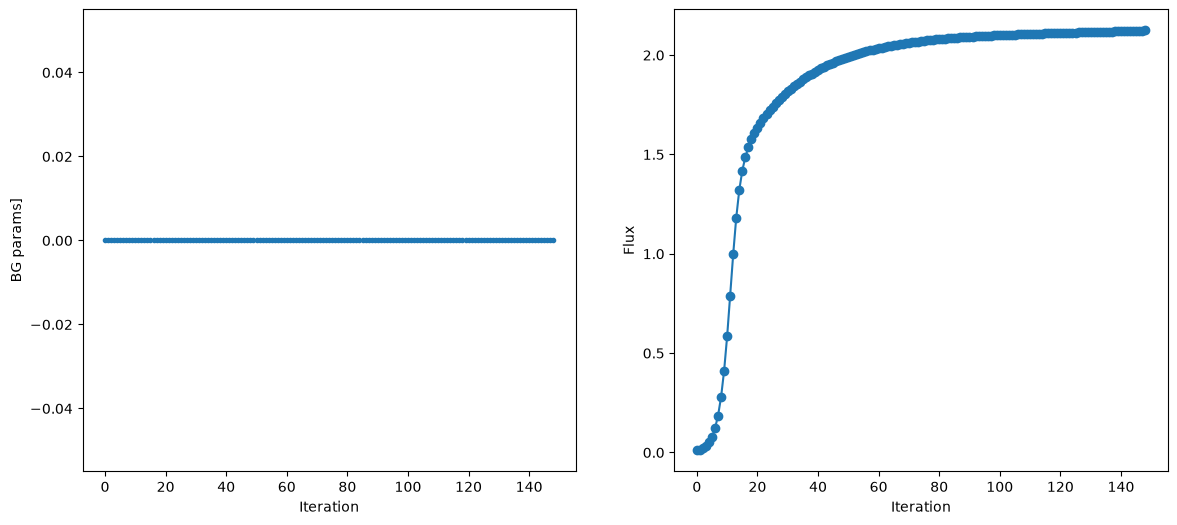

In [95]:
plt.figure(figsize=(14,6))
plt.subplot(121)
plt.plot(range(its), [i[0] for i in bg_pars[:its]], '.-')
plt.xlabel('Iteration')
plt.ylabel('BG params]')


plt.subplot(122)
map_fluxes = np.zeros(its)
for i in range(its):
    map_fluxes[i] = np.sum(map_iterations[:,:,i]*domega)
plt.plot(map_fluxes[:its],'o-')
plt.xlabel('Iteration')
plt.ylabel('Flux')# [ph/keV]')

## Did the algorithm converge? Look at the likelihoods.
intermediate_lp: Fit likelihoods, i.e. fit quality

map_likelihoods: likelihood of maps (vs. initial i.e. basically only background)

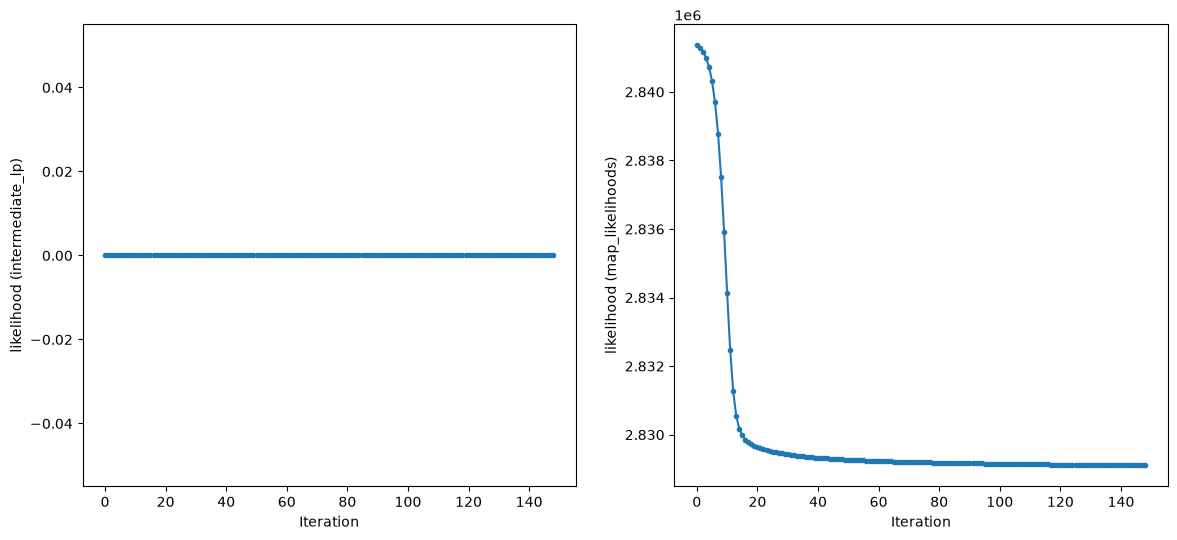

In [98]:
plt.figure(figsize=(14,6))
plt.subplot(121)
plt.plot(range(its+1)[:-1], intermediate_lp[:its+1][:-1], '.-')
plt.xlabel('Iteration')
plt.ylabel('likelihood (intermediate_lp)')
plt.subplot(122)
plt.plot(range(its+1)[:-1], map_likelihoods[:its+1][:-1], '.-')
plt.xlabel('Iteration')
plt.ylabel('likelihood (map_likelihoods)')
plt.show()


## Make the image!
You can loop over all iterations to make a GIF or just show one iteration (usually the final iteration).

In [99]:
from IPython.display import Image
from IPython.display import Video
from tqdm.autonotebook import tqdm

from matplotlib import animation

from matplotlib import colors

from scipy.ndimage import gaussian_filter as smooth

In [100]:
# Choose an image to plot
idx = its

Text(0.5, 0, '[Arbitrary Units]')

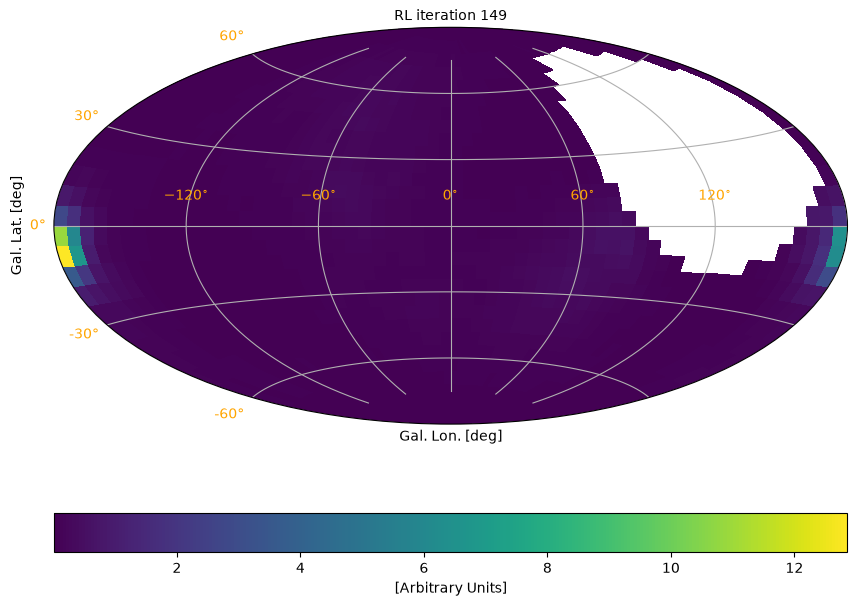

In [ ]:
# Choose a color map like viridis (matplotlib default), nipy_spectral, twilight_shifted, etc. Not jet.
cmap = plt.get_cmap('twilight_shifted') 

# Bad exposures will be gray
cmap.set_bad('red')


##################
# Select here which pixels should be gray
map_iterations_nan = np.copy(map_iterations)

# Select also non-zero exposures here to be gray (avoiding the edge effects)
# You can play with this. Most success in testing with 1e4, 1e3
bad_expo = np.where(expo_map/domega <= 1e4) 

for i in range(iterations):
    map_iterations_nan[bad_expo[0], bad_expo[1], i] = np.nan
#################    


# Set up the plot
fig, ax = plt.subplots(figsize=(10.24,7.68), subplot_kw={'projection':'aitoff'}, nrows=1, ncols=1)

ax.set_xticks(np.array([-120,-60,0,60,120])*deg2rad)
ax.set_xticklabels([r'$-120^{\circ}$'+'\n',
                            r'$-60^{\circ}$'+'\n',
                            r'$0^{\circ}$'+'\n',
                            r'$60^{\circ}$'+'\n',
                            r'$120^{\circ}$'+'\n'])
ax.tick_params(axis='x', colors='orange')

ax.set_yticks(np.array([-60,-30,0,30,60])*deg2rad)
ax.tick_params(axis='y', colors='orange')

plt.xlabel('Gal. Lon. [deg]')
plt.ylabel('Gal. Lat. [deg]')



# "ims" is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []


# If you want to make a GIF of all iterations:
#for i in range(iterations):

# If you only want to plot one image:
for i in [idx]:

    ttl = plt.text(0.5, 1.01, f'RL iteration {i}', horizontalalignment='center', 
                   verticalalignment='bottom', transform=ax.transAxes)
    
    # Either gray-out bad exposure (map_iterations_nan) or don't mask (map_iterations)
    # Masking out bad exposure 
    image = map_iterations_nan[:, :, i]
    #image = map_iterations[:, :, i]

    
    img = ax.pcolormesh(L_ARRg*deg2rad,B_ARRg*deg2rad,
                        
                        # Can shift the image along longitude. Here, no shift.
                        np.roll(image, axis=1, shift=0),
            
                        # Optionally smooth with gaussian filter
                        #smooth(np.roll(image, axis=1, shift=0), 0.75/pixel_size),
                        
                        cmap=plt.cm.viridis,
                        
                        # Optionally set the color scale. Default: linear
                        #norm=colors.PowerNorm(0.33)
                       )
    ax.grid()
    
    ims.append([img, ttl])

cbar = fig.colorbar(img, orientation='horizontal')
cbar.ax.set_xlabel('[Arbitrary Units]')
    

# Can save a sole image as a PDF 
#plt.savefig(data_dir + f'images/point_sources_RL_image_iteration{idx}.pdf', bbox_inches='tight')
    
    
# # Can save all iterations as a GIF
# ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True, repeat_delay=0)
# ani.save(f'/home/jacqueline/point_sources_RL_image_{idx}iterations.gif')

# What do we see?
The Crab nebula is the only easily visible source in this combined simulation of 10x flux Crab, 10x flux Cygnus X-1, 10x flux Centaurus A, 10x Vela, and 1x flux Ling background (scaled to the observed 2016 flight background level). 

You can play with the color scaling to try to enhance the appearance of the other sources. Vela is likely too dim to be seen, however. 

You can also try running this notebook without including the Ling background. Change the loaded .tra.gz file at the beginning, adjust RL parameters as necessary, and see if the four point sources are more easily resolved without background contamination!

As another suggestion, what happens if you run this notebook using the 511 keV response? The 1809 keV response? A different energy bin of the continuum response? 

You can try combining these four point sources and Ling BG with the 10x 511 keV and 10x $^{26}$Al simulations for a full combined imaging test, using all three response simulations too.